# Code 1

Metropolis algorithm, single peak synthetic data.

Produces Figures 3 and 4 in the paper

---------------------------- CODE OUTPUT -----------------------------
Data points: 200

Starting Metropolis-Hastings sampling...
Using correct first-order kinetics (Randall-Wilkins equation)
Parameters: E (activation energy, eV), s (frequency factor, s^-1), sigma (noise)
Running MCMC for 400000 steps...
Parameters: E (eV), log10(s), sigma
  Step 30000/400000, Acceptance rate so far: 0.572
  Step 60000/400000, Acceptance rate so far: 0.472
  Step 90000/400000, Acceptance rate so far: 0.407
  Step 120000/400000, Acceptance rate so far: 0.362
  Step 150000/400000, Acceptance rate so far: 0.333
  Step 180000/400000, Acceptance rate so far: 0.313
  Step 210000/400000, Acceptance rate so far: 0.299
  Step 240000/400000, Acceptance rate so far: 0.288
  Step 270000/400000, Acceptance rate so far: 0.280
  Step 300000/400000, Acceptance rate so far: 0.274
  Step 330000/400000, Acceptance rate so far: 0.268
  Step 360000/400000, Acceptance rate so far: 0.264
  Step 390000/400000, Acceptance rate

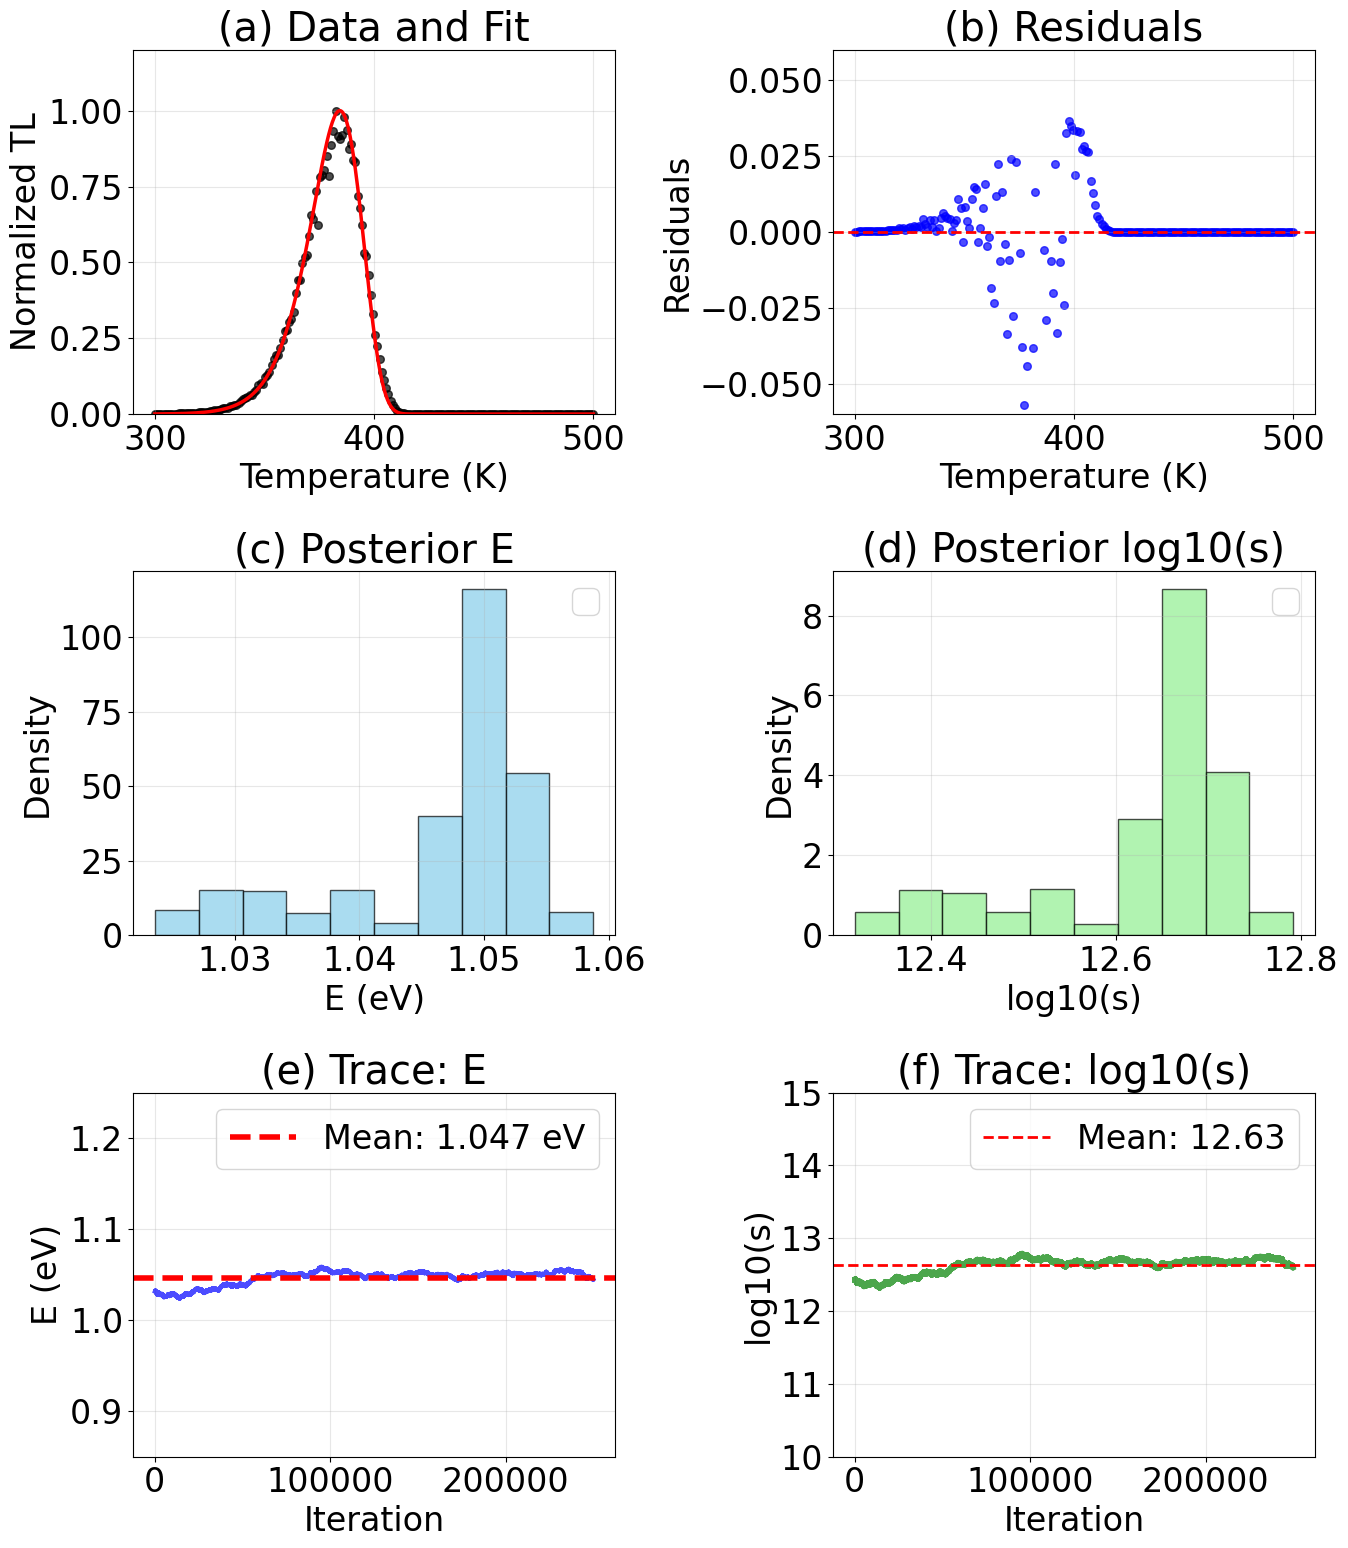


Residual statistics:
  Mean residual: -0.0020
  Std residual: 0.0215

Correlation between E and log10(s): 1.000

PHYSICAL INTERPRETATION
Activation energy E = 1.047 ± 0.008 eV
This represents the energy barrier for electron detrapping.

Frequency factor s = 4.35e+12 s^-1


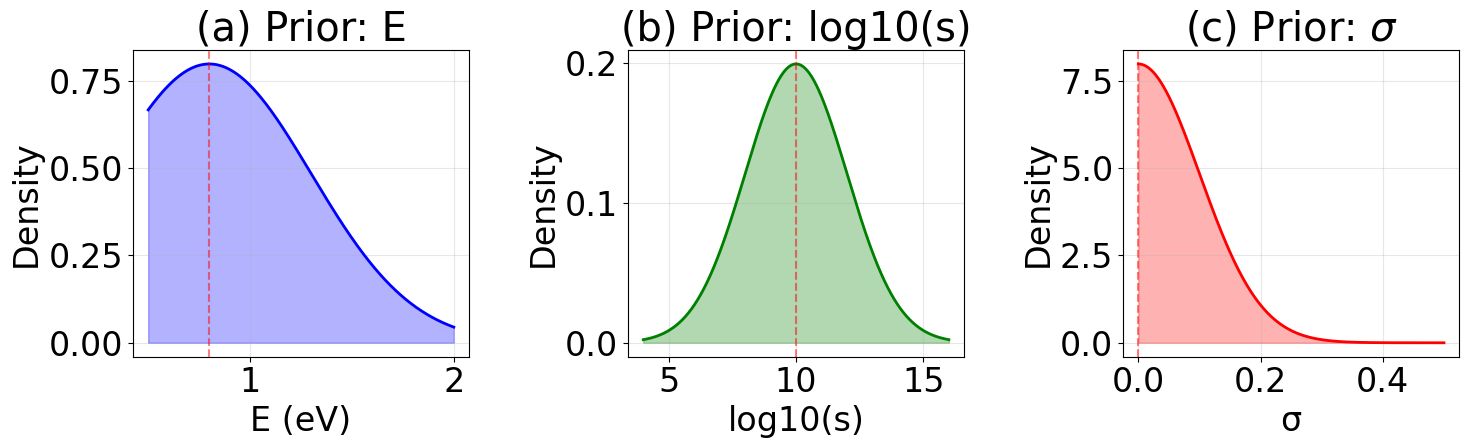

In [ ]:

%reset -f

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
print('-'*28,'CODE OUTPUT','-'*29)
rng = np.random.default_rng(seed=122)

# Simulate data from first-order kinetics with E=1 eV, s=1e12 s^-1
kB = 8.617E-5  # Boltzmann constant (eV/K)

def first_order_kinetics(T, E, s, beta=1.0):
    """
    Correct first-order kinetics TL glow curve (Randall-Wilkins model).
    No Tmax parameter - it emerges naturally from E and s.

    Parameters:
    T: Temperature (K) - can be array
    E: Activation energy (eV)
    s: Frequency factor (s^-1)
    beta: Heating rate (K/s) - typically 1 K/s in many experiments

    Returns:
    TL intensity (normalized to peak maximum)
    """
    kB = 8.617E-5  # Boltzmann constant (eV/K)
    eps = 1e-10    # Small number to avoid division by zero

    # Convert to numpy array if needed
    T = np.asarray(T)

    # Calculate the thermal integral approximation
    # ∫ exp(-E/(kB*u)) du ≈ (kB*T^2/E) * exp(-E/(kB*T)) * (1 - 2*kB*T/E)
    # This is the standard approximation from Chen (1969)

    # Pre-calculate common terms
    kT = kB * T
    E_over_kT = E / kT

    # Thermal integral approximation
    thermal_int = (kB * T**2 / E) * np.exp(-E_over_kT) * (1 - 2*kB*T/E + eps)

    # First-order kinetics (Randall-Wilkins equation)
    # I(T) = n0 * s * exp(-E/kT) * exp(-(s/beta) * ∫ exp(-E/kT') dT')
    # For normalized intensity, n0 is absorbed into normalization

    # Calculate intensity (unnormalized)
    I_T = s * np.exp(-E_over_kT) * np.exp(-(s/beta) * thermal_int)

    # Normalize to maximum = 1
    if np.max(I_T) > 1e-10:
        I_T = I_T / np.max(I_T)

    # Clip small negative values (due to numerical errors)
    I_T = np.maximum(I_T, 0)

    return I_T

# Generate temperature range (similar to typical TL experiment)
x_data = np.linspace(300, 500, 200)  # Temperature range 300-600 K

# Generate ideal data with true parameters
E_true = 1.0  # eV
s_true = 1e12  # s^-1
y_ideal = first_order_kinetics(x_data, E_true, s_true)

# Add 5% multiplicative noise
np.random.seed(42)
noise = np.random.normal(0, 0.05, size=len(y_ideal))  # 5% standard deviation
y_data_noisy = y_ideal * (1 + noise)  # multiplicative 5% error

# Ensure no negative values
y_data_noisy = np.maximum(y_data_noisy, 0)

# Re-normalize after adding noise (optional, to keep max = 1)
y_data_noisy = y_data_noisy / np.max(y_data_noisy)

# Use y_data_noisy instead of y_data for fitting
y_data = y_data_noisy

# Normalize data
y_data = y_data / np.max(y_data)

def first_order_kinetics(T, E, s, beta=1.0):
    """
    Correct first-order kinetics TL glow curve (Randall-Wilkins model).
    No Tmax parameter - it emerges naturally from E and s.

    Parameters:
    T: Temperature (K) - can be array
    E: Activation energy (eV)
    s: Frequency factor (s^-1)
    beta: Heating rate (K/s) - typically 1 K/s in many experiments

    Returns:
    TL intensity (normalized to peak maximum)
    """
    kB = 8.617E-5  # Boltzmann constant (eV/K)
    eps = 1e-10    # Small number to avoid division by zero

    # Convert to numpy array if needed
    T = np.asarray(T)

    # Calculate the thermal integral approximation
    # ∫ exp(-E/(kB*u)) du ≈ (kB*T^2/E) * exp(-E/(kB*T)) * (1 - 2*kB*T/E)
    # This is the standard approximation from Chen (1969)

    # Pre-calculate common terms
    kT = kB * T
    E_over_kT = E / kT

    # Thermal integral approximation
    thermal_int = (kB * T**2 / E) * np.exp(-E_over_kT) * (1 - 2*kB*T/E + eps)

    # First-order kinetics (Randall-Wilkins equation)
    # I(T) = n0 * s * exp(-E/kT) * exp(-(s/beta) * ∫ exp(-E/kT') dT')
    # For normalized intensity, n0 is absorbed into normalization

    # Calculate intensity (unnormalized)
    I_T = s * np.exp(-E_over_kT) * np.exp(-(s/beta) * thermal_int)

    # Normalize to maximum = 1
    if np.max(I_T) > 1e-10:
        I_T = I_T / np.max(I_T)

    # Clip small negative values (due to numerical errors)
    I_T = np.maximum(I_T, 0)

    return I_T

def log_prior(E, s, sigma):
    """
    Log prior for all parameters.
    Uses weakly informative priors.
    """
    # Parameter constraints (physical)
    if E <= 0.7 or E > 1.3:
        return -np.inf  # Activation energy typically 0.05-3 eV
    if s <= 1e7 or s > 1e13:
        return -np.inf  # Frequency factor physical range
    if sigma <= 0 or sigma > 1:
        return -np.inf  # Noise standard deviation positive

    # Weakly informative priors
    # E: Normal(1.0, 0.5²) - typical for many TL materials
    log_prior_E = -0.5 * ((E - 0.8) / 0.5) ** 2

    # s: Log-normal prior (common for frequency factors spanning many orders of magnitude)
    log10_s = np.log10(s)
    log_prior_s = -0.5 * ((log10_s - 10) / 2) ** 2  # N(10, 2²) in log space

    # sigma: Half-normal prior
    log_prior_sigma = -0.5 * (sigma / 0.1) ** 2

    return log_prior_E + log_prior_s + log_prior_sigma

def log_likelihood(y, y_pred, sigma):
    """Log likelihood assuming Gaussian errors"""
    n = len(y)
    return -0.5 * np.sum(((y - y_pred) / sigma) ** 2) - n * np.log(sigma)

def log_posterior(params, x, y):
    """Log posterior probability"""
    E, s, sigma = params
    y_pred = first_order_kinetics(x, E, s)
    lp = log_prior(E, s, sigma)

    # Check if log_prior is finite
    if not np.isfinite(lp):
        return -np.inf

    # Check for NaN in predictions
    if np.any(np.isnan(y_pred)) or np.any(np.isinf(y_pred)):
        return -np.inf

    return lp + log_likelihood(y, y_pred, sigma)

def metropolis(x, y, n_steps, burn_in):
    """
    Metropolis-Hastings algorithm for first-order kinetics parameters.
    Parameters: E (activation energy), s (frequency factor), sigma (noise)
    """

    # Starting parameters (initial guesses)
    E = 0.9  # eV
    s = 1e9  # s^-1
    sigma = 0.05

    # Step sizes (tuned for good acceptance ~20-30%)
    step_E = 0.0001
    step_log10_s = 0.002  # Step in log10 space for s
    step_sigma = 0.005

    # Work in log space for s for better mixing
    current_params = np.array([E, np.log10(s), sigma])
    current_log_post = log_posterior([E, s, sigma], x, y)

    samples = []
    acceptance_count = 0

    print(f"Running MCMC for {n_steps} steps...")
    print(f"Parameters: E (eV), log10(s), sigma")

    for i in range(n_steps):
        # Propose new parameters
        proposed_params = current_params + rng.normal(0, [step_E, step_log10_s, step_sigma])

        E_prop = proposed_params[0]
        log10_s_prop = proposed_params[1]
        s_prop = 10 ** log10_s_prop
        sigma_prop = proposed_params[2]

        # Check constraints
        if E_prop <= 0.05 or E_prop > 3.0:
            samples.append([current_params[0], 10**current_params[1], current_params[2]])
            continue
        if s_prop <= 0 or s_prop > 1e15:
            samples.append([current_params[0], 10**current_params[1], current_params[2]])
            continue
        if sigma_prop <= 0 or sigma_prop > 1:
            samples.append([current_params[0], 10**current_params[1], current_params[2]])
            continue

        # Compute log-posterior for proposed parameters
        new_log_post = log_posterior([E_prop, s_prop, sigma_prop], x, y)

        # Check for invalid posterior
        if not np.isfinite(new_log_post):
            samples.append([current_params[0], 10**current_params[1], current_params[2]])
            continue

        # Acceptance probability
        log_alpha = new_log_post - current_log_post

        if np.log(rng.random()) < log_alpha:
            current_params = proposed_params
            current_log_post = new_log_post
            acceptance_count += 1

        # Store samples (convert s back from log space)
        samples.append([current_params[0], 10**current_params[1], current_params[2]])

        # Progress indicator
        if (i + 1) % 30000 == 0:
            print(f"  Step {i+1}/{n_steps}, Acceptance rate so far: {acceptance_count/(i+1):.3f}")

    acceptance_rate = acceptance_count / n_steps
    print(f"\nFinal acceptance rate: {acceptance_rate:.3f}")

    # Discard burn-in and return samples
    samples_array = np.array(samples[burn_in:])
    all_samples = np.array(samples)
    return all_samples, samples_array, acceptance_rate

# Main execution
print(f"Data points: {len(x_data)}")

# Run MCMC
print("\nStarting Metropolis-Hastings sampling...")
print("Using correct first-order kinetics (Randall-Wilkins equation)")
print("Parameters: E (activation energy, eV), s (frequency factor, s^-1), sigma (noise)")
n_steps= 400000
burn_in= 150000

all_samples, samples, acceptance_rate = metropolis(x_data, y_data, n_steps, burn_in)

# Extract parameter samples
E_samples = samples[:, 0]
s_samples = samples[:, 1]
sigma_samples = samples[:, 2]

# Get posterior statistics
E_est, E_std = np.mean(E_samples), np.std(E_samples)
s_est = np.mean(s_samples)
s_median = np.median(s_samples)
sigma_est = np.mean(sigma_samples)

E_ci = np.percentile(E_samples, [2.5, 97.5])
s_ci = np.percentile(s_samples, [2.5, 97.5])
sigma_ci = np.percentile(sigma_samples, [2.5, 97.5])

print("\n" + "="*60)
print("METROPOLIS-HASTINGS RESULTS - FIRST-ORDER KINETICS")
print("="*60)
print(f"  E (activation energy) = {E_est:.4f} ± {E_std:.4f} eV")
print(f"    95% CI: [{E_ci[0]:.4f}, {E_ci[1]:.4f}] eV")
print(f"  s (frequency factor) = {s_est:.2e} s^-1")
print(f"    95% CI: [{s_ci[0]:.2e}, {s_ci[1]:.2e}] s^-1")
print(f"  log10(s) = {np.log10(s_est):.2f} ± {np.std(np.log10(s_samples)):.2f}")
print(f"  sigma (noise) = {sigma_est:.4f}")
print(f"    95% CI: [{sigma_ci[0]:.4f}, {sigma_ci[1]:.4f}]")
print(f"  Acceptance rate: {acceptance_rate:.3f}")

# Calculate the peak temperature from the model (emerges from E and s)
def find_peak_temperature(E, s, beta=1.0):
    """Find the peak temperature by evaluating the glow curve"""
    T_range = np.linspace(300, 600, 1000)
    I = first_order_kinetics(T_range, E, s, beta)
    return T_range[np.argmax(I)]

T_peak_model = find_peak_temperature(E_est, s_est)
T_peak_data = x_data[np.argmax(y_data)]

print(f"\nPeak temperatures:")
print(f"  From data: {T_peak_data:.1f} K")
print(f"  From model: {T_peak_model:.1f} K")
print(f"  Difference: {T_peak_model - T_peak_data:.1f} K")

# Calculate fit quality metrics
def calculate_metrics(y_true, y_pred):
    residuals = y_true - y_pred
    r_squared = 1 - np.sum(residuals**2) / np.sum((y_true - np.mean(y_true))**2)
    rmse = np.sqrt(np.mean(residuals**2))
    return r_squared, rmse

# Predictions with estimated parameters
y_pred_mh = first_order_kinetics(x_data, E_est, s_est)
r2_mh, rmse_mh = calculate_metrics(y_data, y_pred_mh)

print("\nFIT QUALITY METRICS:")
print(f"  R² = {r2_mh:.4f}")
print(f"  RMSE = {rmse_mh:.4f}")


plt.rcParams["font.size"] = 24
# Create comprehensive plots
fig = plt.figure(figsize=(14, 16))

# Plot 1: Data and fitted model
ax1 = plt.subplot(3, 2, 1)
ax1.scatter(x_data, y_data, alpha=0.7, label='Experimental Data', color='black', s=30)
x_fine = np.linspace(min(x_data), max(x_data), 500)
y_fine = first_order_kinetics(x_fine, E_est, s_est)
ax1.plot(x_fine, y_fine, 'r-', linewidth=2.5, label=f'Fit: E={E_est:.3f} eV, s={s_est:.2e}')
# ax1.axvline(T_peak_data, color='gray', linestyle='--', alpha=0.5, label=f'Data peak: {T_peak_data:.1f} K')
# ax1.axvline(T_peak_model, color='blue', linestyle=':', alpha=0.5, label=f'Model peak: {T_peak_model:.1f} K')
ax1.set_xlabel('Temperature (K)')
ax1.set_ylabel('Normalized TL')
ax1.set_ylim(0, 1.2)
# ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_title('(a) Data and Fit')

# Plot 2: Posterior distribution for E
ax2 = plt.subplot(3, 2, 2)

residuals = y_data - y_pred_mh

ax2.scatter(x_data, residuals, alpha=0.7, color='blue', s=30)
ax2.axhline(0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Temperature (K)')
ax2.set_ylabel('Residuals')
ax2.set_title('(b) Residuals')
ax2.set_ylim(-0.06,0.06)
ax2.grid(True, alpha=0.3)

ax3 = plt.subplot(3, 2, 3)
ax3.hist(E_samples, bins=10, alpha=0.7, density=True, edgecolor='black', color='skyblue')
# ax2.axvline(E_est, color='red', linestyle='--', linewidth=2, label=f'Mean: {E_est:.3f} eV')
# ax2.axvline(E_ci[0], color='black', linestyle=':', linewidth=2, label='95% CI')
# ax2.axvline(E_ci[1], color='black', linestyle=':', linewidth=2)
ax3.set_xlabel('E (eV)')
ax3.set_ylabel('Density')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_title('(c) Posterior E')

# Plot 3: Posterior distribution for log10(s)
ax4 = plt.subplot(3, 2, 4)
log10_s_samples = np.log10(s_samples)
ax4.hist(log10_s_samples, bins=10, alpha=0.7, density=True, edgecolor='black', color='lightgreen')
# ax3.axvline(np.mean(log10_s_samples), color='red', linestyle='--', linewidth=2,
#             label=f'Mean: {np.mean(log10_s_samples):.2f}')
# ax3.axvline(np.percentile(log10_s_samples, 2.5), color='black', linestyle=':', linewidth=2, label='95% CI')
# ax3.axvline(np.percentile(log10_s_samples, 97.5), color='black', linestyle=':', linewidth=2)
ax4.set_xlabel('log10(s)')
ax4.set_ylabel('Density')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_title('(d) Posterior log10(s)')

# Plot 4: Trace plot for E
ax5 = plt.subplot(3, 2, 5)
ax5.plot(E_samples, alpha=0.7, linewidth=3, color='blue')
ax5.axhline(E_est, color='red', linestyle='--', linewidth=4, label=f'Mean: {E_est:.3f} eV')
ax5.set_xlabel('Iteration')
ax5.set_ylabel('E (eV)')
ax5.set_ylim(.85,1.25)
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.set_title('(e) Trace: E')

# Plot 5: Trace plot for log10(s)
ax6 = plt.subplot(3, 2, 6)
ax6.plot(log10_s_samples, alpha=0.7, linewidth=4, color='green')
ax6.axhline(np.mean(log10_s_samples), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(log10_s_samples):.2f}')
ax6.set_xlabel('Iteration')
ax6.set_ylabel('log10(s)')
ax6.set_ylim(10.,15)
ax6.legend()
ax6.grid(True, alpha=0.3)
ax6.set_title('(f) Trace: log10(s)')
plt.tight_layout()
plt.show()


print(f"\nResidual statistics:")
print(f"  Mean residual: {np.mean(residuals):.4f}")
print(f"  Std residual: {np.std(residuals):.4f}")

# Correlation between E and s
correlation = np.corrcoef(E_samples, log10_s_samples)[0, 1]
print(f"\nCorrelation between E and log10(s): {correlation:.3f}")

# Physical interpretation
print("\n" + "="*60)
print("PHYSICAL INTERPRETATION")
print("="*60)
print(f"Activation energy E = {E_est:.3f} ± {E_std:.3f} eV")
print(f"This represents the energy barrier for electron detrapping.")
print(f"\nFrequency factor s = {s_est:.2e} s^-1")


# Plot prior distributions for E, s, and sigma
fig_prior, axes = plt.subplots(1, 3, figsize=(15, 5))

# Prior for E: Normal(1.0, 0.5²)
E_prior_range = np.linspace(0.5, 2, 1000)
E_prior_density = (1/(0.5*np.sqrt(2*np.pi))) * np.exp(-0.5 * ((E_prior_range - 0.8)/0.5)**2)
axes[0].plot(E_prior_range, E_prior_density, 'b-', linewidth=2)
axes[0].fill_between(E_prior_range, 0, E_prior_density, alpha=0.3, color='blue')
axes[0].set_xlabel('E (eV)')
axes[0].set_ylabel('Density')
axes[0].set_title('(a) Prior: E')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(0.8, color='red', linestyle='--', alpha=0.5, label='Mean = 1.0 eV')

# Prior for log10(s): Normal(10, 2²)
log10_s_prior_range = np.linspace(4, 16, 1000)
log10_s_prior_density = (1/(2*np.sqrt(2*np.pi))) * np.exp(-0.5 * ((log10_s_prior_range - 10)/2)**2)
axes[1].plot(log10_s_prior_range, log10_s_prior_density, 'g-', linewidth=2)
axes[1].fill_between(log10_s_prior_range, 0, log10_s_prior_density, alpha=0.3, color='green')
axes[1].set_xlabel('log10(s)')
axes[1].set_ylabel('Density')
axes[1].set_title('(b) Prior: log10(s)')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(10, color='red', linestyle='--', alpha=0.5, label='Mean = 10')

# Prior for sigma: Half-normal (scale=0.1)
sigma_prior_range = np.linspace(0, 0.5, 1000)
sigma_prior_density = (2/(0.1*np.sqrt(2*np.pi))) * np.exp(-0.5 * (sigma_prior_range/0.1)**2)
axes[2].plot(sigma_prior_range, sigma_prior_density, 'r-', linewidth=2)
axes[2].fill_between(sigma_prior_range, 0, sigma_prior_density, alpha=0.3, color='red')
axes[2].set_xlabel('σ')
axes[2].set_ylabel('Density')
axes[2].set_title(r'(c) Prior: $\sigma$')
axes[2].grid(True, alpha=0.3)
axes[2].axvline(0, color='red', linestyle='--', alpha=0.5, label='Mode = 0')

plt.tight_layout()
plt.show()


# Code 2

Metropolis algorithm, double peak synthetic data.

Produces Figure 5 in the paper

---------------------------- CODE OUTPUT -----------------------------
Data points: 200
Peak 1: E1=1.0 eV, s1=1.0e+12 s^-1
Peak 2: E2=1.2 eV, s2=1.0e+13 s^-1

Starting Metropolis-Hastings sampling...
Using two-peak first-order kinetics (Randall-Wilkins equation)
Running MCMC for 400000 steps...
Parameters: E1 (eV), log10(s1), E2 (eV), log10(s2), sigma
  Step 30000/400000, Acceptance rate so far: 0.228
  Step 60000/400000, Acceptance rate so far: 0.178
  Step 90000/400000, Acceptance rate so far: 0.149
  Step 120000/400000, Acceptance rate so far: 0.130
  Step 150000/400000, Acceptance rate so far: 0.119
  Step 180000/400000, Acceptance rate so far: 0.110
  Step 210000/400000, Acceptance rate so far: 0.103
  Step 240000/400000, Acceptance rate so far: 0.098
  Step 270000/400000, Acceptance rate so far: 0.095
  Step 300000/400000, Acceptance rate so far: 0.092
  Step 330000/400000, Acceptance rate so far: 0.090
  Step 360000/400000, Acceptance rate so far: 0.088
  Step 390000/400000, Acc

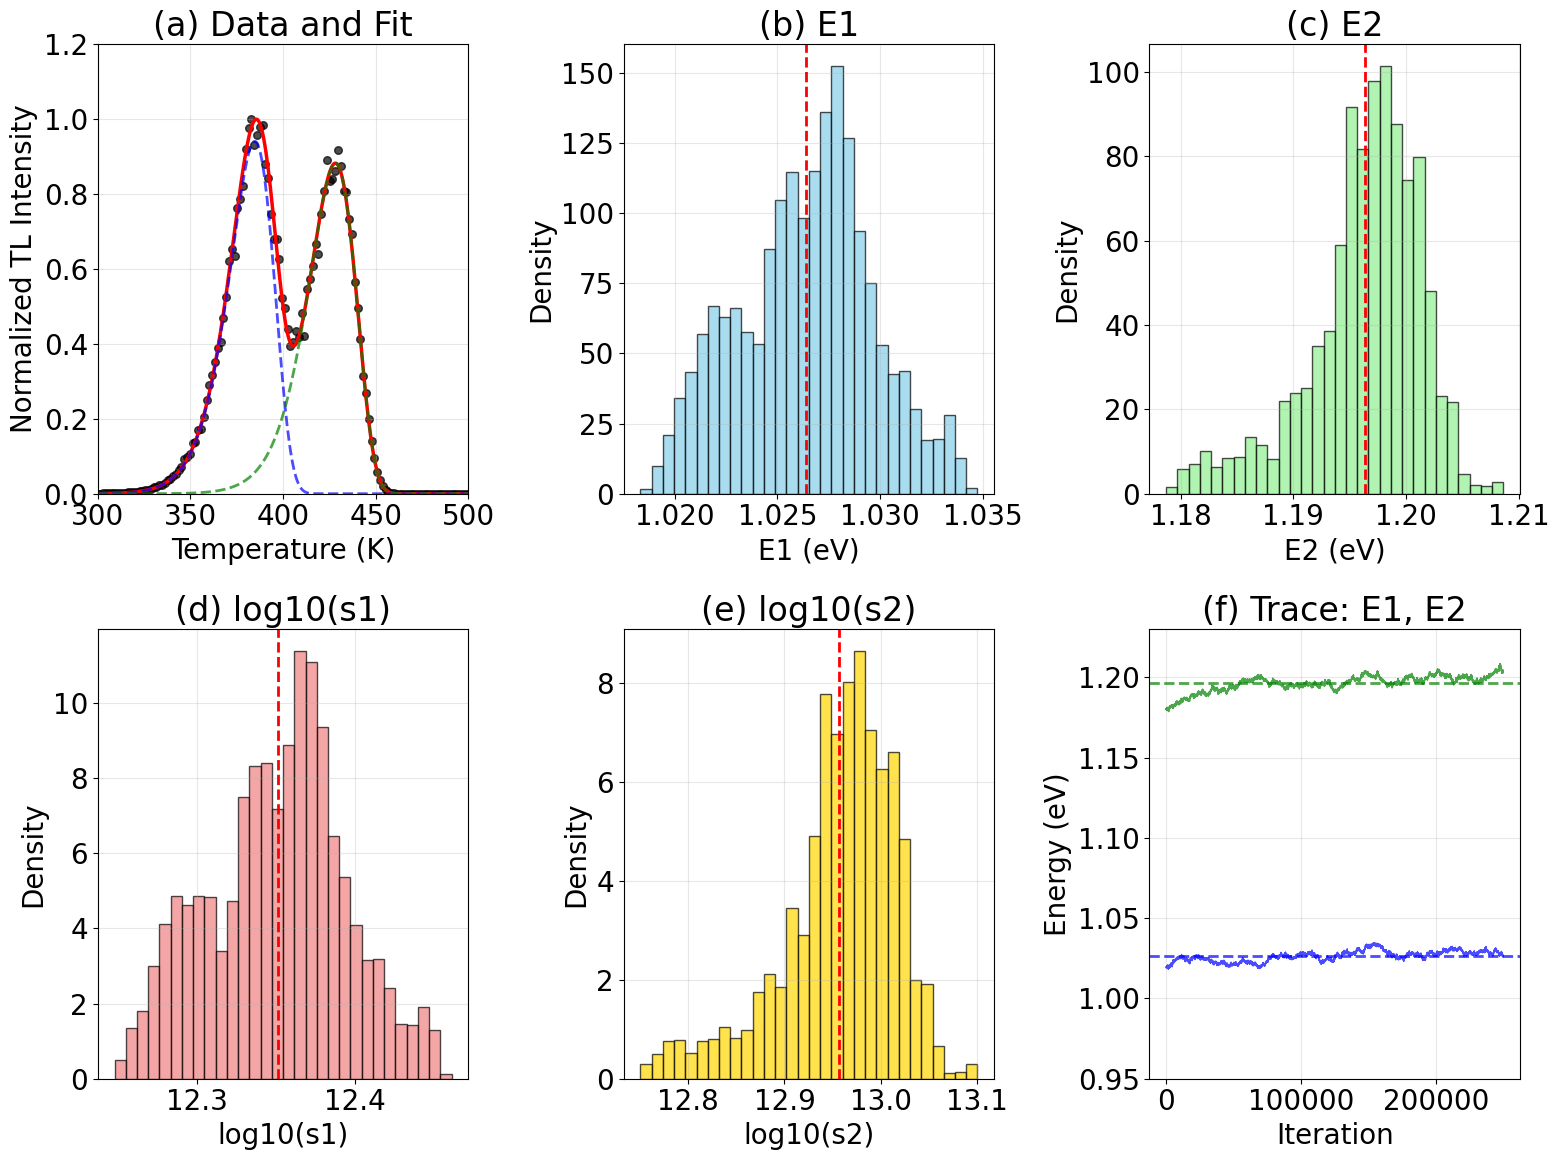


PARAMETER CORRELATIONS
Correlation between E1 and E2: 0.518
Correlation between E1 and log10(s1): 0.998
Correlation between E2 and log10(s2): 0.999

PHYSICAL INTERPRETATION
Peak 1: E = 1.026 ± 0.003 eV, s = 2.26e+12 s^-1
Peak 2: E = 1.196 ± 0.005 eV, s = 9.13e+12 s^-1

The two peaks correspond to different trapping centers in the material.
Peak 1 (lower temperature) has lower activation energy (1.026 eV)
Peak 2 (higher temperature) has higher activation energy (1.196 eV)


In [ ]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
print('-'*28,'CODE OUTPUT','-'*29)
rng = np.random.default_rng(seed=122)

# Simulate data from two first-order kinetics peaks
kB = 8.617E-5  # Boltzmann constant (eV/K)

def first_order_kinetics_unnormalized(T, E, s, beta=1.0):
    """
    First-order kinetics TL glow curve (Randall-Wilkins model) - UNNORMALIZED.
    Returns absolute intensity values.
    """
    kB = 8.617E-5  # Boltzmann constant (eV/K)
    eps = 1e-10    # Small number to avoid division by zero

    # Convert to numpy array if needed
    T = np.asarray(T)

    # Calculate the thermal integral approximation
    kT = kB * T
    E_over_kT = E / kT

    # Thermal integral approximation
    thermal_int = (kB * T**2 / E) * np.exp(-E_over_kT) * (1 - 2*kB*T/E + eps)

    # First-order kinetics (Randall-Wilkins equation) - return absolute intensity
    I_T = s * np.exp(-E_over_kT) * np.exp(-(s/beta) * thermal_int)

    return I_T

# Generate temperature range
x_data = np.linspace(300, 600, 200)  # Extended range to 600K for second peak

# Define parameters for two peaks
E1_true = 1.0  # eV
s1_true = 1e12  # s^-1
E2_true = 1.2  # eV
s2_true = 1e13  # s^-1

# Generate ideal data for both peaks (unnormalized)
y1_ideal = first_order_kinetics_unnormalized(x_data, E1_true, s1_true)
y2_ideal = first_order_kinetics_unnormalized(x_data, E2_true, s2_true)

# Combine peaks (sum of both)
y_ideal = y1_ideal + y2_ideal

# Normalize to maximum = 1
y_ideal = y_ideal / np.max(y_ideal)

# Add 5% multiplicative noise
np.random.seed(42)
noise = np.random.normal(0, 0.05, size=len(y_ideal))
y_data_noisy = y_ideal * (1 + noise)

# Ensure no negative values
y_data_noisy = np.maximum(y_data_noisy, 0)

# Re-normalize after adding noise
y_data = y_data_noisy / np.max(y_data_noisy)

print(f"Data points: {len(x_data)}")
print(f"Peak 1: E1={E1_true} eV, s1={s1_true:.1e} s^-1")
print(f"Peak 2: E2={E2_true} eV, s2={s2_true:.1e} s^-1")

# Modified two_peak_kinetics function without internal normalization
def two_peak_kinetics_unnormalized(T, E1, s1, E2, s2, beta=1.0):
    """
    Two-peak first-order kinetics TL glow curve - UNNORMALIZED.
    Returns absolute combined intensity.
    """
    # Calculate individual peaks (unnormalized)
    I1 = first_order_kinetics_unnormalized(T, E1, s1, beta)
    I2 = first_order_kinetics_unnormalized(T, E2, s2, beta)

    # Combine (no normalization)
    I_total = I1 + I2

    return I_total

def log_prior(E1, s1, E2, s2, sigma):
    """
    Log prior for all parameters.
    Uses weakly informative priors.
    """
    # Parameter constraints (physical)
    if E1 <= 0.7 or E1 > 2:
        return -np.inf
    if s1 <= 1e7 or s1 > 1e13:
        return -np.inf
    if E2 <= 0.7 or E2 > 2:
        return -np.inf
    if s2 <= 1e7 or s2 > 1e15:
        return -np.inf
    if sigma <= 0 or sigma > 1:
        return -np.inf

    # Weakly informative priors
    log_prior_E1 = -0.5 * ((E1 - 0.8) / 0.5) ** 2
    log_prior_E2 = -0.5 * ((E2 - 0.8) / 0.5) ** 2

    # Log-normal priors for frequency factors
    log10_s1 = np.log10(s1)
    log10_s2 = np.log10(s2)
    log_prior_s1 = -0.5 * ((log10_s1 - 10) / 2) ** 2
    log_prior_s2 = -0.5 * ((log10_s2 - 10) / 2) ** 2

    # sigma: Half-normal prior
    log_prior_sigma = -0.5 * (sigma / 0.1) ** 2

    return log_prior_E1 + log_prior_s1 + log_prior_E2 + log_prior_s2 + log_prior_sigma

def log_likelihood(y, y_pred, sigma):
    """Log likelihood assuming Gaussian errors"""
    n = len(y)
    return -0.5 * np.sum(((y - y_pred) / sigma) ** 2) - n * np.log(sigma)

def log_posterior(params, x, y):
    """Log posterior probability"""
    E1, s1, E2, s2, sigma = params
    y_pred = two_peak_kinetics_unnormalized(x, E1, s1, E2, s2)

    # Normalize prediction to match data (data is normalized to max=1)
    if np.max(y_pred) > 1e-10:
        y_pred = y_pred / np.max(y_pred)

    lp = log_prior(E1, s1, E2, s2, sigma)

    # Check if log_prior is finite
    if not np.isfinite(lp):
        return -np.inf

    # Check for NaN in predictions
    if np.any(np.isnan(y_pred)) or np.any(np.isinf(y_pred)):
        return -np.inf

    return lp + log_likelihood(y, y_pred, sigma)

def metropolis(x, y, n_steps, burn_in):
    """
    Metropolis-Hastings algorithm for two-peak first-order kinetics.
    Parameters: E1, s1, E2, s2, sigma
    """

    # Starting parameters (initial guesses)
    E1 = 0.95
    s1 = 5e11
    E2 = 1.15
    s2 = 5e10
    sigma = 0.05

    # Step sizes (tuned for good acceptance ~20-30%)
    step_E1 = 0.0005
    step_log10_s1 = 0.002
    step_E2 = 0.0005
    step_log10_s2 = 0.002
    step_sigma = 0.005

    # Work in log space for s for better mixing
    current_params = np.array([E1, np.log10(s1), E2, np.log10(s2), sigma])
    current_log_post = log_posterior([E1, s1, E2, s2, sigma], x, y)

    samples = []
    acceptance_count = 0

    print(f"Running MCMC for {n_steps} steps...")
    print(f"Parameters: E1 (eV), log10(s1), E2 (eV), log10(s2), sigma")

    for i in range(n_steps):
        # Propose new parameters
        proposed_params = current_params + rng.normal(0, [step_E1, step_log10_s1, step_E2, step_log10_s2, step_sigma])

        E1_prop = proposed_params[0]
        log10_s1_prop = proposed_params[1]
        s1_prop = 10 ** log10_s1_prop
        E2_prop = proposed_params[2]
        log10_s2_prop = proposed_params[3]
        s2_prop = 10 ** log10_s2_prop
        sigma_prop = proposed_params[4]

        # Check constraints
        if E1_prop <= 0.05 or E1_prop > 3.0:
            samples.append([current_params[0], 10**current_params[1],
                          current_params[2], 10**current_params[3], current_params[4]])
            continue
        if s1_prop <= 0 or s1_prop > 1e15:
            samples.append([current_params[0], 10**current_params[1],
                          current_params[2], 10**current_params[3], current_params[4]])
            continue
        if E2_prop <= 0.05 or E2_prop > 3.0:
            samples.append([current_params[0], 10**current_params[1],
                          current_params[2], 10**current_params[3], current_params[4]])
            continue
        if s2_prop <= 0 or s2_prop > 1e15:
            samples.append([current_params[0], 10**current_params[1],
                          current_params[2], 10**current_params[3], current_params[4]])
            continue
        if sigma_prop <= 0 or sigma_prop > 1:
            samples.append([current_params[0], 10**current_params[1],
                          current_params[2], 10**current_params[3], current_params[4]])
            continue

        # Compute log-posterior for proposed parameters
        new_log_post = log_posterior([E1_prop, s1_prop, E2_prop, s2_prop, sigma_prop], x, y)

        # Check for invalid posterior
        if not np.isfinite(new_log_post):
            samples.append([current_params[0], 10**current_params[1],
                          current_params[2], 10**current_params[3], current_params[4]])
            continue

        # Acceptance probability
        log_alpha = new_log_post - current_log_post

        if np.log(rng.random()) < log_alpha:
            current_params = proposed_params
            current_log_post = new_log_post
            acceptance_count += 1

        # Store samples
        samples.append([current_params[0], 10**current_params[1],
                       current_params[2], 10**current_params[3], current_params[4]])

        # Progress indicator
        if (i + 1) % 30000 == 0:
            print(f"  Step {i+1}/{n_steps}, Acceptance rate so far: {acceptance_count/(i+1):.3f}")

    acceptance_rate = acceptance_count / n_steps
    print(f"\nFinal acceptance rate: {acceptance_rate:.3f}")

    # Discard burn-in and return samples
    samples_array = np.array(samples[burn_in:])
    all_samples = np.array(samples)
    return all_samples, samples_array, acceptance_rate

# Run MCMC
print("\nStarting Metropolis-Hastings sampling...")
print("Using two-peak first-order kinetics (Randall-Wilkins equation)")
n_steps = 400000
burn_in = 150000

all_samples, samples, acceptance_rate = metropolis(x_data, y_data, n_steps, burn_in)

# Extract parameter samples
E1_samples = samples[:, 0]
s1_samples = samples[:, 1]
E2_samples = samples[:, 2]
s2_samples = samples[:, 3]
sigma_samples = samples[:, 4]

# Get posterior statistics
E1_est, E1_std = np.mean(E1_samples), np.std(E1_samples)
s1_est = np.mean(s1_samples)
E2_est, E2_std = np.mean(E2_samples), np.std(E2_samples)
s2_est = np.mean(s2_samples)
sigma_est = np.mean(sigma_samples)

E1_ci = np.percentile(E1_samples, [2.5, 97.5])
s1_ci = np.percentile(s1_samples, [2.5, 97.5])
E2_ci = np.percentile(E2_samples, [2.5, 97.5])
s2_ci = np.percentile(s2_samples, [2.5, 97.5])

print("\n" + "="*60)
print("METROPOLIS-HASTINGS RESULTS - TWO-PEAK FIRST-ORDER KINETICS")
print("="*60)
print(f"\nPeak 1:")
print(f"  E1 (activation energy) = {E1_est:.4f} ± {E1_std:.4f} eV")
print(f"    95% CI: [{E1_ci[0]:.4f}, {E1_ci[1]:.4f}] eV")
print(f"  s1 (frequency factor) = {s1_est:.2e} s^-1")
print(f"    95% CI: [{s1_ci[0]:.2e}, {s1_ci[1]:.2e}] s^-1")
print(f"  log10(s1) = {np.log10(s1_est):.2f} ± {np.std(np.log10(s1_samples)):.2f}")

print(f"\nPeak 2:")
print(f"  E2 (activation energy) = {E2_est:.4f} ± {E2_std:.4f} eV")
print(f"    95% CI: [{E2_ci[0]:.4f}, {E2_ci[1]:.4f}] eV")
print(f"  s2 (frequency factor) = {s2_est:.2e} s^-1")
print(f"    95% CI: [{s2_ci[0]:.2e}, {s2_ci[1]:.2e}] s^-1")
print(f"  log10(s2) = {np.log10(s2_est):.2f} ± {np.std(np.log10(s2_samples)):.2f}")

print(f"\nNoise parameter:")
print(f"  sigma = {sigma_est:.4f}")
print(f"    95% CI: [{np.percentile(sigma_samples, 2.5):.4f}, {np.percentile(sigma_samples, 97.5):.4f}]")
print(f"\nAcceptance rate: {acceptance_rate:.3f}")

# Calculate fit quality metrics
def calculate_metrics(y_true, y_pred):
    residuals = y_true - y_pred
    r_squared = 1 - np.sum(residuals**2) / np.sum((y_true - np.mean(y_true))**2)
    rmse = np.sqrt(np.mean(residuals**2))
    return r_squared, rmse

# Predictions with estimated parameters
y_pred_unnorm = two_peak_kinetics_unnormalized(x_data, E1_est, s1_est, E2_est, s2_est)
y_pred_mh = y_pred_unnorm / np.max(y_pred_unnorm)  # Normalize for comparison
r2_mh, rmse_mh = calculate_metrics(y_data, y_pred_mh)

print("\nFIT QUALITY METRICS:")
print(f"  R² = {r2_mh:.4f}")
print(f"  RMSE = {rmse_mh:.4f}")

# Create comprehensive plots (2x3 layout)
plt.rcParams["font.size"] = 20
fig = plt.figure(figsize=(16, 12))

# Plot 1: Data and fitted model
ax1 = plt.subplot(2, 3, 1)
ax1.scatter(x_data, y_data, alpha=0.7, label='Experimental Data', color='black', s=30)
x_fine = np.linspace(min(x_data), max(x_data), 500)

# Calculate unnormalized curves for plotting
y1_unnorm = first_order_kinetics_unnormalized(x_fine, E1_est, s1_est)
y2_unnorm = first_order_kinetics_unnormalized(x_fine, E2_est, s2_est)
y_total_unnorm = y1_unnorm + y2_unnorm

# Normalize total to 1 for plotting
norm_factor = np.max(y_total_unnorm)
y_total_norm = y_total_unnorm / norm_factor
y1_norm = y1_unnorm / norm_factor
y2_norm = y2_unnorm / norm_factor

# Plot
ax1.plot(x_fine, y_total_norm, 'r-', linewidth=2.5, label='Total Fit')
ax1.plot(x_fine, y1_norm, 'b--', linewidth=2, alpha=0.7,
         label=f'Peak 1 (E1={E1_est:.2f} eV)')
ax1.plot(x_fine, y2_norm, 'g--', linewidth=2, alpha=0.7,
         label=f'Peak 2 (E2={E2_est:.2f} eV)')

# Print actual heights
print(f"\nPeak heights in total fit:")
print(f"  Peak 1 height: {np.max(y1_norm):.3f}")
print(f"  Peak 2 height: {np.max(y2_norm):.3f}")

ax1.set_xlabel('Temperature (K)')
ax1.set_ylabel('Normalized TL Intensity')
ax1.set_ylim(0, 1.2)
ax1.set_xlim(300,500)
# ax1.legend(loc='best', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_title('(a) Data and Fit')

# Plot 2: Posterior distribution for E1
ax2 = plt.subplot(2, 3, 2)
ax2.hist(E1_samples, bins=30, alpha=0.7, density=True, edgecolor='black', color='skyblue')
ax2.axvline(E1_est, color='red', linestyle='--', linewidth=2, label=f'Mean: {E1_est:.3f} eV')
# ax2.axvline(E1_ci[0], color='black', linestyle=':', linewidth=2, label='95% CI')
# ax2.axvline(E1_ci[1], color='black', linestyle=':', linewidth=2)
ax2.set_xlabel('E1 (eV)')
ax2.set_ylabel('Density')
# ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_title('(b) E1')

# Plot 3: Posterior distribution for E2
ax3 = plt.subplot(2, 3, 3)
ax3.hist(E2_samples, bins=30, alpha=0.7, density=True, edgecolor='black', color='lightgreen')
ax3.axvline(E2_est, color='red', linestyle='--', linewidth=2, label=f'Mean: {E2_est:.3f} eV')
# ax3.axvline(E2_ci[0], color='black', linestyle=':', linewidth=2, label='95% CI')
# ax3.axvline(E2_ci[1], color='black', linestyle=':', linewidth=2)
ax3.set_xlabel('E2 (eV)')
ax3.set_ylabel('Density')
# ax3.legend(fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.set_title('(c) E2')

# Plot 4: Posterior distribution for log10(s1)
ax4 = plt.subplot(2, 3, 4)
log10_s1_samples = np.log10(s1_samples)
ax4.hist(log10_s1_samples, bins=30, alpha=0.7, density=True, edgecolor='black', color='lightcoral')
ax4.axvline(np.mean(log10_s1_samples), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(log10_s1_samples):.2f}')
ax4.set_xlabel('log10(s1)')
ax4.set_ylabel('Density')
# ax4.legend(fontsize=12)
ax4.grid(True, alpha=0.3)
ax4.set_title('(d) log10(s1)')

# Plot 5: Posterior distribution for log10(s2)
ax5 = plt.subplot(2, 3, 5)
log10_s2_samples = np.log10(s2_samples)
ax5.hist(log10_s2_samples, bins=30, alpha=0.7, density=True, edgecolor='black', color='gold')
ax5.axvline(np.mean(log10_s2_samples), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(log10_s2_samples):.2f}')
ax5.set_xlabel('log10(s2)')
ax5.set_ylabel('Density')
# ax5.legend(fontsize=12)
ax5.grid(True, alpha=0.3)
ax5.set_title('(e) log10(s2)')

# Plot 6: Combined trace plot for E1 and E2
ax6 = plt.subplot(2, 3, 6)
ax6.plot(E1_samples, alpha=0.7, linewidth=1, color='blue', label='E1')
ax6.plot(E2_samples, alpha=0.7, linewidth=1, color='green', label='E2')
ax6.axhline(E1_est, color='blue', linestyle='--', linewidth=2, alpha=0.7)
ax6.axhline(E2_est, color='green', linestyle='--', linewidth=2, alpha=0.7)
ax6.set_xlabel('Iteration')
ax6.set_ylabel('Energy (eV)')
# ax6.legend(fontsize=12)
ax6.grid(True, alpha=0.3)
ax6.set_title('(f) Trace: E1, E2')
ax6.set_ylim(.95,1.23)
plt.tight_layout()
plt.show()

# Print correlation between parameters
corr_E1_E2 = np.corrcoef(E1_samples, E2_samples)[0, 1]
corr_E1_log10s1 = np.corrcoef(E1_samples, log10_s1_samples)[0, 1]
corr_E2_log10s2 = np.corrcoef(E2_samples, log10_s2_samples)[0, 1]

print("\n" + "="*60)
print("PARAMETER CORRELATIONS")
print("="*60)
print(f"Correlation between E1 and E2: {corr_E1_E2:.3f}")
print(f"Correlation between E1 and log10(s1): {corr_E1_log10s1:.3f}")
print(f"Correlation between E2 and log10(s2): {corr_E2_log10s2:.3f}")

# Physical interpretation
print("\n" + "="*60)
print("PHYSICAL INTERPRETATION")
print("="*60)
print(f"Peak 1: E = {E1_est:.3f} ± {E1_std:.3f} eV, s = {s1_est:.2e} s^-1")
print(f"Peak 2: E = {E2_est:.3f} ± {E2_std:.3f} eV, s = {s2_est:.2e} s^-1")
print("\nThe two peaks correspond to different trapping centers in the material.")
print(f"Peak 1 (lower temperature) has lower activation energy ({E1_est:.3f} eV)")
print(f"Peak 2 (higher temperature) has higher activation energy ({E2_est:.3f} eV)")

# Code 3

Metropolis algorithm, CGCD of single peak experimental data for alumina.

This code produces Figures 5,6,7 in the paper

METROPOLIS-HASTINGS SAMPLING (SINGLE PEAK)

Fixed parameters:
  Imax1: 1.00
  Tmax1: 494.61 K

RUNNING METROPOLIS-HASTINGS SAMPLER (SINGLE PEAK)
Note: sigma uses Gaussian (normal) proposal distribution

Running 2 chains with 15000 iterations each...
Using Metropolis-Hastings with Gaussian proposals for ALL parameters
Including sigma with Gaussian (normal) proposal distribution
R1 prior: Truncated Gaussian on (0,1) with mean=0.5, std=0.17

Chain 1/2
  Iteration 5000/15000
  Iteration 10000/15000
  Iteration 15000/15000
  Completed 15000 iterations
Chain 1 sigma acceptance rate: 0.210
  Final proposal scales: R1=0.6746, E1=0.0380, sigma=0.0033

Chain 2/2
  Iteration 5000/15000
  Iteration 10000/15000
  Iteration 15000/15000
  Completed 15000 iterations
Chain 2 sigma acceptance rate: 0.211
  Final proposal scales: R1=0.2638, E1=0.0043, sigma=0.1369

Average sigma acceptance rate: 0.211

PARAMETER SUMMARY - METROPOLIS-HASTINGS SAMPLING (SINGLE PEAK)
Parameter Mean       Std        95% HPD 

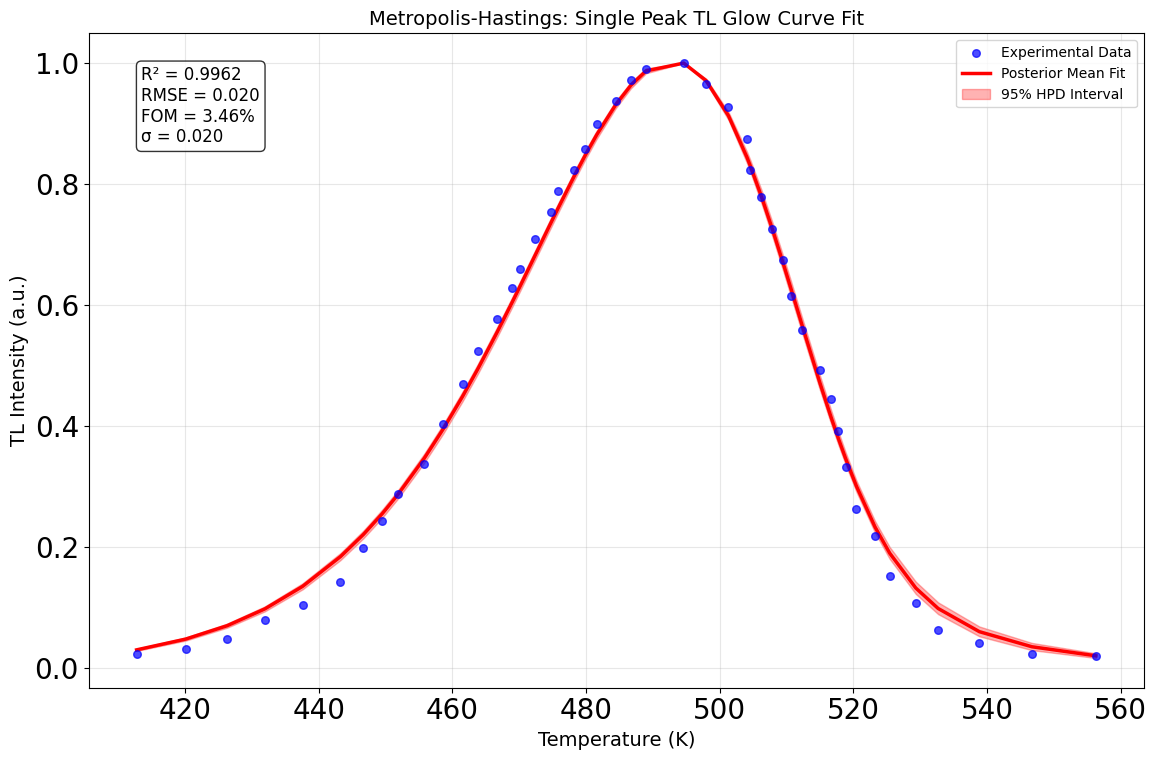

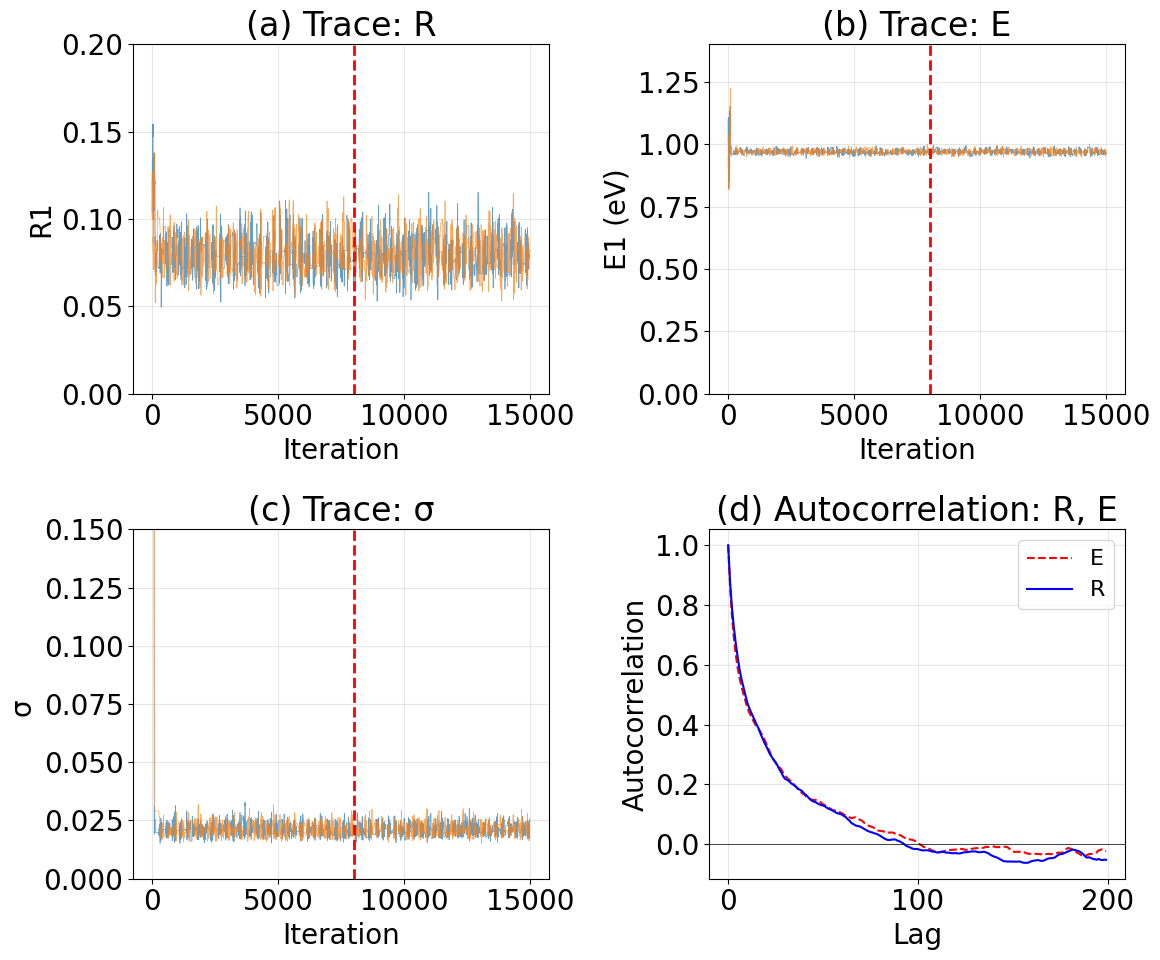

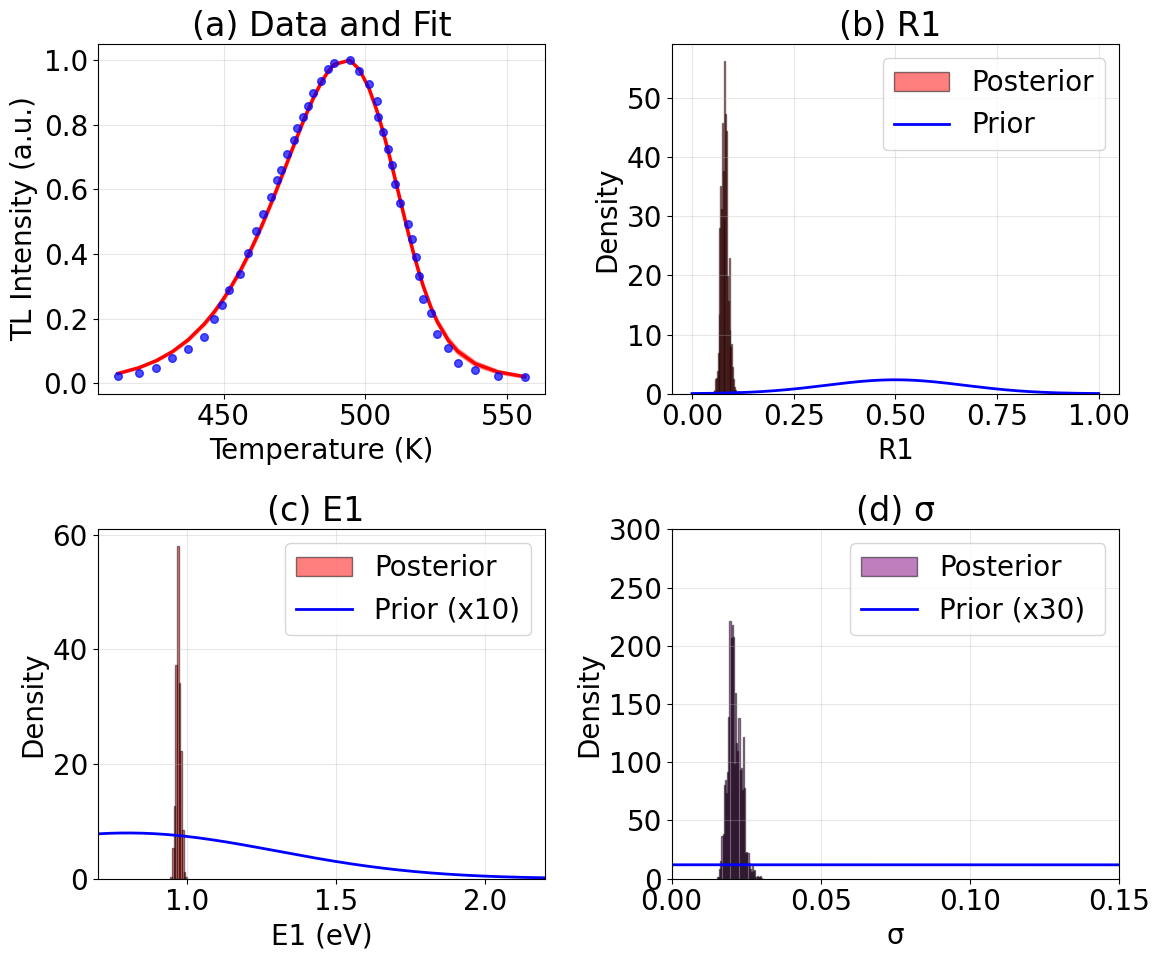

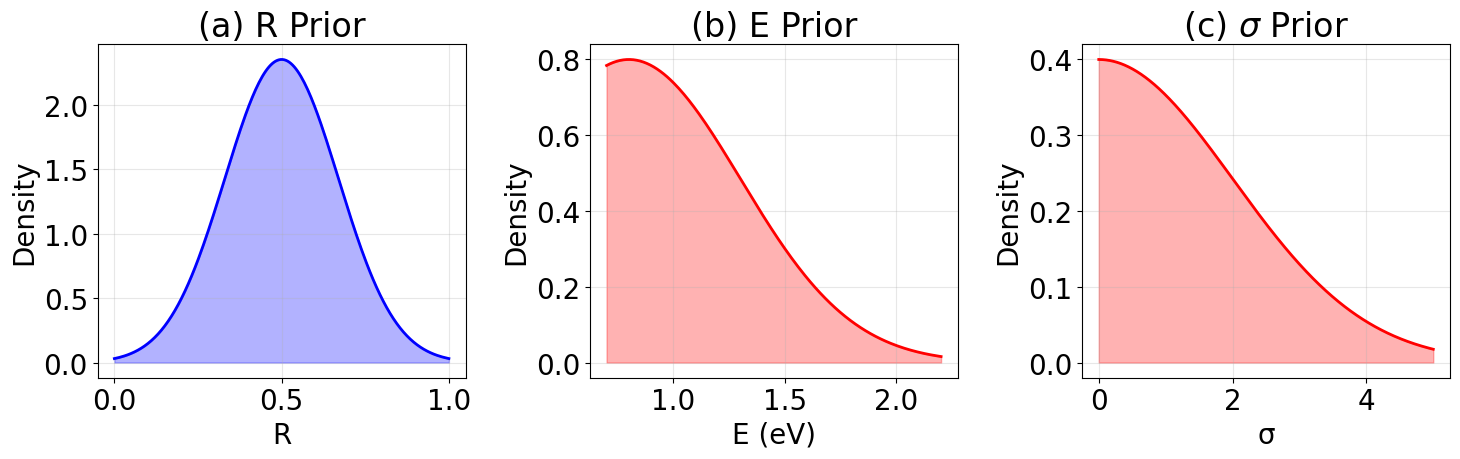

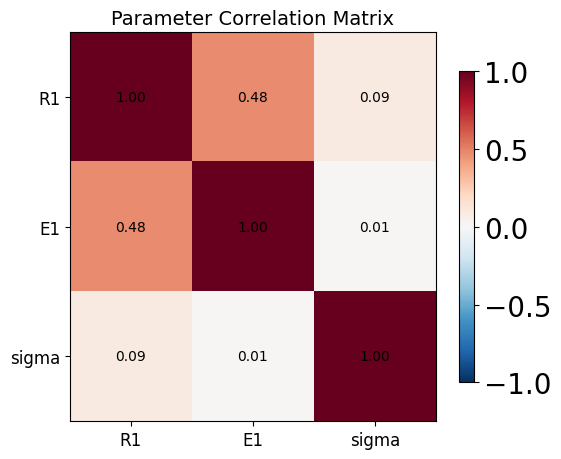


CORRELATION MATRIX
          R1        E1        sigma     
R1        1.000     0.476     0.090     
E1        0.476     1.000     0.008     
sigma     0.090     0.008     1.000     


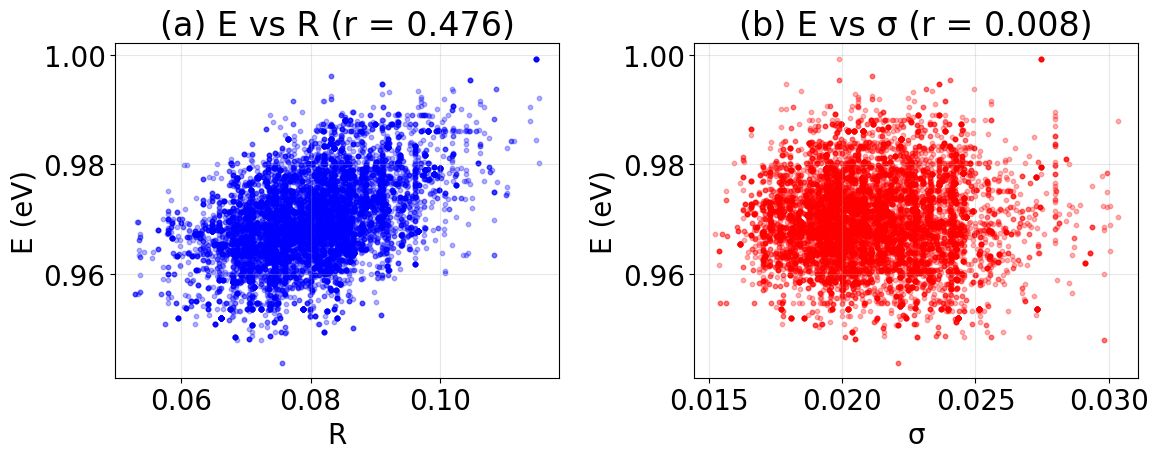


FINAL PARAMETER ESTIMATES (Metropolis-Hastings - SINGLE PEAK)
R1: 0.0797 ± 0.0088  [95% HPD: 0.0641, 0.0982]
E1: 0.9696 ± 0.0076  [95% HPD: 0.9541, 0.9861]
sigma: 0.0210 ± 0.0023  [95% HPD: 0.0172, 0.0256]

Best fit parameters (Maximum a Posteriori):
  R1: 0.0780
  E1: 0.9682
  sigma: 0.0200

METROPOLIS-HASTINGS SAMPLING SUMMARY
✓ Total samples per chain: 15000
✓ Burn-in samples: 8000
✓ Effective samples: 14000
✓ Average sigma acceptance rate: 0.211
✓ Proposal distribution: Gaussian (Normal) for ALL parameters including sigma
✓ R1 prior: Truncated Gaussian on (0,1) with mean=0.5, std=0.17
✓ Sampling method: Metropolis-Hastings (fully implemented)
✓ All R-hat values < 1.1: True

✓ Summary saved to 'metropolis_parameter_summary_single_peak.csv'


In [ ]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
from scipy.special import wrightomega
import os
import pandas as pd

plt.rcParams["font.size"] = 20
def readData():
    # read data from file in GitHub using pandas library
    url='https://github.com/vpagonis/Python-Codes/raw/main/Ch3PagonisGitHub/aluminaTLshort.TXT'

    df = pd.read_table(url)              # read data from file

    x_data = df.iloc[:, 0].to_numpy()	# temperature in deg C
    y_data = df.iloc[:, 1].to_numpy()	# TL in counts

    x_data = np.array([x_data[i]+273.15 for i in range(len(x_data))]) # temperature in K

    # normalize data and find Tmax to use in FOK equation
    A = max(y_data)
    x_data = np.array(x_data)
    y_data = np.array(y_data)/A

    Tmax = x_data[np.argmax(y_data)]    # Tmax = temperature of max TL intensity

    return [x_data, y_data, Tmax]

# Load data
x_data, y_data, Tmax_data = readData()
kB = 8.617E-5


# FIXED PARAMETERS (from previous fit or known values) - SINGLE PEAK ONLY
FIXED_Tmax1 = Tmax_data
FIXED_Imax1 = 1

# Initial parameter ESTIMATES - SINGLE PEAK ONLY
initial_params = {
    'R1': 0.1,
    'E1': 1.0,
    'sigma': 1.0
}

# Initial Uncertainty estimates
initial_uncertainties = {
    'R1': 0.03,
    'E1': 0.05,
    'sigma': 0.05
}

print("="*60)
print("METROPOLIS-HASTINGS SAMPLING (SINGLE PEAK)")
print("="*60)
print("\nFixed parameters:")
print(f"  Imax1: {FIXED_Imax1:.2f}")
print(f"  Tmax1: {FIXED_Tmax1:.2f} K")

def tl_peak_intensity(T, Imax, Tmax, R, E):
    """
    Calculate thermoluminescence intensity for a single peak.
    Added more robust numerical handling.
    """
    eps = 1e-6  # Increased epsilon for better numerical stability

    try:
        F = kB * (T**2) * np.exp(-E/(kB*T + eps)) * (1 - 2*kB*T/(E + eps)) / (E + eps)
        Fm = kB * (Tmax**2) * np.exp(-E/(kB*Tmax + eps)) * (1 - 2*kB*Tmax/(E + eps)) / (E + eps)
        a = kB * Tmax**2 * (1 - 1.05 * R**1.26) + eps
        term1 = R/(1-R + eps) - np.log((1-R)/(R + eps) + eps)
        exp_term = np.exp(E/(kB*Tmax + eps))

        Z = term1 + (F * E * exp_term) / a
        Zm = term1 + (Fm * E * exp_term) / a

        # Clip Z values to avoid overflow in exp
        Z = np.clip(Z, -500, 500)
        Zm = np.clip(Zm, -500, 500)

        argW = np.log(1 + np.exp(Z))
        argWm = np.log(1 + np.exp(Zm))

        # Ensure denominator is not zero
        denominator = argW + argW**2 + eps

        result = Imax * np.exp(-E/(kB*T + eps) * (Tmax - T)/Tmax) * (argWm + argWm**2) / denominator

        # Check for NaN or Inf
        if np.any(np.isnan(result)) or np.any(np.isinf(result)):
            return np.zeros_like(T)  # Return zeros instead of NaN/Inf

        return result
    except:
        return np.zeros_like(T)  # Return zeros if any error occurs

def tl_glow_curve(T, params_dict):
    """
    Calculate total thermoluminescence intensity - SINGLE PEAK ONLY.
    """
    # Single peak only
    Imax, Tmax, R, E = FIXED_Imax1, FIXED_Tmax1, params_dict['R1'], params_dict['E1']
    total_intensity = tl_peak_intensity(T, Imax, Tmax, R, E)

    # Ensure no negative values (physical constraint)
    total_intensity = np.maximum(total_intensity, 0)

    return total_intensity

# =============================================================================
# PRIOR DISTRIBUTIONS - GAUSSIANS ON (0,1) INTERVAL
# =============================================================================

# For R1 - Truncated Gaussian on (0,1) with mean=0.5, std=0.17
def log_prior_R1(R1):
    if R1 <= 0 or R1 >= 1:
        return -np.inf
    # Truncated Gaussian on (0,1) with mean=0.5, std=0.17
    mean_R = 0.5
    std_R = 0.17
    # Calculate normalization factor for truncation
    cdf_lower = stats.norm.cdf(0, mean_R, std_R)
    cdf_upper = stats.norm.cdf(1, mean_R, std_R)
    norm_factor = cdf_upper - cdf_lower
    return stats.norm.logpdf(R1, mean_R, std_R) - np.log(norm_factor)

def log_prior_E1(E1):
    if E1 < 0.8 or E1 > 2.2:
        return -np.inf
    return stats.norm.logpdf(E1, 0.8, 0.5)

def log_prior_sigma(sigma):
    if sigma <= 0:
        return -np.inf
    return stats.halfnorm.logpdf(sigma, scale=initial_params['sigma']*2)

def log_prior(params):
    """Joint log prior"""
    return (log_prior_R1(params['R1']) +
            log_prior_E1(params['E1']) +
            log_prior_sigma(params['sigma']))

# =============================================================================
# LIKELIHOOD FUNCTION
# =============================================================================

def log_likelihood(params):
    """Log likelihood assuming Normal errors"""
    mu = tl_glow_curve(x_data, params)
    return np.sum(stats.norm.logpdf(y_data, mu, params['sigma']))

def log_posterior(params):
    """Log posterior (up to constant)"""
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params)

# =============================================================================
# METROPOLIS-HASTINGS SAMPLER (SINGLE PEAK)
# =============================================================================

def metropolis_hastings_sampler(initial_params, n_iterations, n_chains=4,
                                 proposal_scale=0.05, target_acceptance=0.234):
    """
    Metropolis-Hastings sampler for single peak parameters including sigma.
    Uses Gaussian (normal) proposals for all parameters.
    """

    param_names = ['R1', 'E1', 'sigma']
    n_params = len(param_names)

    # Parameter bounds
    param_bounds = {
        'R1': (0, 1),
        'E1': (0.7, 2.2),
        'sigma': (0.0, 20)  # Added upper bound for sigma
    }

    # Initialize samples array
    samples = np.zeros((n_chains, n_iterations, n_params))
    acceptance = np.zeros((n_chains, n_iterations))
    acceptance_rates = np.zeros(n_chains)

    # Store log posterior for convergence diagnostics
    log_posterior_trace = np.zeros((n_chains, n_iterations))

    # Initialize proposal scales (adaptive)
    proposal_scales = {name: proposal_scale * abs(initial_params[name])
                       for name in param_names}

    print(f"\nRunning {n_chains} chains with {n_iterations} iterations each...")
    print("Using Metropolis-Hastings with Gaussian proposals for ALL parameters")
    print(f"Including sigma with Gaussian (normal) proposal distribution")
    print(f"R1 prior: Truncated Gaussian on (0,1) with mean=0.5, std=0.17")

    # Run chains
    for chain in range(n_chains):
        print(f"\nChain {chain+1}/{n_chains}")

        # Initialize chain with slight perturbation from initial params
        current_params = initial_params.copy()
        for name in param_names:
            if name == 'R1':  # Truncated Gaussian parameter (0-1 range)
                current_params[name] = np.clip(
                    current_params[name] + np.random.normal(0, 0.01),
                    param_bounds[name][0] + 0.01,
                    param_bounds[name][1] - 0.01
                )
            elif name == 'E1':  # Energy parameter
                current_params[name] = np.clip(
                    current_params[name] + np.random.normal(0, 0.02),
                    param_bounds[name][0],
                    param_bounds[name][1]
                )
            else:  # sigma - using Gaussian proposal
                current_params[name] = np.clip(
                    current_params[name] + np.random.normal(0, 0.5),
                    param_bounds[name][0],
                    param_bounds[name][1]
                )

        current_logp = log_posterior(current_params)

        # Adaptation variables for Metropolis steps
        recent_acceptances = {name: [] for name in param_names}
        scales = {name: proposal_scales[name] for name in param_names}

        # Main MCMC loop
        for i in range(n_iterations):
            # Store current sample
            samples[chain, i, :] = [current_params[name] for name in param_names]
            log_posterior_trace[chain, i] = current_logp

            # ============================================================
            # METROPOLIS STEP FOR ALL PARAMETERS (including sigma)
            # ============================================================
            for param_name in param_names:
                # Choose parameter to update
                current_val = current_params[param_name]
                proposal_std = scales[param_name]

                # Symmetric Gaussian (normal) proposal
                proposed_val = current_val + np.random.normal(0, proposal_std)

                # Apply bounds
                lower, upper = param_bounds[param_name]
                if proposed_val < lower or proposed_val > upper:
                    continue

                # Create proposed parameter dict
                proposed_params = current_params.copy()
                proposed_params[param_name] = proposed_val

                # Compute log posterior for proposed params
                proposed_logp = log_posterior(proposed_params)

                # Metropolis acceptance probability
                log_alpha = proposed_logp - current_logp

                # Accept or reject
                if np.log(np.random.random()) < log_alpha:
                    current_params = proposed_params
                    current_logp = proposed_logp
                    recent_acceptances[param_name].append(1)
                    if param_name == 'sigma':
                        acceptance[chain, i] = 1
                else:
                    recent_acceptances[param_name].append(0)
                    if param_name == 'sigma':
                        acceptance[chain, i] = 0

                # Adapt proposal scale (every 100 iterations)
                if len(recent_acceptances[param_name]) >= 100:
                    window_acceptance = np.mean(recent_acceptances[param_name][-100:])
                    if window_acceptance < target_acceptance:
                        scales[param_name] *= 0.95
                    elif window_acceptance > target_acceptance + 0.05:
                        scales[param_name] *= 1.05

                    scales[param_name] = np.clip(scales[param_name], 0.001, 1.0)

            # Progress indicator
            if (i + 1) % 5000 == 0:
                print(f"  Iteration {i+1}/{n_iterations}")

        print(f"  Completed {n_iterations} iterations")
        acceptance_rates[chain] = np.mean(acceptance[chain, :])
        print(f"Chain {chain+1} sigma acceptance rate: {acceptance_rates[chain]:.3f}")

        # Print final proposal scales for this chain
        print(f"  Final proposal scales: R1={scales['R1']:.4f}, E1={scales['E1']:.4f}, sigma={scales['sigma']:.4f}")

    return samples, acceptance_rates, param_names, log_posterior_trace

# =============================================================================
# RUN METROPOLIS-HASTINGS SAMPLING
# =============================================================================

n_iterations = 15000
n_burnin = 8000
n_chains = 2

print("\n" + "="*60)
print("RUNNING METROPOLIS-HASTINGS SAMPLER (SINGLE PEAK)")
print("="*60)
print("Note: sigma uses Gaussian (normal) proposal distribution")

samples, acceptance_rates, param_names, log_posterior_trace = metropolis_hastings_sampler(
    initial_params=initial_params,
    n_iterations=n_iterations,
    n_chains=n_chains,
    proposal_scale=0.05,
    target_acceptance=0.234
)

print(f"\nAverage sigma acceptance rate: {np.mean(acceptance_rates):.3f}")

# =============================================================================
# PROCESS SAMPLES
# =============================================================================

# Remove burn-in
samples_after_burnin = samples[:, n_burnin:, :]
n_effective_samples = samples_after_burnin.shape[0] * samples_after_burnin.shape[1]

# Reshape for analysis
samples_flat = samples_after_burnin.reshape(-1, len(param_names))

# Calculate means and standard deviations
means = np.mean(samples_flat, axis=0)
stds = np.std(samples_flat, axis=0)

# Calculate HPD intervals
hpd_lower = np.percentile(samples_flat, 2.5, axis=0)
hpd_upper = np.percentile(samples_flat, 97.5, axis=0)

print("\n" + "="*80)
print("PARAMETER SUMMARY - METROPOLIS-HASTINGS SAMPLING (SINGLE PEAK)")
print("="*80)
print(f"{'Parameter':<8} {'Mean':<10} {'Std':<10} {'95% HPD Lower':<15} {'95% HPD Upper':<15}")
print("-"*60)
for i, name in enumerate(param_names):
    print(f"{name:<8} {means[i]:<10.4f} {stds[i]:<10.4f} {hpd_lower[i]:<15.4f} {hpd_upper[i]:<15.4f}")

# =============================================================================
# GELMAN-RUBIN DIAGNOSTIC
# =============================================================================

def gelman_rubin(samples):
    n_chains, n_samples, n_params = samples.shape

    chain_means = np.mean(samples, axis=1)
    chain_vars = np.var(samples, axis=1, ddof=1)

    W = np.mean(chain_vars, axis=0)
    overall_mean = np.mean(chain_means, axis=0)
    B = n_samples * np.var(chain_means, axis=0, ddof=1)

    var_plus = (n_samples - 1) / n_samples * W + B / n_samples
    R_hat = np.sqrt(var_plus / W)

    return R_hat

r_hat_values = gelman_rubin(samples_after_burnin)

print("\n" + "="*80)
print("CONVERGENCE DIAGNOSTICS - GELMAN-RUBIN R-HAT")
print("="*80)
print(f"{'Parameter':<8} {'R-hat':<12} {'Converged?':<15}")
print("-"*40)
for i, name in enumerate(param_names):
    converged = "✓ Yes" if r_hat_values[i] < 1.1 else "✗ No"
    print(f"{name:<8} {r_hat_values[i]:<12.6f} {converged:<15}")

# =============================================================================
# EFFECTIVE SAMPLE SIZE (ESS)
# =============================================================================

def effective_sample_size(samples):
    """Calculate effective sample size for each parameter"""
    n_chains, n_samples, n_params = samples.shape
    ess = np.zeros(n_params)

    for p in range(n_params):
        # Combine all chains
        chain_samples = samples[:, :, p]

        # Calculate within-chain variance
        within_var = np.mean([np.var(chain) for chain in chain_samples])

        # Calculate between-chain variance
        chain_means = np.mean(chain_samples, axis=1)
        between_var = np.var(chain_means) * n_samples

        # Calculate autocorrelation
        total_var = ((n_samples - 1) / n_samples) * within_var + (1 / n_samples) * between_var

        # Simple ESS approximation
        rho_hat = r_hat_values[p]  # Use R-hat as correlation measure
        ess[p] = n_chains * n_samples / (1 + 2 * rho_hat)

    return ess

ess_values = effective_sample_size(samples_after_burnin)

print("\n" + "="*80)
print("CONVERGENCE DIAGNOSTICS - EFFECTIVE SAMPLE SIZE")
print("="*80)
print(f"{'Parameter':<8} {'ESS':<12} {'Efficiency (%)':<15}")
print("-"*40)
total_samples = samples_after_burnin.shape[0] * samples_after_burnin.shape[1]
for i, name in enumerate(param_names):
    efficiency = (ess_values[i] / total_samples) * 100
    print(f"{name:<8} {ess_values[i]:<12.1f} {efficiency:<15.1f}")

# =============================================================================
# AUTOCORRELATION FUNCTION
# =============================================================================

def autocorrelation(x, max_lag=100):
    """Calculate autocorrelation function"""
    x_centered = x - np.mean(x)
    n = len(x_centered)
    result = np.correlate(x_centered, x_centered, mode='full')
    result = result[result.size // 2:]
    result /= result[0]
    return result[:max_lag]

# =============================================================================
# CALCULATE MEAN FIT AND FIT STATISTICS
# =============================================================================

print("\n" + "="*80)
print("CALCULATING FIT STATISTICS")
print("="*80)

# Take a subset of samples to speed up calculation (every 10th sample)
n_total = len(samples_flat)
n_used = min(2000, n_total)  # Use up to 2000 samples
indices = np.linspace(0, n_total-1, n_used, dtype=int)

print(f"Using {n_used} samples out of {n_total} for fit calculation")

mu_samples = []
valid_samples = 0

for i, idx in enumerate(indices):
    if i % 500 == 0 and i > 0:
        print(f"  Processed {i}/{n_used} samples")

    params_dict = dict(zip(param_names, samples_flat[idx, :]))
    curve = tl_glow_curve(x_data, params_dict)

    # Check for NaN or Inf
    if not np.any(np.isnan(curve)) and not np.any(np.isinf(curve)):
        mu_samples.append(curve)
        valid_samples += 1

print(f"  Valid samples: {valid_samples}/{n_used}")

if valid_samples == 0:
    print("ERROR: No valid samples found! Using LS estimates for fit.")
    # Fallback to LS estimates
    params_dict = initial_params.copy()
    mu_mean = tl_glow_curve(x_data, params_dict)
    mu_hpd_lower = mu_mean * 0.9
    mu_hpd_upper = mu_mean * 1.1
else:
    mu_samples = np.array(mu_samples)
    mu_mean = np.mean(mu_samples, axis=0)
    mu_hpd_lower = np.percentile(mu_samples, 2.5, axis=0)
    mu_hpd_upper = np.percentile(mu_samples, 97.5, axis=0)

# Calculate best fit (Maximum a Posteriori)
best_idx = np.argmax([log_posterior(dict(zip(param_names, samples_flat[i, :])))
                      for i in range(len(samples_flat))])
best_params = dict(zip(param_names, samples_flat[best_idx, :]))

# Calculate fit statistics
residuals = y_data - mu_mean
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - (ss_res / ss_tot)
n = len(y_data)
p = 2  # 2 parameters (R1 and E1) plus sigma but sigma is noise
adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)
rmse = np.sqrt(np.mean(residuals**2))
fom = np.sum(np.abs(residuals)) / np.sum(mu_mean) * 100

print("\nFIT STATISTICS RESULTS:")
print("-" * 40)
print(f"RMSE: {rmse:.6f}")
print(f"R²: {r_squared:.6f}")
print(f"Adjusted R²: {adj_r_squared:.6f}")
print(f"FOM: {fom:.4f}%")

# =============================================================================
# PLOT 1: DATA VS FIT
# =============================================================================

fig_fit, ax_fit = plt.subplots(figsize=(12, 8))

# Plot experimental data
ax_fit.scatter(x_data, y_data, s=30, alpha=0.7, color='blue',
               label='Experimental Data', zorder=3)

# Plot mean fit and HPD interval
ax_fit.plot(x_data, mu_mean, 'r-', linewidth=2.5,
            label='Posterior Mean Fit', zorder=2)
ax_fit.fill_between(x_data, mu_hpd_lower, mu_hpd_upper, alpha=0.3,
                    color='red', label='95% HPD Interval')

# Add fit statistics text box
stats_text = f'R² = {r_squared:.4f}\nRMSE = {rmse:.3f}\nFOM = {fom:.2f}%\nσ = {best_params["sigma"]:.3f}'
ax_fit.text(0.05, 0.95, stats_text, transform=ax_fit.transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax_fit.set_xlabel('Temperature (K)', fontsize=14)
ax_fit.set_ylabel('TL Intensity (a.u.)', fontsize=14)
ax_fit.set_title('Metropolis-Hastings: Single Peak TL Glow Curve Fit', fontsize=14)
ax_fit.legend(loc='best', fontsize=10)
ax_fit.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# CONVERGENCE PLOTS
# =============================================================================

fig_convergence, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Plot 1: Trace plot for R
ax = axes[0]
for chain in range(n_chains):
    ax.plot(samples[chain, :, 0], alpha=0.7, linewidth=0.5, label=f'Chain {chain+1}' if chain == 0 else "")
ax.axvline(n_burnin, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('R1')
ax.set_title('(a) Trace: R')
# ax.legend(fontsize=8)
ax.set_ylim(0,.2)
ax.grid(True, alpha=0.3)

# Plot 2: Trace plot for E
ax = axes[1]
for chain in range(n_chains):
    ax.plot(samples[chain, :, 1], alpha=0.7, linewidth=0.5, label=f'Chain {chain+1}' if chain == 0 else "")
ax.axvline(n_burnin, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('E1 (eV)')
ax.set_title('(b) Trace: E')
# ax.legend(fontsize=8)
ax.set_ylim(0,1.4)
ax.grid(True, alpha=0.3)

# Plot 3: Trace plot for sigma
ax = axes[2]
for chain in range(n_chains):
    ax.plot(samples[chain, :, 2], alpha=0.7, linewidth=0.5, label=f'Chain {chain+1}' if chain == 0 else "")
ax.axvline(n_burnin, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('σ ')
ax.set_title('(c) Trace: σ')
# ax.legend(fontsize=8)
ax.set_ylim(0,.15)
ax.grid(True, alpha=0.3)

# Plot 4: Autocorrelation for R, E
ax = axes[3]
combined_samples = samples_after_burnin[:, :, 1].flatten()
acf = autocorrelation(combined_samples, max_lag=200)
ax.plot(acf, 'r--', linewidth=1.5,label='E')

combined_samples = samples_after_burnin[:, :, 0].flatten()
acf = autocorrelation(combined_samples, max_lag=200)
ax.plot(acf, 'b-', linewidth=1.5,label='R')

ax.axhline(0, color='black', linewidth=0.5)
# ax.axhline(0.1, color='red', linestyle='--', alpha=0.5, label='Threshold (0.1)')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
ax.set_title('(d) Autocorrelation: R, E')
ax.legend(fontsize=16)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# PRIOR VS POSTERIOR COMPARISON
# =============================================================================

fig_prior, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Plot 1: Data and Fit
ax_fit = axes[0]
ax_fit.scatter(x_data, y_data, s=30, alpha=0.7, color='blue',
               label='Experimental Data', zorder=3)
ax_fit.plot(x_data, mu_mean, 'r-', linewidth=2.5,
            label='Posterior Mean Fit', zorder=2)
ax_fit.fill_between(x_data, mu_hpd_lower, mu_hpd_upper, alpha=0.3,
                    color='red', label='95% HPD Interval')
ax_fit.set_xlabel('Temperature (K)')
ax_fit.set_ylabel('TL Intensity (a.u.)')
ax_fit.set_title('(a) Data and Fit')

ax_fit.grid(True, alpha=0.3)

# Plot 2: Prior vs Posterior for sigma
ax5 = axes[3]
x_sigma = np.linspace(0, 5, 200)
prior_sigma = stats.halfnorm.pdf(x_sigma, scale=initial_params['sigma']*2)
ax5.hist(samples_flat[:, 2], bins=40, density=True, alpha=0.5, color='purple',
         edgecolor='black', label='Posterior')
ax5.plot(x_sigma, 30*prior_sigma, 'b-', linewidth=2, label='Prior (x30) ')
ax5.set_xlabel('σ')
ax5.set_ylabel('Density')
ax5.set_title('(d) σ')
ax5.legend()
ax5.set_xlim(0,.15)
ax5.set_ylim(0,300)
ax5.grid(True, alpha=0.3)

# Plot 3: Prior vs Posterior for R1
ax1 = axes[1]
x_r1 = np.linspace(0, 1, 200)
mean_R = 0.5
std_R = 0.17
cdf_lower = stats.norm.cdf(0, mean_R, std_R)
cdf_upper = stats.norm.cdf(1, mean_R, std_R)
norm_factor = cdf_upper - cdf_lower
prior_r1 = stats.norm.pdf(x_r1, mean_R, std_R) / norm_factor
ax1.hist(samples_flat[:, 0], bins=30, density=True, alpha=0.5, color='red',
         edgecolor='black', label='Posterior')
ax1.plot(x_r1, prior_r1, 'b-', linewidth=2, label='Prior')
ax1.set_xlabel('R1')
ax1.set_ylabel('Density')
ax1.set_title('(b) R1 ')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 4: Prior vs Posterior for E1
ax2 = axes[2]
x_e1 = np.linspace(0.7, 2.2, 200)
prior_e1 = stats.norm.pdf(x_e1, 0.8, 0.5)
ax2.hist(samples_flat[:, 1], bins=10, density=True, alpha=0.5, color='red',
         edgecolor='black', label='Posterior')
ax2.plot(x_e1, 10*prior_e1, 'b-', linewidth=2, label='Prior (x10)')
ax2.set_xlabel('E1 (eV)')
ax2.set_ylabel('Density')
ax2.set_title('(c) E1 ')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.7,2.2)
plt.tight_layout()
plt.show()

# =============================================================================
# PRIORS PLOT
# =============================================================================

fig_prior_only, axes = plt.subplots(1, 3, figsize=(15, 5))
plt.rcParams["font.size"] = 20

# Prior for R1 - Truncated Gaussian
ax1 = axes[0]
x_r1 = np.linspace(0, 1, 200)
mean_R = 0.5
std_R = 0.17
cdf_lower = stats.norm.cdf(0, mean_R, std_R)
cdf_upper = stats.norm.cdf(1, mean_R, std_R)
norm_factor = cdf_upper - cdf_lower
prior_r1 = stats.norm.pdf(x_r1, mean_R, std_R) / norm_factor
ax1.plot(x_r1, prior_r1, 'b-', linewidth=2, label='Prior')
ax1.fill_between(x_r1, 0, prior_r1, alpha=0.3, color='blue')
ax1.set_xlabel('R')
ax1.set_ylabel('Density')
ax1.set_title('(a) R Prior')
ax1.grid(True, alpha=0.3)

# Prior for E1
ax4 = axes[1]
x_e1 = np.linspace(0.7, 2.2, 200)
prior_e1 = stats.norm.pdf(x_e1, 0.8, 0.5)
ax4.plot(x_e1, prior_e1, 'r-', linewidth=2, label='Prior (Normal)')
ax4.fill_between(x_e1, 0, prior_e1, alpha=0.3, color='red')
ax4.set_xlabel('E (eV)')
ax4.set_ylabel('Density')
ax4.set_title('(b) E Prior')
ax4.grid(True, alpha=0.3)

# Prior for sigma: Half-normal
sigma_prior_range = np.linspace(0, 5, 1000)
sigma_prior_density = stats.halfnorm.pdf(sigma_prior_range, scale=initial_params['sigma']*2)
axes[2].plot(sigma_prior_range, sigma_prior_density, 'r-', linewidth=2)
axes[2].fill_between(sigma_prior_range, 0, sigma_prior_density, alpha=0.3, color='red')
axes[2].set_xlabel('σ')
axes[2].set_ylabel('Density')
axes[2].set_title(r'(c) $\sigma$ Prior ')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# CORRELATION MATRIX
# =============================================================================

# Create correlation matrix
fig_corr, ax_corr = plt.subplots(figsize=(6, 5))

# Calculate correlation matrix for all parameters
param_data = samples_flat
corr_matrix = np.corrcoef(param_data.T)

# Plot correlation matrix as heatmap
im = ax_corr.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax_corr.set_xticks(np.arange(len(param_names)))
ax_corr.set_yticks(np.arange(len(param_names)))
ax_corr.set_xticklabels(param_names, fontsize=12)
ax_corr.set_yticklabels(param_names, fontsize=12)
ax_corr.set_title('Parameter Correlation Matrix', fontsize=14)

# Add colorbar
plt.colorbar(im, ax=ax_corr, shrink=0.8)

# Add correlation values in cells
for i in range(len(param_names)):
    for j in range(len(param_names)):
        text = ax_corr.text(j, i, f'{corr_matrix[i, j]:.2f}',
                           ha="center", va="center", color="black", fontsize=10)

plt.tight_layout()
plt.show()

# Print correlation matrix as table
print("\n" + "="*60)
print("CORRELATION MATRIX")
print("="*60)
print(f"{'':<10}", end="")
for name in param_names:
    print(f"{name:<10}", end="")
print()
for i, name_i in enumerate(param_names):
    print(f"{name_i:<10}", end="")
    for j, name_j in enumerate(param_names):
        print(f"{corr_matrix[i, j]:<10.3f}", end="")
    print()

# =============================================================================
# SCATTER PLOTS
# =============================================================================

# Create scatter plots: E1 vs R1 and E1 vs sigma
fig_scatter, axes = plt.subplots(1, 2, figsize=(12, 5))

plt.rcParams["font.size"] = 20

# Panel 1: E1 vs R1
corr_R1_E1 = np.corrcoef(samples_flat[:, 0], samples_flat[:, 1])[0, 1]
ax1 = axes[0]
ax1.scatter(samples_flat[:, 0], samples_flat[:, 1], alpha=0.3, s=10, c='blue')
ax1.set_xlabel('R')
ax1.set_ylabel('E (eV)')
ax1.set_title(f'(a) E vs R (r = {corr_R1_E1:.3f})')
ax1.grid(True, alpha=0.3)

# Panel 2: E1 vs sigma
corr_sigma_E1 = np.corrcoef(samples_flat[:, 2], samples_flat[:, 1])[0, 1]
ax2 = axes[1]
ax2.scatter(samples_flat[:, 2], samples_flat[:, 1], alpha=0.3, s=10, c='red')
ax2.set_xlabel('σ')
ax2.set_ylabel('E (eV)')
ax2.set_title(f'(b) E vs σ (r = {corr_sigma_E1:.3f})')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# FINAL SUMMARY
# =============================================================================

print("\n" + "="*80)
print("FINAL PARAMETER ESTIMATES (Metropolis-Hastings - SINGLE PEAK)")
print("="*80)

for i, param in enumerate(param_names):
    print(f"{param}: {means[i]:.4f} ± {stds[i]:.4f}  [95% HPD: {hpd_lower[i]:.4f}, {hpd_upper[i]:.4f}]")

print(f"\nBest fit parameters (Maximum a Posteriori):")
for i, param in enumerate(param_names):
    print(f"  {param}: {best_params[param]:.4f}")

print("\n" + "="*80)
print("METROPOLIS-HASTINGS SAMPLING SUMMARY")
print("="*80)
print(f"✓ Total samples per chain: {n_iterations}")
print(f"✓ Burn-in samples: {n_burnin}")
print(f"✓ Effective samples: {n_effective_samples}")
print(f"✓ Average sigma acceptance rate: {np.mean(acceptance_rates):.3f}")
print(f"✓ Proposal distribution: Gaussian (Normal) for ALL parameters including sigma")
print(f"✓ R1 prior: Truncated Gaussian on (0,1) with mean=0.5, std=0.17")
print(f"✓ Sampling method: Metropolis-Hastings (fully implemented)")
print(f"✓ All R-hat values < 1.1: {all(r < 1.1 for r in r_hat_values)}")
print("="*80)

# Save results
summary_df = pd.DataFrame({
    'Parameter': param_names,
    'Mean': means,
    'Std': stds,
    'HDI_2.5%': hpd_lower,
    'HDI_97.5%': hpd_upper,
    'R_hat': r_hat_values,
    'ESS': ess_values
})

# summary_df.to_csv('metropolis_parameter_summary_single_peak.csv', index=False)
print("\n✓ Summary saved to 'metropolis_parameter_summary_single_peak.csv'")

# Code 4

Metropolis algorithm, double peak experimental TL from sample LBO.

Produces Figures 10, 11 in the paper.

METROPOLIS-HASTINGS SAMPLING (ALL PARAMETERS)

Fixed parameters:
  Imax1: 119.42
  Tmax1: 464.00 K
  Imax2: 22.85
  Tmax2: 519.38 K

RUNNING METROPOLIS-HASTINGS SAMPLER (ALL PARAMETERS)
Note: sigma uses Gaussian (normal) proposal distribution

Running 2 chains with 15000 iterations each...
Using Metropolis-Hastings with Gaussian proposals for ALL parameters
Including sigma with Gaussian (normal) proposal distribution
R1 and R2 priors: Truncated Gaussians on (0,1) with mean=0.5, std=0.17

Chain 1/2
  Iteration 5000/15000
  Iteration 10000/15000
  Iteration 15000/15000
  Completed 15000 iterations
Chain 1 sigma acceptance rate: 0.279
  Final proposal scales: R1=0.0010, E1=0.1842, R2=0.2920, E2=0.0945, sigma=0.5057

Chain 2/2
  Iteration 5000/15000
  Iteration 10000/15000
  Iteration 15000/15000
  Completed 15000 iterations
Chain 2 sigma acceptance rate: 0.279
  Final proposal scales: R1=0.0010, E1=0.0232, R2=0.0778, E2=0.0769, sigma=0.4309

Average sigma acceptance rate: 0.279

PARAMETER

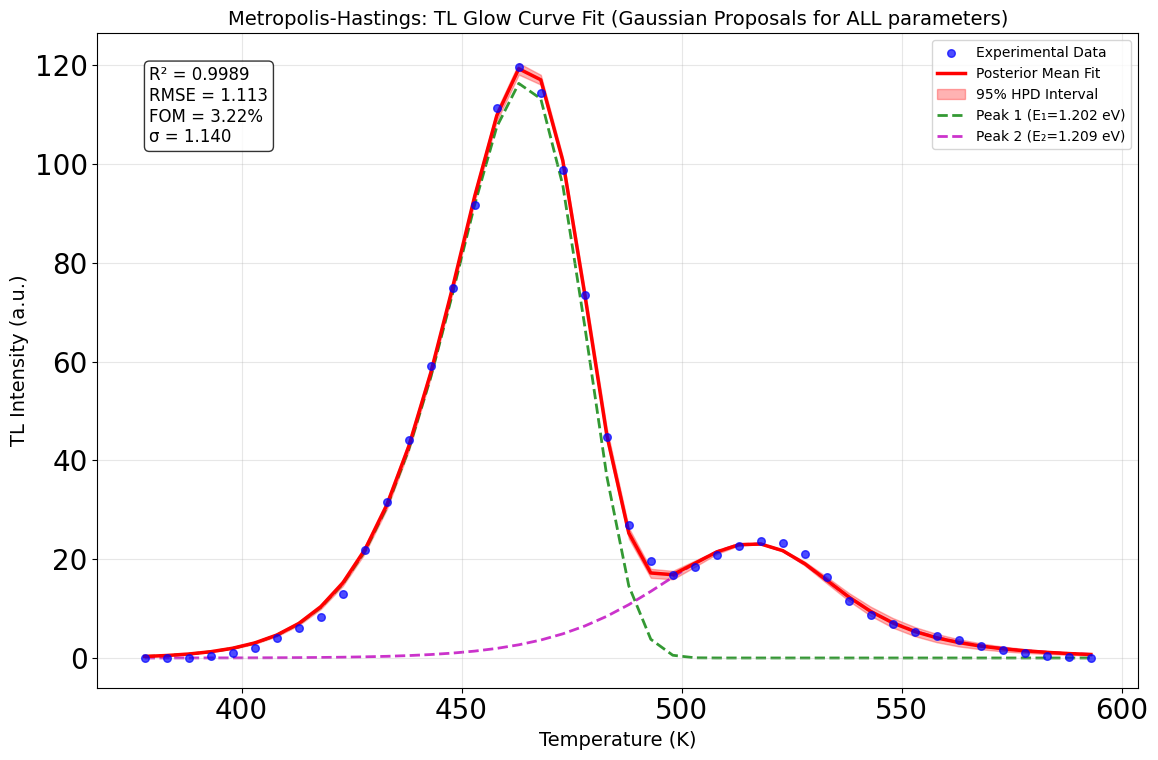

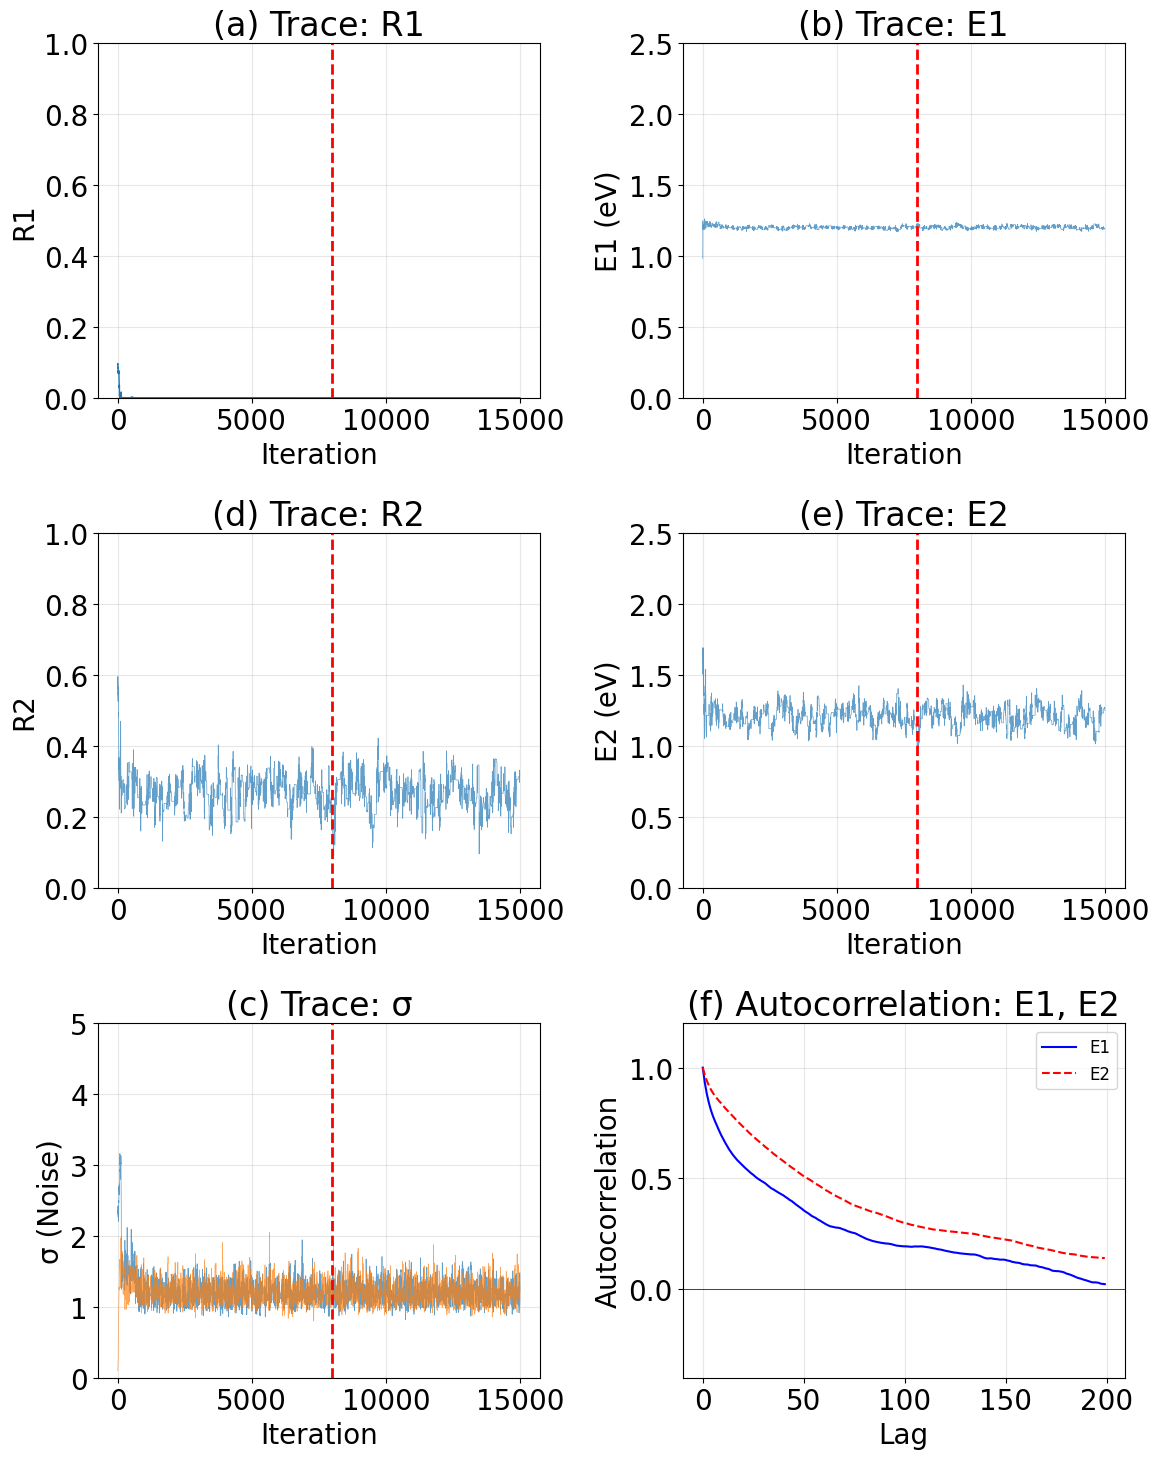


FINAL PARAMETER ESTIMATES (Metropolis-Hastings with Gaussian Proposals)
R1: 0.000019 ± 0.000005  [95% HPD: 0.000013, 0.000029]
E1: 1.203470 ± 0.010650  [95% HPD: 1.183261, 1.224101]
R2: 0.267015 ± 0.047315  [95% HPD: 0.162528, 0.355551]
E2: 1.204925 ± 0.070379  [95% HPD: 1.062651, 1.338618]
sigma: 1.199817 ± 0.137937  [95% HPD: 0.966331, 1.506603]

Best fit parameters (Maximum a Posteriori):
  R1: 0.0000
  E1: 1.2021
  R2: 0.2733
  E2: 1.2092
  sigma: 1.1399

METROPOLIS-HASTINGS SAMPLING SUMMARY
✓ Total samples per chain: 15000
✓ Burn-in samples: 8000
✓ Effective samples: 14000
✓ Average sigma acceptance rate: 0.279
✓ Proposal distribution: Gaussian (Normal) for ALL parameters including sigma
✓ R1 and R2 priors: Truncated Gaussians on (0,1) with mean=0.5, std=0.17
✓ Sampling method: Metropolis-Hastings (fully implemented)
✓ All R-hat values < 1.1: True

✓ Results ready for saving


In [ ]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
from scipy.special import wrightomega
import os
import pandas as pd

plt.rcParams["font.size"] = 20

def readData():
    """Read TL data from GitHub."""
    url = 'https://raw.githubusercontent.com/vpagonis/Python-Codes/refs/heads/main/Ch3PagonisGitHub/lbodata.txt'
    df = pd.read_table(url)

    x_data = df.iloc[:, 0].to_numpy().astype(float)   # Convert to float to avoid type issues
    y_data = df.iloc[:, 1].to_numpy().astype(float)   # Convert to float

    # Normalize
    # y_data = y_data / np.max(y_data)
    Tmax = x_data[np.argmax(y_data)]

    return x_data, y_data, Tmax

# Load data
x_data, y_data, Tmax_data = readData()
kB = 8.617E-5

# FIXED PARAMETERS (from previous fit or known values)
FIXED_Imax1 = 119.42
FIXED_Tmax1 = 464.0  # Convert to float
FIXED_Imax2 = 22.85
FIXED_Tmax2 = 519.38

# Initial parameter ESTIMATES
initial_params = {
    'R1': 0.1,
    'E1': 1.0,
    'R2': 0.6,
    'E2': 1.6,
    'sigma': 1.0
}

# Initial Uncertainty estimates
initial_uncertainties = {
    'R1': 0.03,
    'E1': 0.05,
    'R2': 0.04,
    'E2': 0.06,
    'sigma': 0.5
}

print("="*60)
print("METROPOLIS-HASTINGS SAMPLING (ALL PARAMETERS)")
print("="*60)
print("\nFixed parameters:")
print(f"  Imax1: {FIXED_Imax1:.2f}")
print(f"  Tmax1: {FIXED_Tmax1:.2f} K")
print(f"  Imax2: {FIXED_Imax2:.2f}")
print(f"  Tmax2: {FIXED_Tmax2:.2f} K")

def tl_peak_intensity(T, Imax, Tmax, R, E):
    """
    Calculate thermoluminescence intensity for a single peak.
    Added more robust numerical handling.
    """
    eps = 1e-6  # Increased epsilon for better numerical stability

    # Ensure T is float type
    T = np.asarray(T, dtype=float)
    Tmax = float(Tmax)
    Imax = float(Imax)
    R = float(R)
    E = float(E)

    try:
        F = kB * (T**2) * np.exp(-E/(kB*T + eps)) * (1 - 2*kB*T/(E + eps)) / (E + eps)
        Fm = kB * (Tmax**2) * np.exp(-E/(kB*Tmax + eps)) * (1 - 2*kB*Tmax/(E + eps)) / (E + eps)
        a = kB * Tmax**2 * (1 - 1.05 * R**1.26) + eps
        term1 = R/(1-R + eps) - np.log((1-R)/(R + eps) + eps)
        exp_term = np.exp(E/(kB*Tmax + eps))

        Z = term1 + (F * E * exp_term) / a
        Zm = term1 + (Fm * E * exp_term) / a

        # Clip Z values to avoid overflow in exp
        Z = np.clip(Z, -500, 500)
        Zm = np.clip(Zm, -500, 500)

        argW = np.log(1 + np.exp(Z))
        argWm = np.log(1 + np.exp(Zm))

        # Ensure denominator is not zero
        denominator = argW + argW**2 + eps

        result = Imax * np.exp(-E/(kB*T + eps) * (Tmax - T)/Tmax) * (argWm + argWm**2) / denominator

        # Check for NaN or Inf
        if np.any(np.isnan(result)) or np.any(np.isinf(result)):
            return np.zeros_like(T)  # Return zeros instead of NaN/Inf

        return result
    except Exception as e:
        print(f"Error in tl_peak_intensity: {e}")
        return np.zeros_like(T)  # Return zeros if any error occurs

def tl_glow_curve(T, params_dict):
    """
    Calculate total thermoluminescence intensity.
    """
    # Ensure T is float type
    T = np.asarray(T, dtype=float)

    peaks = [
        (FIXED_Imax1, FIXED_Tmax1, params_dict['R1'], params_dict['E1']),
        (FIXED_Imax2, FIXED_Tmax2, params_dict['R2'], params_dict['E2'])
    ]

    total_intensity = np.zeros_like(T, dtype=float)
    for params in peaks:
        Imax, Tmax, R, E = params
        peak_intensity = tl_peak_intensity(T, Imax, Tmax, R, E)
        total_intensity += peak_intensity

    # Ensure no negative values (physical constraint)
    total_intensity = np.maximum(total_intensity, 0)

    return total_intensity

# =============================================================================
# PRIOR DISTRIBUTIONS - REPLACED BETA WITH GAUSSIANS ON (0,1) INTERVAL
# =============================================================================

# For R1 - Truncated Gaussian on (0,1) with mean=0.5, std=0.2
# This gives a symmetric prior centered at 0.5
def log_prior_R1(R1):
    if R1 <= 0 or R1 >= 1:
        return -np.inf
    # Truncated Gaussian on (0,1) with mean=0.5, std=0.17
    # Using stats.norm.logpdf and adjusting for truncation
    mean_R = 0.5
    std_R = 0.17
    # Calculate normalization factor for truncation
    cdf_lower = stats.norm.cdf(0, mean_R, std_R)
    cdf_upper = stats.norm.cdf(1, mean_R, std_R)
    norm_factor = cdf_upper - cdf_lower
    return stats.norm.logpdf(R1, mean_R, std_R) - np.log(norm_factor)

# For R2 - Truncated Gaussian on (0,1) with mean=0.5, std=0.17
def log_prior_R2(R2):
    if R2 <= 0 or R2 >= 1:
        return -np.inf
    # Truncated Gaussian on (0,1) with mean=0.5, std=0.17
    mean_R = 0.5
    std_R = 0.17
    cdf_lower = stats.norm.cdf(0, mean_R, std_R)
    cdf_upper = stats.norm.cdf(1, mean_R, std_R)
    norm_factor = cdf_upper - cdf_lower
    return stats.norm.logpdf(R2, mean_R, std_R) - np.log(norm_factor)

def log_prior_E1(E1):
    if E1 < 0.8 or E1 > 2.2:
        return -np.inf
    return stats.norm.logpdf(E1, 0.8, 0.5)

def log_prior_E2(E2):
    if E2 < 0.8 or E2 > 2.2:
        return -np.inf
    return stats.norm.logpdf(E2, 0.8, 0.5)

def log_prior_sigma(sigma):
    if sigma <= 0:
        return -np.inf
    return stats.halfnorm.logpdf(sigma, scale=initial_params['sigma']*2)

def log_prior(params):
    """Joint log prior"""
    return (log_prior_R1(params['R1']) +
            log_prior_E1(params['E1']) +
            log_prior_R2(params['R2']) +
            log_prior_E2(params['E2']) +
            log_prior_sigma(params['sigma']))

# =============================================================================
# LIKELIHOOD FUNCTION
# =============================================================================

def log_likelihood(params):
    """Log likelihood assuming Normal errors"""
    mu = tl_glow_curve(x_data, params)
    return np.sum(stats.norm.logpdf(y_data, mu, params['sigma']))

def log_posterior(params):
    """Log posterior (up to constant)"""
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params)

# =============================================================================
# METROPOLIS-HASTINGS SAMPLER (ALL PARAMETERS)
# =============================================================================

def metropolis_hastings_sampler(initial_params, n_iterations, n_chains=4,
                                 proposal_scale=0.05, target_acceptance=0.234):
    """
    Metropolis-Hastings sampler for all parameters including sigma.
    Uses Gaussian (normal) proposals for all parameters.
    """

    param_names = ['R1', 'E1', 'R2', 'E2', 'sigma']
    n_params = len(param_names)

    # Parameter bounds
    param_bounds = {
        'R1': (0, 1),
        'E1': (0.8, 2.2),
        'R2': (0, 1),
        'E2': (0.8, 2.2),
        'sigma': (0.1, 20)  # Added upper bound for sigma
    }

    # Initialize samples array
    samples = np.zeros((n_chains, n_iterations, n_params))
    acceptance = np.zeros((n_chains, n_iterations))
    acceptance_rates = np.zeros(n_chains)

    # Store log posterior for convergence diagnostics
    log_posterior_trace = np.zeros((n_chains, n_iterations))

    # Initialize proposal scales (adaptive)
    proposal_scales = {name: proposal_scale * abs(initial_params[name])
                       for name in param_names}

    print(f"\nRunning {n_chains} chains with {n_iterations} iterations each...")
    print("Using Metropolis-Hastings with Gaussian proposals for ALL parameters")
    print(f"Including sigma with Gaussian (normal) proposal distribution")
    print(f"R1 and R2 priors: Truncated Gaussians on (0,1) with mean=0.5, std=0.17")

    # Run chains
    for chain in range(n_chains):
        print(f"\nChain {chain+1}/{n_chains}")

        # Initialize chain with slight perturbation from initial params
        current_params = initial_params.copy()
        for name in param_names:
            if name in ['R1', 'R2']:  # Truncated Gaussian parameters (0-1 range)
                current_params[name] = np.clip(
                    current_params[name] + np.random.normal(0, 0.01),
                    param_bounds[name][0] + 0.01,
                    param_bounds[name][1] - 0.01
                )
            elif name in ['E1', 'E2']:  # Energy parameters
                current_params[name] = np.clip(
                    current_params[name] + np.random.normal(0, 0.02),
                    param_bounds[name][0],
                    param_bounds[name][1]
                )
            else:  # sigma - using Gaussian proposal
                current_params[name] = np.clip(
                    current_params[name] + np.random.normal(0, 0.5),
                    param_bounds[name][0],
                    param_bounds[name][1]
                )

        current_logp = log_posterior(current_params)

        # Adaptation variables for Metropolis steps
        recent_acceptances = {name: [] for name in param_names}
        scales = {name: proposal_scales[name] for name in param_names}

        # Main MCMC loop
        for i in range(n_iterations):
            # Store current sample
            samples[chain, i, :] = [current_params[name] for name in param_names]
            log_posterior_trace[chain, i] = current_logp

            # ============================================================
            # METROPOLIS STEP FOR ALL PARAMETERS (including sigma)
            # ============================================================
            for param_name in param_names:
                # Choose parameter to update
                current_val = current_params[param_name]
                proposal_std = scales[param_name]

                # Symmetric Gaussian (normal) proposal
                proposed_val = current_val + np.random.normal(0, proposal_std)

                # Apply bounds
                lower, upper = param_bounds[param_name]
                if proposed_val < lower or proposed_val > upper:
                    continue

                # Create proposed parameter dict
                proposed_params = current_params.copy()
                proposed_params[param_name] = proposed_val

                # Compute log posterior for proposed params
                proposed_logp = log_posterior(proposed_params)

                # Metropolis acceptance probability
                log_alpha = proposed_logp - current_logp

                # Accept or reject
                if np.log(np.random.random()) < log_alpha:
                    current_params = proposed_params
                    current_logp = proposed_logp
                    recent_acceptances[param_name].append(1)
                    if param_name == 'sigma':
                        acceptance[chain, i] = 1
                else:
                    recent_acceptances[param_name].append(0)
                    if param_name == 'sigma':
                        acceptance[chain, i] = 0

                # Adapt proposal scale (every 100 iterations)
                if len(recent_acceptances[param_name]) >= 100:
                    window_acceptance = np.mean(recent_acceptances[param_name][-100:])
                    if window_acceptance < target_acceptance:
                        scales[param_name] *= 0.95
                    elif window_acceptance > target_acceptance + 0.05:
                        scales[param_name] *= 1.05

                    scales[param_name] = np.clip(scales[param_name], 0.001, 1.0)

            # Progress indicator
            if (i + 1) % 5000 == 0:
                print(f"  Iteration {i+1}/{n_iterations}")

        print(f"  Completed {n_iterations} iterations")
        acceptance_rates[chain] = np.mean(acceptance[chain, :])
        print(f"Chain {chain+1} sigma acceptance rate: {acceptance_rates[chain]:.3f}")

        # Print final proposal scales for this chain
        print(f"  Final proposal scales: R1={scales['R1']:.4f}, E1={scales['E1']:.4f}, "
              f"R2={scales['R2']:.4f}, E2={scales['E2']:.4f}, sigma={scales['sigma']:.4f}")

    return samples, acceptance_rates, param_names, log_posterior_trace

# =============================================================================
# RUN METROPOLIS-HASTINGS SAMPLING
# =============================================================================

# initial_params = initial_params.copy()
n_iterations = 15000
n_burnin = 8000
n_chains = 2

print("\n" + "="*60)
print("RUNNING METROPOLIS-HASTINGS SAMPLER (ALL PARAMETERS)")
print("="*60)
print("Note: sigma uses Gaussian (normal) proposal distribution")

samples, acceptance_rates, param_names, log_posterior_trace = metropolis_hastings_sampler(
    initial_params=initial_params,
    n_iterations=n_iterations,
    n_chains=n_chains,
    proposal_scale=0.05,
    target_acceptance=0.234
)

print(f"\nAverage sigma acceptance rate: {np.mean(acceptance_rates):.3f}")

# =============================================================================
# PROCESS SAMPLES
# =============================================================================

# Remove burn-in
samples_after_burnin = samples[:, n_burnin:, :]
n_effective_samples = samples_after_burnin.shape[0] * samples_after_burnin.shape[1]

# Reshape for analysis
samples_flat = samples_after_burnin.reshape(-1, len(param_names))

# Calculate means and standard deviations
means = np.mean(samples_flat, axis=0)
stds = np.std(samples_flat, axis=0)

# Calculate HPD intervals
hpd_lower = np.percentile(samples_flat, 2.5, axis=0)
hpd_upper = np.percentile(samples_flat, 97.5, axis=0)

print("\n" + "="*80)
print("PARAMETER SUMMARY - METROPOLIS-HASTINGS SAMPLING")
print("="*80)
print(f"{'Parameter':<8} {'Mean':<10} {'Std':<10} {'95% HPD Lower':<15} {'95% HPD Upper':<15}")
print("-"*60)
for i, name in enumerate(param_names):
    print(f"{name:<8} {means[i]:<10.4f} {stds[i]:<10.4f} {hpd_lower[i]:<15.4f} {hpd_upper[i]:<15.4f}")

# =============================================================================
# GELMAN-RUBIN DIAGNOSTIC
# =============================================================================

def gelman_rubin(samples):
    n_chains, n_samples, n_params = samples.shape

    chain_means = np.mean(samples, axis=1)
    chain_vars = np.var(samples, axis=1, ddof=1)

    W = np.mean(chain_vars, axis=0)
    overall_mean = np.mean(chain_means, axis=0)
    B = n_samples * np.var(chain_means, axis=0, ddof=1)

    var_plus = (n_samples - 1) / n_samples * W + B / n_samples
    R_hat = np.sqrt(var_plus / W)

    return R_hat

r_hat_values = gelman_rubin(samples_after_burnin)

print("\n" + "="*80)
print("CONVERGENCE DIAGNOSTICS - GELMAN-RUBIN R-HAT")
print("="*80)
print(f"{'Parameter':<8} {'R-hat':<12} {'Converged?':<15}")
print("-"*40)
for i, name in enumerate(param_names):
    converged = "✓ Yes" if r_hat_values[i] < 1.1 else "✗ No"
    print(f"{name:<8} {r_hat_values[i]:<12.6f} {converged:<15}")

# =============================================================================
# EFFECTIVE SAMPLE SIZE (ESS)
# =============================================================================

def effective_sample_size(samples):
    """Calculate effective sample size for each parameter"""
    n_chains, n_samples, n_params = samples.shape
    ess = np.zeros(n_params)

    for p in range(n_params):
        # Combine all chains
        chain_samples = samples[:, :, p]

        # Calculate within-chain variance
        within_var = np.mean([np.var(chain) for chain in chain_samples])

        # Calculate between-chain variance
        chain_means = np.mean(chain_samples, axis=1)
        between_var = np.var(chain_means) * n_samples

        # Calculate autocorrelation
        total_var = ((n_samples - 1) / n_samples) * within_var + (1 / n_samples) * between_var

        # Simple ESS approximation
        rho_hat = r_hat_values[p]  # Use R-hat as correlation measure
        ess[p] = n_chains * n_samples / (1 + 2 * rho_hat)

    return ess

ess_values = effective_sample_size(samples_after_burnin)

print("\n" + "="*80)
print("CONVERGENCE DIAGNOSTICS - EFFECTIVE SAMPLE SIZE")
print("="*80)
print(f"{'Parameter':<8} {'ESS':<12} {'Efficiency (%)':<15}")
print("-"*40)
total_samples = samples_after_burnin.shape[0] * samples_after_burnin.shape[1]
for i, name in enumerate(param_names):
    efficiency = (ess_values[i] / total_samples) * 100
    print(f"{name:<8} {ess_values[i]:<12.1f} {efficiency:<15.1f}")

# =============================================================================
# AUTOCORRELATION FUNCTION
# =============================================================================

def autocorrelation(x, max_lag=100):
    """Calculate autocorrelation function"""
    x_centered = x - np.mean(x)
    n = len(x_centered)
    result = np.correlate(x_centered, x_centered, mode='full')
    result = result[result.size // 2:]
    result /= result[0]
    return result[:max_lag]

# =============================================================================
# CALCULATE MEAN FIT AND FIT STATISTICS
# =============================================================================

print("\n" + "="*80)
print("CALCULATING FIT STATISTICS")
print("="*80)

# Take a subset of samples to speed up calculation (every 10th sample)
n_total = len(samples_flat)
n_used = min(2000, n_total)  # Use up to 2000 samples
indices = np.linspace(0, n_total-1, n_used, dtype=int)

print(f"Using {n_used} samples out of {n_total} for fit calculation")

mu_samples = []
valid_samples = 0

for i, idx in enumerate(indices):
    if i % 500 == 0 and i > 0:
        print(f"  Processed {i}/{n_used} samples")

    params_dict = dict(zip(param_names, samples_flat[idx, :]))
    curve = tl_glow_curve(x_data, params_dict)

    # Check for NaN or Inf
    if not np.any(np.isnan(curve)) and not np.any(np.isinf(curve)):
        mu_samples.append(curve)
        valid_samples += 1

print(f"  Valid samples: {valid_samples}/{n_used}")

if valid_samples == 0:
    print("ERROR: No valid samples found! Using LS estimates for fit.")
    # Fallback to LS estimates
    params_dict = initial_params.copy()
    mu_mean = tl_glow_curve(x_data, params_dict)
    mu_hpd_lower = mu_mean * 0.9
    mu_hpd_upper = mu_mean * 1.1
else:
    mu_samples = np.array(mu_samples)
    mu_mean = np.mean(mu_samples, axis=0)
    mu_hpd_lower = np.percentile(mu_samples, 2.5, axis=0)
    mu_hpd_upper = np.percentile(mu_samples, 97.5, axis=0)

# Calculate individual peaks for best fit
best_idx = np.argmax([log_posterior(dict(zip(param_names, samples_flat[i, :])))
                      for i in range(len(samples_flat))])
best_params = dict(zip(param_names, samples_flat[best_idx, :]))

# Calculate individual peaks
def calculate_individual_peaks(params_dict):
    peak1 = tl_peak_intensity(x_data, FIXED_Imax1, FIXED_Tmax1, params_dict['R1'], params_dict['E1'])
    peak2 = tl_peak_intensity(x_data, FIXED_Imax2, FIXED_Tmax2, params_dict['R2'], params_dict['E2'])
    return peak1, peak2

peak1_best, peak2_best = calculate_individual_peaks(best_params)

# Calculate fit statistics
residuals = y_data - mu_mean
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - (ss_res / ss_tot)
n = len(y_data)
p = 4
adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)
rmse = np.sqrt(np.mean(residuals**2))
fom = np.sum(np.abs(residuals)) / np.sum(mu_mean) * 100

print("\nFIT STATISTICS RESULTS:")
print("-" * 40)
print(f"RMSE: {rmse:.6f}")
print(f"R²: {r_squared:.6f}")
print(f"Adjusted R²: {adj_r_squared:.6f}")
print(f"FOM: {fom:.4f}%")

# =============================================================================
# SINGLE PLOT: DATA VS FIT WITH COMPONENTS
# =============================================================================

fig_fit, ax_fit = plt.subplots(figsize=(12, 8))

# Plot experimental data
ax_fit.scatter(x_data, y_data, s=30, alpha=0.7, color='blue',
               label='Experimental Data', zorder=3)

# Plot mean fit and HPD interval
ax_fit.plot(x_data, mu_mean, 'r-', linewidth=2.5,
            label='Posterior Mean Fit', zorder=2)
ax_fit.fill_between(x_data, mu_hpd_lower, mu_hpd_upper, alpha=0.3,
                    color='red', label='95% HPD Interval')

# Plot individual peaks
ax_fit.plot(x_data, peak1_best, 'g--', linewidth=2, alpha=0.8,
            label=f'Peak 1 (E₁={best_params["E1"]:.3f} eV)', zorder=1)
ax_fit.plot(x_data, peak2_best, 'm--', linewidth=2, alpha=0.8,
            label=f'Peak 2 (E₂={best_params["E2"]:.3f} eV)', zorder=1)

# Add fit statistics text box
stats_text = f'R² = {r_squared:.4f}\nRMSE = {rmse:.3f}\nFOM = {fom:.2f}%\nσ = {best_params["sigma"]:.3f}'
ax_fit.text(0.05, 0.95, stats_text, transform=ax_fit.transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax_fit.set_xlabel('Temperature (K)', fontsize=14)
ax_fit.set_ylabel('TL Intensity (a.u.)', fontsize=14)
ax_fit.set_title('Metropolis-Hastings: TL Glow Curve Fit (Gaussian Proposals for ALL parameters)', fontsize=14)
ax_fit.legend(loc='best', fontsize=10)
ax_fit.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# CONVERGENCE PLOTS
# =============================================================================

fig_convergence, axes = plt.subplots(3,2, figsize=(12, 15))
axes = axes.flatten()

# Plot 1: Trace plots for R1
ax = axes[0]
ax.plot(samples[0, :, 0], linewidth=1)
ax.axvline(n_burnin, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('R1')
ax.set_ylim(0, 1)
ax.set_title('(a) Trace: R1')
ax.grid(True, alpha=0.3)

# Plot 2: Trace plot for E1
ax = axes[1]
ax.plot(samples[0, :, 1], alpha=0.7, linewidth=0.5)
ax.axvline(n_burnin, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('E1 (eV)')
ax.set_title('(b) Trace: E1')
ax.set_ylim(0, 2.5)
ax.grid(True, alpha=0.3)

# Plot 3: Trace plot for sigma
ax = axes[4]
for chain in range(n_chains):
    ax.plot(samples[chain, :, 4], alpha=0.7, linewidth=0.5)
ax.axvline(n_burnin, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('σ (Noise)')
ax.set_ylim(0, 5)
ax.set_title('(c) Trace: σ')
ax.grid(True, alpha=0.3)

# Plot 4: Trace plot for R2
ax = axes[2]
ax.plot(samples[0, :, 2], alpha=0.7, linewidth=0.5)
ax.axvline(n_burnin, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('R2')
ax.set_title('(d) Trace: R2')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# Plot 5: Trace plot for E2
ax = axes[3]
ax.plot(samples[0, :, 3], alpha=0.7, linewidth=0.5)
ax.axvline(n_burnin, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('E2 (eV)')
ax.set_title('(e) Trace: E2')
ax.set_ylim(0, 2.5)
ax.grid(True, alpha=0.3)

# Plot 6: Autocorrelation for E1, E2
ax = axes[5]
combined_samples = samples_after_burnin[:, :, 1].flatten()
acf = autocorrelation(combined_samples, max_lag=200)
ax.plot(acf, 'b-', linewidth=1.5, label='E1')
combined_samples = samples_after_burnin[:, :, 3].flatten()
acf = autocorrelation(combined_samples, max_lag=200)
ax.plot(acf, 'r--', linewidth=1.5, label='E2')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
ax.set_title('(f) Autocorrelation: E1, E2')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.4, 1.2)

plt.tight_layout()
plt.show()

# =============================================================================
# FINAL SUMMARY
# =============================================================================

print("\n" + "="*80)
print("FINAL PARAMETER ESTIMATES (Metropolis-Hastings with Gaussian Proposals)")
print("="*80)

for i, param in enumerate(param_names):
    print(f"{param}: {means[i]:.6f} ± {stds[i]:.6f}  [95% HPD: {hpd_lower[i]:.6f}, {hpd_upper[i]:.6f}]")

print(f"\nBest fit parameters (Maximum a Posteriori):")
for i, param in enumerate(param_names):
    print(f"  {param}: {best_params[param]:.4f}")

print("\n" + "="*80)
print("METROPOLIS-HASTINGS SAMPLING SUMMARY")
print("="*80)
print(f"✓ Total samples per chain: {n_iterations}")
print(f"✓ Burn-in samples: {n_burnin}")
print(f"✓ Effective samples: {n_effective_samples}")
print(f"✓ Average sigma acceptance rate: {np.mean(acceptance_rates):.3f}")
print(f"✓ Proposal distribution: Gaussian (Normal) for ALL parameters including sigma")
print(f"✓ R1 and R2 priors: Truncated Gaussians on (0,1) with mean=0.5, std=0.17")
print(f"✓ Sampling method: Metropolis-Hastings (fully implemented)")
print(f"✓ All R-hat values < 1.1: {all(r < 1.1 for r in r_hat_values)}")
print("="*80)

# Save results
summary_df = pd.DataFrame({
    'Parameter': param_names,
    'Mean': means,
    'Std': stds,
    'HDI_2.5%': hpd_lower,
    'HDI_97.5%': hpd_upper,
    'R_hat': r_hat_values,
    'ESS': ess_values
})

print("\n✓ Results ready for saving")
# @

# Code 5

Slice algorithm, PyMC code, single peak experimental data for alumina.

SLICE SAMPLING FOR SINGLE PEAK TL DECONVOLUTION

Fixed parameters: Imax=1.00, Tmax=494.61 K

RUNNING SLICE SAMPLER

Running 2 chains with 2000 iterations...
Using priors: E~Normal(0.8,0.5²), R~Truncated Gaussian(0.5,0.17²), sigma~HalfNormal(0.1)
  Chain 1 completed
  Chain 2 completed

PARAMETER SUMMARY
Param  Mean     Std      HPD Lower  HPD Upper 
--------------------------------------------------
R      0.0792   0.0092   0.0625     0.0972    
E      0.9694   0.0075   0.9555     0.9850    
sigma  0.0210   0.0022   0.0168     0.0254    

R-hat: {'R': '1.0002', 'E': '1.0005', 'sigma': '0.9998'}

Calculating fit statistics...
R² = 0.9962, RMSE = 0.0201, FOM = 3.46%


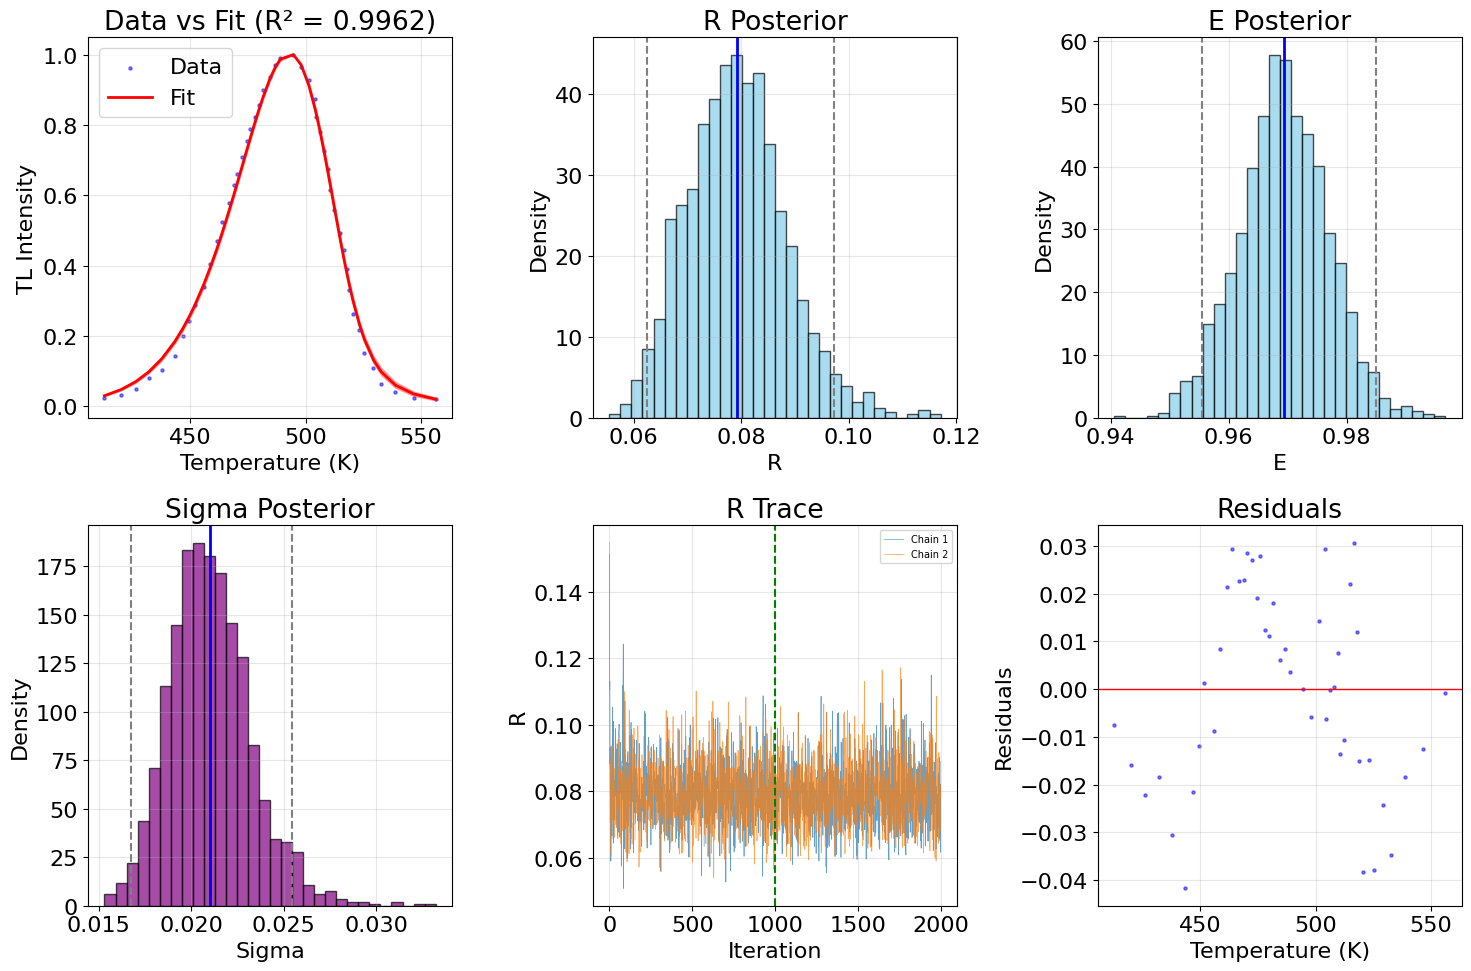

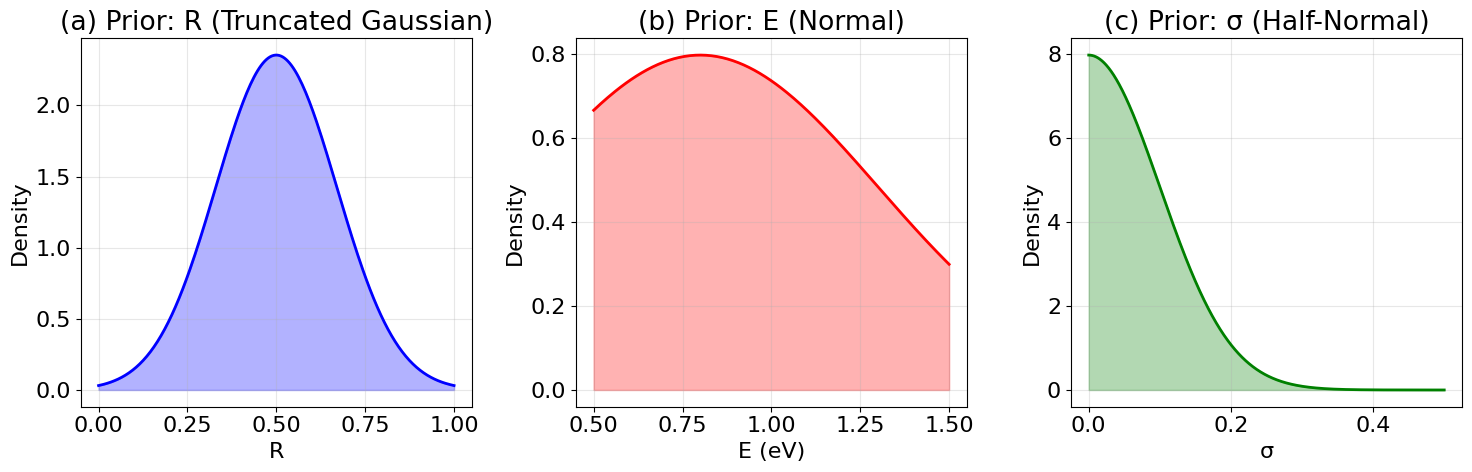


FINAL ESTIMATES
R: 0.0792 ± 0.0092  [95% HPD: 0.0625, 0.0972]
E: 0.9694 ± 0.0075  [95% HPD: 0.9555, 0.9850]
sigma: 0.0210 ± 0.0022  [95% HPD: 0.0168, 0.0254]

✓ Results saved to 'slice_results.csv'


In [ ]:
# %reset -f

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
import pandas as pd

plt.rcParams["font.size"] = 16
np.random.seed(142)

# =============================================================================
# DATA LOADING AND SETUP
# =============================================================================

def readData():
    """Read TL data from GitHub."""
    url = 'https://github.com/vpagonis/Python-Codes/raw/main/Ch3PagonisGitHub/aluminaTLshort.TXT'
    df = pd.read_table(url)

    x_data = df.iloc[:, 0].to_numpy() + 273.15  # Convert to Kelvin
    y_data = df.iloc[:, 1].to_numpy()

    # Normalize
    y_data = y_data / np.max(y_data)
    Tmax = x_data[np.argmax(y_data)]

    return x_data, y_data, Tmax

# Load data
x_data, y_data, Tmax_data = readData()
kB = 8.617E-5

# Fixed parameters
FIXED_Imax = 1.0
FIXED_Tmax = Tmax_data

# Preliminary estimates
LS_estimates = {'R': 0.15, 'E': 1.0, 'sigma': 0.01}
LS_uncertainties = {'R': 0.03, 'E': 0.05, 'sigma': 0.001}

print("="*60)
print("SLICE SAMPLING FOR SINGLE PEAK TL DECONVOLUTION")
print("="*60)
print(f"\nFixed parameters: Imax={FIXED_Imax:.2f}, Tmax={FIXED_Tmax:.2f} K")

# =============================================================================
# VECTORIZED TL GLOW CURVE FUNCTIONS
# =============================================================================

# Pre-compute constants
T = x_data
T2 = T**2
Tmax = FIXED_Tmax
Tmax2 = Tmax**2
eps = 1e-6

def tl_peak_intensity(R, E):
    """
    Vectorized TL intensity calculation.
    """
    # Common terms
    exp_arg = -E/(kB*T + eps)
    exp_val = np.exp(exp_arg)

    F_val = kB * T2 * exp_val * (1 - 2*kB*T/(E + eps)) / (E + eps)

    exp_arg_m = -E/(kB*Tmax + eps)
    exp_val_m = np.exp(exp_arg_m)
    Fm = kB * Tmax2 * exp_val_m * (1 - 2*kB*Tmax/(E + eps)) / (E + eps)

    a = kB * Tmax2 * (1 - 1.05 * R**1.26) + eps
    term1 = R/(1-R + eps) - np.log((1-R)/(R + eps) + eps)
    exp_term = np.exp(E/(kB*Tmax + eps))

    Z = term1 + (F_val * E * exp_term) / a
    Zm = term1 + (Fm * E * exp_term) / a

    Z = np.clip(Z, -500, 500)
    Zm = np.clip(Zm, -500, 500)

    argW = np.log1p(np.exp(Z))
    argWm = np.log1p(np.exp(Zm))

    denominator = argW + argW**2 + eps
    result = FIXED_Imax * np.exp(-E/(kB*T + eps) * (Tmax - T)/Tmax) * (argWm + argWm**2) / denominator

    return np.where(np.isfinite(result), np.maximum(result, 0), 0)

def tl_glow_curve(params):
    """Wrapper for single parameter set."""
    return tl_peak_intensity(params[0], params[1])

# =============================================================================
# PRIOR DISTRIBUTIONS - USING SAME PRIORS AS CODE #2
# =============================================================================

def log_prior(params):
    """
    Log prior using the same priors as in code #2.
    - E: Normal(0.8, 0.5²) truncated to [0.7, 1.3]
    - R (replacing s): Truncated Gaussian on (0,1) with mean=0.5, std=0.17
    - sigma: Half-normal prior (scale=0.1)
    """
    R, E, sigma = params

    # Parameter constraints (physical) - matching code #2 ranges
    if R <= 0 or R >= 1:
        return -np.inf
    if E <= 0.7 or E > 1.3:  # Same as code #2
        return -np.inf
    if sigma <= 0 or sigma > 1:  # Same as code #2
        return -np.inf

    # Prior for E: Normal(0.8, 0.5²) - same as code #2
    log_prior_E = -0.5 * ((E - 0.8) / 0.5) ** 2

    # Prior for R: Truncated Gaussian on (0,1) with mean=0.5, std=0.17
    # This matches the prior used for R1/R2 in code #2
    mean_R = 0.5
    std_R = 0.17
    # Calculate normalization factor for truncation
    cdf_lower = stats.norm.cdf(0, mean_R, std_R)
    cdf_upper = stats.norm.cdf(1, mean_R, std_R)
    norm_factor = cdf_upper - cdf_lower
    log_prior_R = stats.norm.logpdf(R, mean_R, std_R) - np.log(norm_factor)

    # Prior for sigma: Half-normal prior with scale=0.1 - same as code #2
    log_prior_sigma = -0.5 * (sigma / 0.1) ** 2

    return log_prior_R + log_prior_E + log_prior_sigma

def log_likelihood(params):
    """Log likelihood."""
    mu = tl_peak_intensity(params[0], params[1])
    return np.sum(stats.norm.logpdf(y_data, mu, params[2]))

def log_posterior(params):
    """Log posterior."""
    lp = log_prior(params)
    return -np.inf if not np.isfinite(lp) else lp + log_likelihood(params)

# =============================================================================
# SIMPLIFIED SLICE SAMPLING
# =============================================================================

def slice_sample_1d(current, log_target, idx, bounds, w=0.1, m=100):
    """
    Simplified univariate slice sampling.
    """
    lower, upper = bounds

    def target_at_x(x):
        params = current.copy()
        params[idx] = x
        return log_target(params)

    # Slice level
    log_y = target_at_x(current[idx]) - np.random.exponential(1)

    # Stepping out
    L = current[idx] - w * np.random.random()
    R = L + w

    # Expand interval
    for _ in range(m):
        if L <= lower or target_at_x(L) <= log_y:
            break
        L -= w
    for _ in range(m):
        if R >= upper or target_at_x(R) <= log_y:
            break
        R += w

    L = max(L, lower)
    R = min(R, upper)

    # Sample with shrinkage
    while True:
        x_new = L + np.random.random() * (R - L)
        if target_at_x(x_new) > log_y:
            return x_new
        if x_new < current[idx]:
            L = x_new
        else:
            R = x_new

def slice_sampler(initial, n_iterations=1000, n_chains=2, w=[0.05, 0.02, 0.01]):
    """
    Simplified slice sampler.
    """
    param_names = ['R', 'E', 'sigma']
    # Updated bounds to match code #2 constraints
    bounds = [(0, 1), (0.7, 1.3), (0, 1)]

    samples = np.zeros((n_chains, n_iterations, 3))

    print(f"\nRunning {n_chains} chains with {n_iterations} iterations...")
    print("Using priors: E~Normal(0.8,0.5²), R~Truncated Gaussian(0.5,0.17²), sigma~HalfNormal(0.1)")

    for chain in range(n_chains):
        # Initialize
        current = np.array([
            np.clip(initial['R'] + np.random.normal(0, 0.01), 0.01, 0.99),
            np.clip(initial['E'] + np.random.normal(0, 0.02), 0.7, 1.3),
            max(0.001, initial['sigma'] + np.random.normal(0, 0.005))
        ])

        for i in range(n_iterations):
            samples[chain, i] = current

            # Update each parameter
            for j in range(3):
                current[j] = slice_sample_1d(current, log_posterior, j, bounds[j], w[j])

        print(f"  Chain {chain+1} completed")

    return samples, param_names

# =============================================================================
# FAST DIAGNOSTICS
# =============================================================================

def gelman_rubin(samples):
    """Fast Gelman-Rubin."""
    n_chains, n_samples, n_params = samples.shape

    chain_means = np.mean(samples, axis=1)
    chain_vars = np.var(samples, axis=1, ddof=1)

    W = np.mean(chain_vars, axis=0)
    B = n_samples * np.var(chain_means, axis=0, ddof=1)

    var_plus = (n_samples - 1) / n_samples * W + B / n_samples
    return np.sqrt(var_plus / W)

def effective_sample_size(x):
    """Fast ESS."""
    n = len(x)
    x_centered = x - np.mean(x)
    acf = np.correlate(x_centered, x_centered, mode='full') / np.var(x)
    acf = acf[n-1:n+100] / (n - np.arange(min(101, n)))

    cutoff = np.where(acf[1:] <= 0)[0]
    cutoff = cutoff[0] + 1 if len(cutoff) > 0 else len(acf)

    return n / (1 + 2 * np.sum(acf[1:cutoff]))

def hpd_interval(x, prob=0.95):
    """Fast HPD."""
    n = len(x)
    x_sort = np.sort(x)
    m = int(round(n * prob))
    intervals = x_sort[m-1:] - x_sort[:n-m+1]
    start = np.argmin(intervals)
    return np.array([x_sort[start], x_sort[start + m - 1]])

# =============================================================================
# RUN SAMPLER
# =============================================================================

n_iterations, n_burnin, n_chains = 2000, 1000, 2

print("\n" + "="*60)
print("RUNNING SLICE SAMPLER")
print("="*60)

samples, param_names = slice_sampler(LS_estimates, n_iterations, n_chains)

# Process samples
samples_after_burnin = samples[:, n_burnin:, :]
samples_flat = samples_after_burnin.reshape(-1, 3)

# Statistics
means = np.mean(samples_flat, axis=0)
stds = np.std(samples_flat, axis=0)
hpd_lower = np.array([hpd_interval(samples_flat[:, i])[0] for i in range(3)])
hpd_upper = np.array([hpd_interval(samples_flat[:, i])[1] for i in range(3)])

# Print summary
print("\n" + "="*80)
print("PARAMETER SUMMARY")
print("="*80)
print(f"{'Param':<6} {'Mean':<8} {'Std':<8} {'HPD Lower':<10} {'HPD Upper':<10}")
print("-"*50)
for i, name in enumerate(param_names):
    print(f"{name:<6} {means[i]:<8.4f} {stds[i]:<8.4f} {hpd_lower[i]:<10.4f} {hpd_upper[i]:<10.4f}")

# R-hat
r_hat = gelman_rubin(samples_after_burnin)
print("\nR-hat:", {name: f"{r_hat[i]:.4f}" for i, name in enumerate(param_names)})

# =============================================================================
# FIT STATISTICS (VECTORIZED)
# =============================================================================

print("\nCalculating fit statistics...")
n_fit = min(500, len(samples_flat))
idx = np.random.choice(len(samples_flat), n_fit, replace=False)

# Vectorized fit calculation
mu_samples = np.array([tl_peak_intensity(samples_flat[i, 0], samples_flat[i, 1])
                       for i in idx])

mu_mean = np.mean(mu_samples, axis=0)
mu_hpd_lower = np.percentile(mu_samples, 2.5, axis=0)
mu_hpd_upper = np.percentile(mu_samples, 97.5, axis=0)

# Statistics
residuals = y_data - mu_mean
ss_res, ss_tot = np.sum(residuals**2), np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - ss_res/ss_tot
rmse = np.sqrt(np.mean(residuals**2))
fom = np.sum(np.abs(residuals)) / np.sum(mu_mean) * 100

print(f"R² = {r_squared:.4f}, RMSE = {rmse:.4f}, FOM = {fom:.2f}%")

# =============================================================================
# SIMPLIFIED PLOTTING
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Data vs Fit
ax = axes[0, 0]
ax.scatter(x_data, y_data, s=5, alpha=0.5, color='blue', label='Data')
ax.plot(x_data, mu_mean, 'r-', linewidth=2, label='Fit')
ax.fill_between(x_data, mu_hpd_lower, mu_hpd_upper, alpha=0.3, color='red')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('TL Intensity')
ax.set_title(f'Data vs Fit (R² = {r_squared:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)

# Posterior distributions
for i, (ax, name, color) in enumerate(zip(axes[0, 1:], ['R', 'E'], ['skyblue', 'skyblue'])):
    ax.hist(samples_flat[:, i], bins=30, density=True, alpha=0.7, color=color, edgecolor='black')
    ax.axvline(means[i], color='blue', linewidth=2)
    ax.axvline(hpd_lower[i], color='gray', linestyle='--')
    ax.axvline(hpd_upper[i], color='gray', linestyle='--')
    ax.set_xlabel(name)
    ax.set_ylabel('Density')
    ax.set_title(f'{name} Posterior')
    ax.grid(True, alpha=0.3)

# Sigma posterior
ax = axes[1, 0]
ax.hist(samples_flat[:, 2], bins=30, density=True, alpha=0.7, color='purple', edgecolor='black')
ax.axvline(means[2], color='blue', linewidth=2)
ax.axvline(hpd_lower[2], color='gray', linestyle='--')
ax.axvline(hpd_upper[2], color='gray', linestyle='--')
ax.set_xlabel('Sigma')
ax.set_ylabel('Density')
ax.set_title('Sigma Posterior')
ax.grid(True, alpha=0.3)

# Trace plots
ax = axes[1, 1]
for chain in range(n_chains):
    ax.plot(samples[chain, :, 0], alpha=0.7, linewidth=0.5, label=f'Chain {chain+1}')
ax.axvline(n_burnin, color='green', linestyle='--')
ax.set_xlabel('Iteration')
ax.set_ylabel('R')
ax.set_title('R Trace')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Residuals
ax = axes[1, 2]
ax.scatter(x_data, residuals, s=5, alpha=0.5, color='blue')
ax.axhline(0, color='red', linewidth=1)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Residuals')
ax.set_title('Residuals')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# PRIOR VS POSTERIOR COMPARISON PLOT
# =============================================================================

fig_prior, axes = plt.subplots(1, 3, figsize=(15, 5))

# Prior for R: Truncated Gaussian (0.5, 0.17²)
ax1 = axes[0]
x_r = np.linspace(0, 1, 200)
mean_R = 0.5
std_R = 0.17
cdf_lower = stats.norm.cdf(0, mean_R, std_R)
cdf_upper = stats.norm.cdf(1, mean_R, std_R)
norm_factor = cdf_upper - cdf_lower
prior_r = stats.norm.pdf(x_r, mean_R, std_R) / norm_factor
ax1.plot(x_r, prior_r, 'b-', linewidth=2, label='Prior')
ax1.fill_between(x_r, 0, prior_r, alpha=0.3, color='blue')
ax1.set_xlabel('R')
ax1.set_ylabel('Density')
ax1.set_title('(a) Prior: R (Truncated Gaussian)')
ax1.grid(True, alpha=0.3)

# Prior for E: Normal(0.8, 0.5²)
ax2 = axes[1]
x_e = np.linspace(0.5, 1.5, 200)
prior_e = (1/(0.5*np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x_e - 0.8)/0.5)**2)
ax2.plot(x_e, prior_e, 'r-', linewidth=2, label='Prior')
ax2.fill_between(x_e, 0, prior_e, alpha=0.3, color='red')
ax2.set_xlabel('E (eV)')
ax2.set_ylabel('Density')
ax2.set_title('(b) Prior: E (Normal)')
ax2.grid(True, alpha=0.3)

# Prior for sigma: Half-normal (scale=0.1)
ax3 = axes[2]
sigma_range = np.linspace(0, 0.5, 1000)
prior_sigma = (2/(0.1*np.sqrt(2*np.pi))) * np.exp(-0.5 * (sigma_range/0.1)**2)
ax3.plot(sigma_range, prior_sigma, 'g-', linewidth=2, label='Prior')
ax3.fill_between(sigma_range, 0, prior_sigma, alpha=0.3, color='green')
ax3.set_xlabel('σ')
ax3.set_ylabel('Density')
ax3.set_title('(c) Prior: σ (Half-Normal)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final summary
print("\n" + "="*60)
print("FINAL ESTIMATES")
print("="*60)
for i, name in enumerate(param_names):
    print(f"{name}: {means[i]:.4f} ± {stds[i]:.4f}  [95% HPD: {hpd_lower[i]:.4f}, {hpd_upper[i]:.4f}]")

# Save results
pd.DataFrame({
    'Parameter': param_names, 'Mean': means, 'Std': stds,
    'HDI_2.5%': hpd_lower, 'HDI_97.5%': hpd_upper, 'R_hat': r_hat
}).to_csv('slice_results.csv', index=False)
print("\n✓ Results saved to 'slice_results.csv'")


# Code 6
Slice algorithm, double peak synthetic TL data.

---------------------------- CODE OUTPUT -----------------------------
Data points: 200
Peak 1: E1=1.0 eV, s1=1.0e+12 s^-1
Peak 2: E2=1.2 eV, s2=1.0e+13 s^-1

Starting Slice Sampling...
Using two-peak first-order kinetics (Randall-Wilkins equation)
Parameters: E1 (activation energy, eV), s1 (frequency factor, s^-1),
            E2 (activation energy, eV), s2 (frequency factor, s^-1), sigma (noise)
Running Slice Sampling for 2000 steps...
Parameters: E1 (eV), log10(s1), E2 (eV), log10(s2), sigma
Using 4 chains

Chain 1/4
  Chain 1 completed

Chain 2/4
  Chain 2 completed

Chain 3/4
  Chain 3 completed

Chain 4/4
  Chain 4 completed

SLICE SAMPLING RESULTS - TWO-PEAK FIRST-ORDER KINETICS

Peak 1:
  E1 (activation energy) = 1.0240 ± 0.0060 eV
    95% CI: [1.0117, 1.0339] eV
  s1 (frequency factor) = 2.13e+12 s^-1
    95% CI: [1.43e+12, 2.83e+12] s^-1
  log10(s1) = 12.33 ± 0.08

Peak 2:
  E2 (activation energy) = 1.1871 ± 0.0097 eV
    95% CI: [1.1580, 1.1996] eV
  s2 (frequency factor) = 

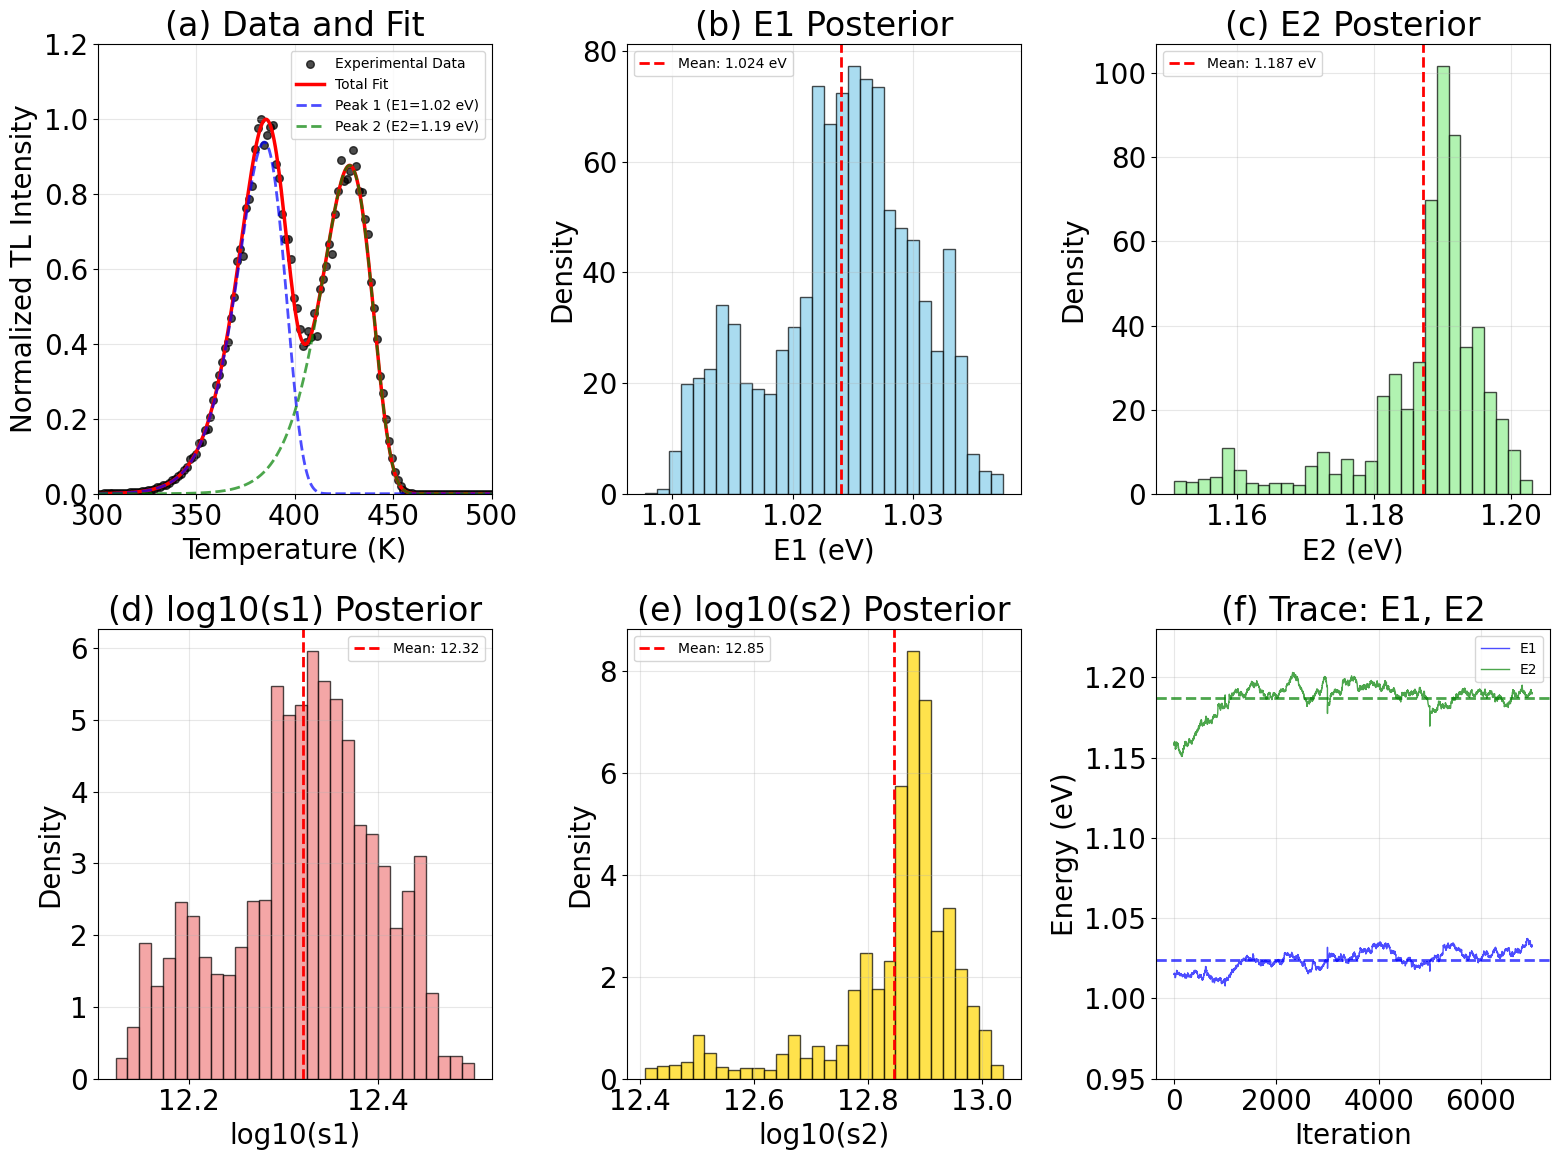


PARAMETER CORRELATIONS
Correlation between E1 and E2: 0.565
Correlation between E1 and log10(s1): 0.999
Correlation between E2 and log10(s2): 0.999

PHYSICAL INTERPRETATION
Peak 1: E = 1.024 ± 0.006 eV, s = 2.13e+12 s^-1
Peak 2: E = 1.187 ± 0.010 eV, s = 7.24e+12 s^-1

The two peaks correspond to different trapping centers in the material.
Peak 1 (lower temperature) has lower activation energy (1.024 eV)
Peak 2 (higher temperature) has higher activation energy (1.187 eV)


In [ ]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
print('-'*28,'CODE OUTPUT','-'*29)
rng = np.random.default_rng(seed=122)

# Simulate data from two first-order kinetics peaks
kB = 8.617E-5  # Boltzmann constant (eV/K)

def first_order_kinetics_unnormalized(T, E, s, beta=1.0):
    """
    First-order kinetics TL glow curve (Randall-Wilkins model) - UNNORMALIZED.
    Returns absolute intensity values.
    """
    kB = 8.617E-5  # Boltzmann constant (eV/K)
    eps = 1e-10    # Small number to avoid division by zero

    # Convert to numpy array if needed
    T = np.asarray(T)

    # Calculate the thermal integral approximation
    kT = kB * T
    E_over_kT = E / kT

    # Thermal integral approximation
    thermal_int = (kB * T**2 / E) * np.exp(-E_over_kT) * (1 - 2*kB*T/E + eps)

    # First-order kinetics (Randall-Wilkins equation) - return absolute intensity
    I_T = s * np.exp(-E_over_kT) * np.exp(-(s/beta) * thermal_int)

    return I_T

# Generate temperature range
x_data = np.linspace(300, 600, 200)  # Extended range to 600K for second peak

# Define parameters for two peaks
E1_true = 1.0  # eV
s1_true = 1e12  # s^-1
E2_true = 1.2  # eV
s2_true = 1e13  # s^-1

# Generate ideal data for both peaks (unnormalized)
y1_ideal = first_order_kinetics_unnormalized(x_data, E1_true, s1_true)
y2_ideal = first_order_kinetics_unnormalized(x_data, E2_true, s2_true)

# Combine peaks (sum of both)
y_ideal = y1_ideal + y2_ideal

# Normalize to maximum = 1
y_ideal = y_ideal / np.max(y_ideal)

# Add 5% multiplicative noise
np.random.seed(42)
noise = np.random.normal(0, 0.05, size=len(y_ideal))
y_data_noisy = y_ideal * (1 + noise)

# Ensure no negative values
y_data_noisy = np.maximum(y_data_noisy, 0)

# Re-normalize after adding noise
y_data = y_data_noisy / np.max(y_data_noisy)

print(f"Data points: {len(x_data)}")
print(f"Peak 1: E1={E1_true} eV, s1={s1_true:.1e} s^-1")
print(f"Peak 2: E2={E2_true} eV, s2={s2_true:.1e} s^-1")

# Modified two_peak_kinetics function without internal normalization
def two_peak_kinetics_unnormalized(T, E1, s1, E2, s2, beta=1.0):
    """
    Two-peak first-order kinetics TL glow curve - UNNORMALIZED.
    Returns absolute combined intensity.
    """
    # Calculate individual peaks (unnormalized)
    I1 = first_order_kinetics_unnormalized(T, E1, s1, beta)
    I2 = first_order_kinetics_unnormalized(T, E2, s2, beta)

    # Combine (no normalization)
    I_total = I1 + I2

    return I_total

def log_prior(E1, s1, E2, s2, sigma):
    """
    Log prior for all parameters.
    Uses weakly informative priors.
    """
    # Parameter constraints (physical)
    if E1 <= 0.7 or E1 > 2:
        return -np.inf
    if s1 <= 1e7 or s1 > 1e13:
        return -np.inf
    if E2 <= 0.7 or E2 > 2:
        return -np.inf
    if s2 <= 1e7 or s2 > 1e15:
        return -np.inf
    if sigma <= 0 or sigma > 1:
        return -np.inf

    # Weakly informative priors
    log_prior_E1 = -0.5 * ((E1 - 0.8) / 0.5) ** 2
    log_prior_E2 = -0.5 * ((E2 - 0.8) / 0.5) ** 2

    # Log-normal priors for frequency factors
    log10_s1 = np.log10(s1)
    log10_s2 = np.log10(s2)
    log_prior_s1 = -0.5 * ((log10_s1 - 10) / 2) ** 2
    log_prior_s2 = -0.5 * ((log10_s2 - 10) / 2) ** 2

    # sigma: Half-normal prior
    log_prior_sigma = -0.5 * (sigma / 0.1) ** 2

    return log_prior_E1 + log_prior_s1 + log_prior_E2 + log_prior_s2 + log_prior_sigma

def log_likelihood(y, y_pred, sigma):
    """Log likelihood assuming Gaussian errors"""
    n = len(y)
    return -0.5 * np.sum(((y - y_pred) / sigma) ** 2) - n * np.log(sigma)

def log_posterior(params, x, y):
    """Log posterior probability"""
    E1, s1, E2, s2, sigma = params
    y_pred = two_peak_kinetics_unnormalized(x, E1, s1, E2, s2)

    # Normalize prediction to match data (data is normalized to max=1)
    if np.max(y_pred) > 1e-10:
        y_pred = y_pred / np.max(y_pred)

    lp = log_prior(E1, s1, E2, s2, sigma)

    # Check if log_prior is finite
    if not np.isfinite(lp):
        return -np.inf

    # Check for NaN in predictions
    if np.any(np.isnan(y_pred)) or np.any(np.isinf(y_pred)):
        return -np.inf

    return lp + log_likelihood(y, y_pred, sigma)

# =============================================================================
# SLICE SAMPLING IMPLEMENTATION
# =============================================================================

def slice_sample_1d(current, log_target, idx, bounds, w=0.1, m=100):
    """
    Univariate slice sampling for a single parameter.

    Parameters:
    current: current parameter array
    log_target: function to compute log posterior
    idx: index of parameter to update
    bounds: (lower, upper) bounds for the parameter
    w: initial step size for stepping out
    m: maximum number of steps for stepping out
    """
    lower, upper = bounds

    def target_at_x(x):
        params = current.copy()
        params[idx] = x
        return log_target(params)

    # Slice level
    log_y = target_at_x(current[idx]) - np.random.exponential(1)

    # Stepping out to find interval
    L = current[idx] - w * np.random.random()
    R = L + w

    # Expand interval left
    for _ in range(m):
        if L <= lower or target_at_x(L) <= log_y:
            break
        L -= w

    # Expand interval right
    for _ in range(m):
        if R >= upper or target_at_x(R) <= log_y:
            break
        R += w

    L = max(L, lower)
    R = min(R, upper)

    # Sample with shrinkage
    while True:
        x_new = L + np.random.random() * (R - L)
        if target_at_x(x_new) > log_y:
            return x_new
        if x_new < current[idx]:
            L = x_new
        else:
            R = x_new

def slice_sampler(x, y, n_steps, burn_in, n_chains=2):
    """
    Slice sampling algorithm for two-peak first-order kinetics.
    Parameters: E1, log10(s1), E2, log10(s2), sigma
    """

    # Parameter names and bounds
    param_names = ['E1', 'log10_s1', 'E2', 'log10_s2', 'sigma']
    # Bounds for each parameter: (lower, upper)
    bounds = [
        (0.7, 2.0),    # E1
        (7, 13),       # log10(s1)
        (0.7, 2.0),    # E2
        (7, 15),       # log10(s2)
        (0.01, 1.0)    # sigma
    ]

    # Initial step sizes for each parameter
    w = [0.02, 0.1, 0.02, 0.1, 0.01]

    # Starting parameters (initial guesses)
    current = np.array([0.95, 11.0, 1.15, 10.5, 0.05])

    # Wrap log_posterior for slice sampling
    def log_target(params):
        E1 = params[0]
        log10_s1 = params[1]
        s1 = 10 ** log10_s1
        E2 = params[2]
        log10_s2 = params[3]
        s2 = 10 ** log10_s2
        sigma = params[4]
        return log_posterior([E1, s1, E2, s2, sigma], x, y)

    samples = []

    print(f"Running Slice Sampling for {n_steps} steps...")
    print(f"Parameters: E1 (eV), log10(s1), E2 (eV), log10(s2), sigma")
    print(f"Using {n_chains} chains")

    for chain in range(n_chains):
        print(f"\nChain {chain+1}/{n_chains}")

        # Slightly perturb initial values for different chains
        if chain > 0:
            current = current + np.random.normal(0, 0.01, size=len(current))
            # Ensure bounds
            for i, (lower, upper) in enumerate(bounds):
                current[i] = np.clip(current[i], lower, upper)

        chain_samples = []

        for i in range(n_steps):
            chain_samples.append(current.copy())

            # Update each parameter using slice sampling
            for j in range(len(param_names)):
                current[j] = slice_sample_1d(current, log_target, j, bounds[j], w[j])

            # Progress indicator
            if (i + 1) % 30000 == 0:
                print(f"  Step {i+1}/{n_steps}")

        samples.append(chain_samples)
        print(f"  Chain {chain+1} completed")

    # Convert to numpy array
    samples_array = np.array(samples)

    # Reshape to (n_chains * n_steps, n_params) for burn-in removal
    samples_reshaped = samples_array.reshape(-1, len(param_names))

    # Discard burn-in
    samples_after_burnin = samples_reshaped[burn_in:, :]

    # Convert log10(s) back to s for storage
    samples_with_s = []
    for sample in samples_after_burnin:
        samples_with_s.append([sample[0], 10**sample[1], sample[2], 10**sample[3], sample[4]])

    samples_final = np.array(samples_with_s)

    return samples_final, samples_after_burnin

# =============================================================================
# RUN SLICE SAMPLING
# =============================================================================

print("\nStarting Slice Sampling...")
print("Using two-peak first-order kinetics (Randall-Wilkins equation)")
print("Parameters: E1 (activation energy, eV), s1 (frequency factor, s^-1),")
print("            E2 (activation energy, eV), s2 (frequency factor, s^-1), sigma (noise)")

n_steps = 2000
burn_in = 1000

samples, samples_log = slice_sampler(x_data, y_data, n_steps, burn_in, n_chains=4)

# Extract parameter samples
E1_samples = samples[:, 0]
s1_samples = samples[:, 1]
E2_samples = samples[:, 2]
s2_samples = samples[:, 3]
sigma_samples = samples[:, 4]

# Get posterior statistics
E1_est, E1_std = np.mean(E1_samples), np.std(E1_samples)
s1_est = np.mean(s1_samples)
E2_est, E2_std = np.mean(E2_samples), np.std(E2_samples)
s2_est = np.mean(s2_samples)
sigma_est = np.mean(sigma_samples)

E1_ci = np.percentile(E1_samples, [2.5, 97.5])
s1_ci = np.percentile(s1_samples, [2.5, 97.5])
E2_ci = np.percentile(E2_samples, [2.5, 97.5])
s2_ci = np.percentile(s2_samples, [2.5, 97.5])

print("\n" + "="*60)
print("SLICE SAMPLING RESULTS - TWO-PEAK FIRST-ORDER KINETICS")
print("="*60)
print(f"\nPeak 1:")
print(f"  E1 (activation energy) = {E1_est:.4f} ± {E1_std:.4f} eV")
print(f"    95% CI: [{E1_ci[0]:.4f}, {E1_ci[1]:.4f}] eV")
print(f"  s1 (frequency factor) = {s1_est:.2e} s^-1")
print(f"    95% CI: [{s1_ci[0]:.2e}, {s1_ci[1]:.2e}] s^-1")
print(f"  log10(s1) = {np.log10(s1_est):.2f} ± {np.std(np.log10(s1_samples)):.2f}")

print(f"\nPeak 2:")
print(f"  E2 (activation energy) = {E2_est:.4f} ± {E2_std:.4f} eV")
print(f"    95% CI: [{E2_ci[0]:.4f}, {E2_ci[1]:.4f}] eV")
print(f"  s2 (frequency factor) = {s2_est:.2e} s^-1")
print(f"    95% CI: [{s2_ci[0]:.2e}, {s2_ci[1]:.2e}] s^-1")
print(f"  log10(s2) = {np.log10(s2_est):.2f} ± {np.std(np.log10(s2_samples)):.2f}")

print(f"\nNoise parameter:")
print(f"  sigma = {sigma_est:.4f}")
print(f"    95% CI: [{np.percentile(sigma_samples, 2.5):.4f}, {np.percentile(sigma_samples, 97.5):.4f}]")

# Calculate fit quality metrics
def calculate_metrics(y_true, y_pred):
    residuals = y_true - y_pred
    r_squared = 1 - np.sum(residuals**2) / np.sum((y_true - np.mean(y_true))**2)
    rmse = np.sqrt(np.mean(residuals**2))
    return r_squared, rmse

# Predictions with estimated parameters
y_pred_unnorm = two_peak_kinetics_unnormalized(x_data, E1_est, s1_est, E2_est, s2_est)
y_pred_mh = y_pred_unnorm / np.max(y_pred_unnorm)  # Normalize for comparison
r2_mh, rmse_mh = calculate_metrics(y_data, y_pred_mh)

print("\nFIT QUALITY METRICS:")
print(f"  R² = {r2_mh:.4f}")
print(f"  RMSE = {rmse_mh:.4f}")

# Create comprehensive plots (2x3 layout)
plt.rcParams["font.size"] = 20
fig = plt.figure(figsize=(16, 12))

# Plot 1: Data and fitted model
ax1 = plt.subplot(2, 3, 1)
ax1.scatter(x_data, y_data, alpha=0.7, label='Experimental Data', color='black', s=30)
x_fine = np.linspace(min(x_data), max(x_data), 500)

# Calculate unnormalized curves for plotting
y1_unnorm = first_order_kinetics_unnormalized(x_fine, E1_est, s1_est)
y2_unnorm = first_order_kinetics_unnormalized(x_fine, E2_est, s2_est)
y_total_unnorm = y1_unnorm + y2_unnorm

# Normalize total to 1 for plotting
norm_factor = np.max(y_total_unnorm)
y_total_norm = y_total_unnorm / norm_factor
y1_norm = y1_unnorm / norm_factor
y2_norm = y2_unnorm / norm_factor

# Plot
ax1.plot(x_fine, y_total_norm, 'r-', linewidth=2.5, label='Total Fit')
ax1.plot(x_fine, y1_norm, 'b--', linewidth=2, alpha=0.7,
         label=f'Peak 1 (E1={E1_est:.2f} eV)')
ax1.plot(x_fine, y2_norm, 'g--', linewidth=2, alpha=0.7,
         label=f'Peak 2 (E2={E2_est:.2f} eV)')

# Print actual heights
print(f"\nPeak heights in total fit:")
print(f"  Peak 1 height: {np.max(y1_norm):.3f}")
print(f"  Peak 2 height: {np.max(y2_norm):.3f}")

ax1.set_xlabel('Temperature (K)')
ax1.set_ylabel('Normalized TL Intensity')
ax1.set_ylim(0, 1.2)
ax1.set_xlim(300,500)
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_title('(a) Data and Fit')

# Plot 2: Posterior distribution for E1
ax2 = plt.subplot(2, 3, 2)
ax2.hist(E1_samples, bins=30, alpha=0.7, density=True, edgecolor='black', color='skyblue')
ax2.axvline(E1_est, color='red', linestyle='--', linewidth=2, label=f'Mean: {E1_est:.3f} eV')
ax2.set_xlabel('E1 (eV)')
ax2.set_ylabel('Density')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_title('(b) E1 Posterior')

# Plot 3: Posterior distribution for E2
ax3 = plt.subplot(2, 3, 3)
ax3.hist(E2_samples, bins=30, alpha=0.7, density=True, edgecolor='black', color='lightgreen')
ax3.axvline(E2_est, color='red', linestyle='--', linewidth=2, label=f'Mean: {E2_est:.3f} eV')
ax3.set_xlabel('E2 (eV)')
ax3.set_ylabel('Density')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_title('(c) E2 Posterior')

# Plot 4: Posterior distribution for log10(s1)
ax4 = plt.subplot(2, 3, 4)
log10_s1_samples = np.log10(s1_samples)
ax4.hist(log10_s1_samples, bins=30, alpha=0.7, density=True, edgecolor='black', color='lightcoral')
ax4.axvline(np.mean(log10_s1_samples), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(log10_s1_samples):.2f}')
ax4.set_xlabel('log10(s1)')
ax4.set_ylabel('Density')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_title('(d) log10(s1) Posterior')

# Plot 5: Posterior distribution for log10(s2)
ax5 = plt.subplot(2, 3, 5)
log10_s2_samples = np.log10(s2_samples)
ax5.hist(log10_s2_samples, bins=30, alpha=0.7, density=True, edgecolor='black', color='gold')
ax5.axvline(np.mean(log10_s2_samples), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(log10_s2_samples):.2f}')
ax5.set_xlabel('log10(s2)')
ax5.set_ylabel('Density')
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)
ax5.set_title('(e) log10(s2) Posterior')

# Plot 6: Combined trace plot for E1 and E2
ax6 = plt.subplot(2, 3, 6)
ax6.plot(E1_samples, alpha=0.7, linewidth=1, color='blue', label='E1')
ax6.plot(E2_samples, alpha=0.7, linewidth=1, color='green', label='E2')
ax6.axhline(E1_est, color='blue', linestyle='--', linewidth=2, alpha=0.7)
ax6.axhline(E2_est, color='green', linestyle='--', linewidth=2, alpha=0.7)
ax6.set_xlabel('Iteration')
ax6.set_ylabel('Energy (eV)')
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3)
ax6.set_title('(f) Trace: E1, E2')
ax6.set_ylim(0.95, 1.23)

plt.tight_layout()
plt.show()

# Print correlation between parameters
corr_E1_E2 = np.corrcoef(E1_samples, E2_samples)[0, 1]
corr_E1_log10s1 = np.corrcoef(E1_samples, log10_s1_samples)[0, 1]
corr_E2_log10s2 = np.corrcoef(E2_samples, log10_s2_samples)[0, 1]

print("\n" + "="*60)
print("PARAMETER CORRELATIONS")
print("="*60)
print(f"Correlation between E1 and E2: {corr_E1_E2:.3f}")
print(f"Correlation between E1 and log10(s1): {corr_E1_log10s1:.3f}")
print(f"Correlation between E2 and log10(s2): {corr_E2_log10s2:.3f}")

# Physical interpretation
print("\n" + "="*60)
print("PHYSICAL INTERPRETATION")
print("="*60)
print(f"Peak 1: E = {E1_est:.3f} ± {E1_std:.3f} eV, s = {s1_est:.2e} s^-1")
print(f"Peak 2: E = {E2_est:.3f} ± {E2_std:.3f} eV, s = {s2_est:.2e} s^-1")
print("\nThe two peaks correspond to different trapping centers in the material.")
print(f"Peak 1 (lower temperature) has lower activation energy ({E1_est:.3f} eV)")
print(f"Peak 2 (higher temperature) has higher activation energy ({E2_est:.3f} eV)")



# Code 7

Metropolis algorithm using PyMC package, single peak experimental alumina TL data.

PYMC MODEL FOR SINGLE PEAK TL DATA - SLICE SAMPLING

Fixed parameters:
  Imax: 1.00
  Tmax: 494.61 K

PRIOR INFORMATION - NORMAL PRIORS
  R: Truncated Normal(0.5, 0.17²) on (0,1)
  E: Normal(0.8, 0.5²) truncated to [0.7, 1.3]
  sigma: HalfNormal(scale=0.1)

PRIORS USED IN MODEL:
  R: TruncatedNormal(mu=0.5, sigma=0.17, lower=0.001, upper=0.999)
  E: TruncatedNormal(mu=0.8, sigma=0.5, lower=0.7, upper=1.3)
  sigma: HalfNormal(sigma=0.1)

Running MCMC sampling with SLICE sampler...

PARAMETER SUMMARY WITH NORMAL PRIORS - SLICE SAMPLING
            mean        sd  hdi_2.5%  hdi_97.5%     r_hat
E       0.969582  0.007478  0.955152   0.984975  1.000451
R       0.079408  0.009129  0.062195   0.097783  1.000752
mu[0]   0.029599  0.000900  0.027850   0.031438  1.000315
mu[1]   0.047366  0.001269  0.044742   0.049798  1.000502
mu[2]   0.069484  0.001657  0.066306   0.072894  1.000597
mu[3]   0.097304  0.002067  0.093327   0.101515  1.000717
mu[4]   0.134539  0.002518  0.129818   0.139820  1.000

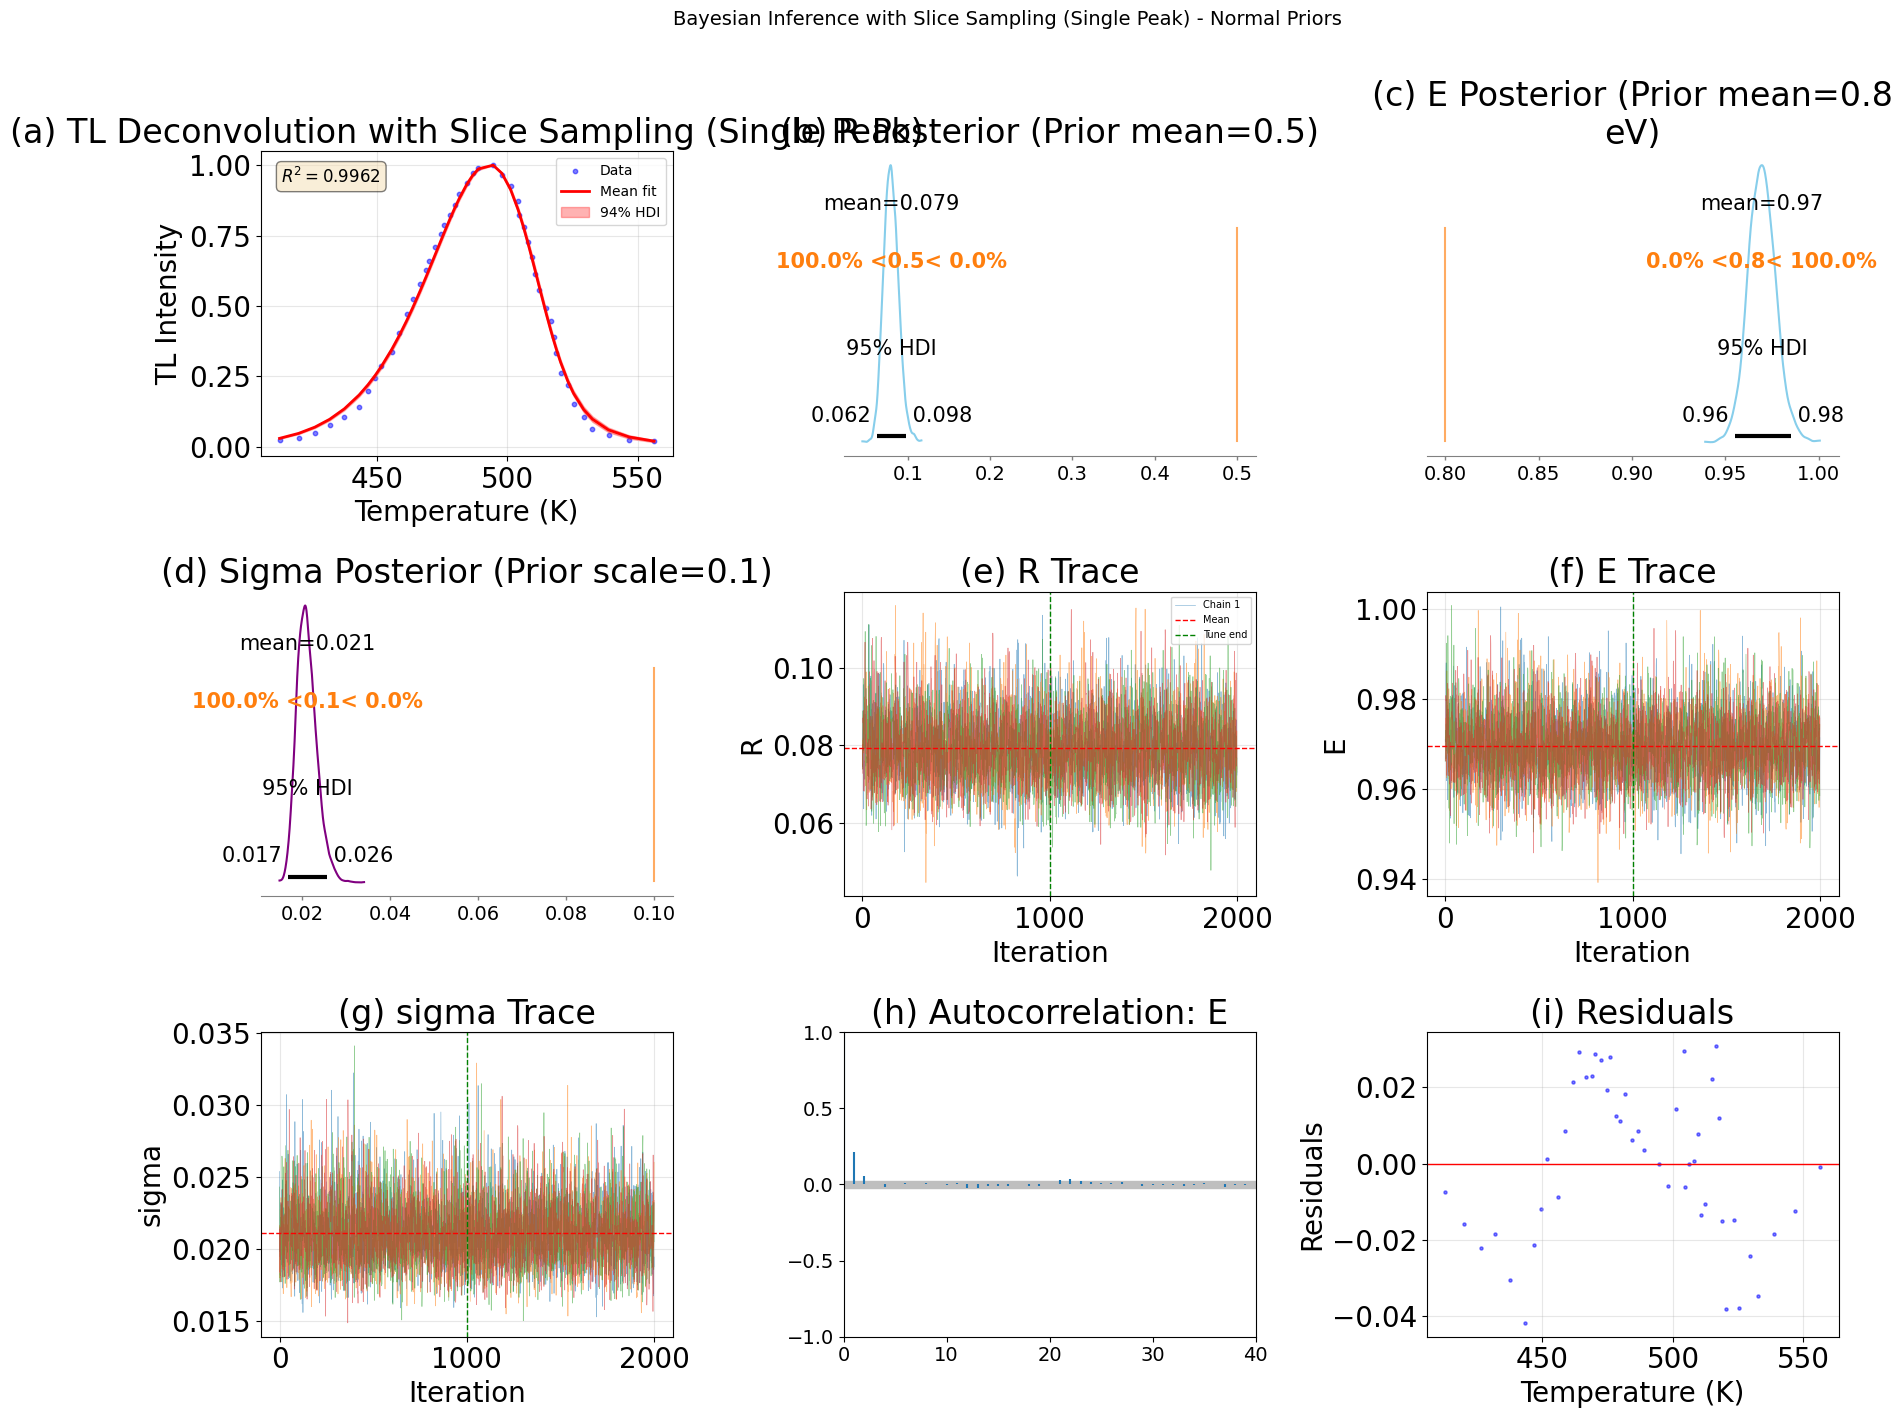

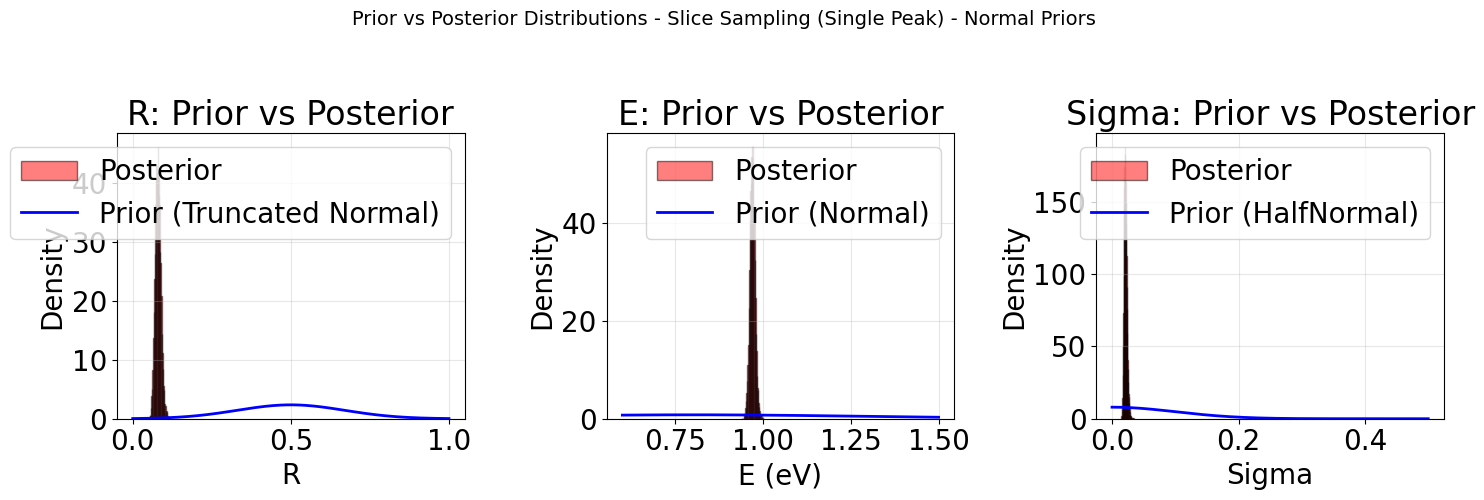


FIT STATISTICS
RMSE: 0.020122
R²: 0.996210
Adjusted R²: 0.996037
FOM: 3.4639%

FINAL PARAMETER ESTIMATES (Slice Sampling - Single Peak) - Normal Priors
R: 0.0794 ± 0.0091  [95% HDI: 0.0622, 0.0978]
E: 0.9696 ± 0.0075  [95% HDI: 0.9552, 0.9850]
sigma: 0.0211 ± 0.0023  [95% HDI: 0.0169, 0.0257]

SLICE SAMPLING EFFICIENCY
R: 655.0 effective samples per 1000 draws
E: 656.4 effective samples per 1000 draws
sigma: 868.0 effective samples per 1000 draws

✓ Summary saved to 'parameter_summary_slice_single_peak_normal_priors.csv'

PYMC SLICE SAMPLER SUMMARY - SINGLE PEAK (NORMAL PRIORS)
✓ Sampler: Slice sampler
✓ Priors: R~TruncatedNormal(0.5,0.17²), E~TruncatedNormal(0.8,0.5²), sigma~HalfNormal(0.1)
✓ Total samples per chain: 2000 (after 1000 tune)
✓ Chains: 4
✓ Total posterior samples: 8000


In [ ]:
%reset -f

import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import warnings
import pandas as pd
warnings.filterwarnings("ignore")
from scipy import stats

def readData():
    """Read TL data from GitHub - Single peak data."""
    url = 'https://github.com/vpagonis/Python-Codes/raw/main/Ch3PagonisGitHub/aluminaTLshort.TXT'
    df = pd.read_table(url)

    x_data = df.iloc[:, 0].to_numpy() + 273.15  # Convert to Kelvin
    y_data = df.iloc[:, 1].to_numpy()

    # Normalize
    y_data = y_data / np.max(y_data)
    Tmax = x_data[np.argmax(y_data)]

    return x_data, y_data, Tmax

# Load data
x_data, y_data, Tmax_data = readData()
kB = 8.617E-5

# FIXED PARAMETERS (from data)
FIXED_Imax = 1.0
FIXED_Tmax = Tmax_data


print("="*60)
print("PYMC MODEL FOR SINGLE PEAK TL DATA - SLICE SAMPLING")
print("="*60)
print("\nFixed parameters:")
print(f"  Imax: {FIXED_Imax:.2f}")
print(f"  Tmax: {FIXED_Tmax:.2f} K")

print("\n" + "="*60)
print("PRIOR INFORMATION - NORMAL PRIORS")
print("="*60)
print("  R: Truncated Normal(0.5, 0.17²) on (0,1)")
print("  E: Normal(0.8, 0.5²) truncated to [0.7, 1.3]")
print("  sigma: HalfNormal(scale=0.1)")

def tl_peak_intensity(T, Imax, Tmax, R, E):
    """
    Calculate thermoluminescence intensity for a single peak.
    """
    eps = 1e-10

    F = kB * (T**2) * np.exp(-E/(kB*T + eps)) * (1 - 2*kB*T/(E + eps)) / (E + eps)
    Fm = kB * (Tmax**2) * np.exp(-E/(kB*Tmax + eps)) * (1 - 2*kB*Tmax/(E + eps)) / (E + eps)
    a = kB * Tmax**2 * (1 - 1.05 * R**1.26) + eps
    term1 = R/(1-R + eps) - np.log((1-R)/(R + eps) + eps)
    exp_term = np.exp(E/(kB*Tmax + eps))

    Z = term1 + (F * E * exp_term) / a
    Zm = term1 + (Fm * E * exp_term) / a

    argW = np.log(1 + np.exp(Z))
    argWm = np.log(1 + np.exp(Zm))

    return Imax * np.exp(-E/(kB*T + eps) * (Tmax - T)/Tmax) * (argWm + argWm**2) / (argW + argW**2 + eps)

def tl_glow_curve_single_peak(T, R, E):
    """
    Calculate thermoluminescence intensity for a single peak.
    """
    return tl_peak_intensity(T, FIXED_Imax, FIXED_Tmax, R, E)

# =============================================================================
# PYMC MODEL WITH NORMAL PRIORS - SINGLE PEAK
# =============================================================================

with pm.Model() as tl_model_single_peak:

    # =========================================================================
    # NORMAL PRIORS FOR R AND E
    # =========================================================================

    # R: Truncated Normal on (0,1) with mean=0.5, std=0.17
    R = pm.TruncatedNormal('R', mu=0.5, sigma=0.17, lower=0.001, upper=0.999)

    # E: Normal(0.8, 0.5²) truncated to [0.7, 1.3]
    E = pm.TruncatedNormal('E', mu=0.8, sigma=0.5, lower=0.7, upper=1.3)

    # sigma: HalfNormal with scale=0.1
    sigma = pm.HalfNormal('sigma', sigma=0.1)

    print("\n" + "="*60)
    print("PRIORS USED IN MODEL:")
    print("="*60)
    print(f"  R: TruncatedNormal(mu=0.5, sigma=0.17, lower=0.001, upper=0.999)")
    print(f"  E: TruncatedNormal(mu=0.8, sigma=0.5, lower=0.7, upper=1.3)")
    print(f"  sigma: HalfNormal(sigma=0.1)")

    # =========================================================================
    # DETERMINISTIC CALCULATIONS
    # =========================================================================

    # Calculate mu using fixed Imax/Tmax and free R/E
    mu = pm.Deterministic('mu', tl_glow_curve_single_peak(x_data, R, E))

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y_data)

    # =========================================================================
    # SLICE SAMPLING
    # =========================================================================

    print("\nRunning MCMC sampling with SLICE sampler...")

    # Create Slice step for each variable
    step = pm.Slice(vars=[R, E, sigma])

    # Run sampling with Slice sampler
    trace = pm.sample(draws=2000,           # Number of samples after tune
                      tune=1000,             # Number of tuning samples
                      chains=4,               # Number of chains
                      step=step,               # Slice sampler
                      return_inferencedata=True,
                      progressbar=False,
                      idata_kwargs={'log_likelihood': True})

# =============================================================================
# SUMMARY AND DIAGNOSTICS
# =============================================================================

print("\n" + "="*80)
print("PARAMETER SUMMARY WITH NORMAL PRIORS - SLICE SAMPLING")
print("="*80)

summary = az.summary(trace, hdi_prob=0.95, round_to=6)
print(summary[['mean', 'sd', 'hdi_2.5%', 'hdi_97.5%', 'r_hat']])

# Check convergence
print("\n" + "="*80)
print("CONVERGENCE DIAGNOSTICS")
print("="*80)
max_rhat = summary['r_hat'].max()
print(f"Maximum R-hat: {max_rhat:.6f}")
if max_rhat < 1.01:
    print("✓ EXCELLENT convergence: All R-hat < 1.01")
elif max_rhat < 1.05:
    print("✓ GOOD convergence: All R-hat < 1.05")
elif max_rhat < 1.1:
    print("⚠ ACCEPTABLE convergence: R-hat < 1.1")
else:
    print("✗ POOR convergence: R-hat > 1.1 - may need more samples")

# Effective sample size
print("\n" + "="*80)
print("EFFECTIVE SAMPLE SIZE")
print("="*80)
n_chains = trace.posterior.dims['chain']
n_draws = trace.posterior.dims['draw']
n_samples_total = int(n_chains * n_draws)

for param in ['R', 'E', 'sigma']:
    ess_value = summary.loc[param, 'ess_bulk']
    if hasattr(ess_value, 'item'):
        ess_value = ess_value.item()
    else:
        ess_value = float(ess_value)

    percentage = (ess_value / n_samples_total) * 100
    print(f"{param}: ESS = {ess_value:.0f} ({percentage:.1f}% of {n_samples_total})")

# =============================================================================
# VISUALIZATION
# =============================================================================

# Create figure with subplots
fig = plt.figure(figsize=(18, 14))

# 1. Data vs Fit
ax1 = plt.subplot(3, 3, 1)
mu_mean = trace.posterior['mu'].mean(dim=['chain', 'draw']).values
mu_hdi = az.hdi(trace, var_names=['mu'], hdi_prob=0.94)

ax1.scatter(x_data, y_data, s=10, alpha=0.5, color='blue', label='Data')
ax1.plot(x_data, mu_mean, 'r-', linewidth=2, label='Mean fit')
ax1.fill_between(x_data, mu_hdi['mu'].sel(hdi='lower'), mu_hdi['mu'].sel(hdi='higher'),
                 alpha=0.3, color='red', label='94% HDI')
ax1.set_xlabel('Temperature (K)')
ax1.set_ylabel('TL Intensity')
ax1.set_title('(a) TL Deconvolution with Slice Sampling (Single Peak)')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Add text box with R² value
residuals = y_data - mu_mean
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - (ss_res / ss_tot)
textstr = f'$R^2 = {r_squared:.4f}$'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# 2. R Posterior
ax2 = plt.subplot(3, 3, 2)
az.plot_posterior(trace, var_names=['R'], ax=ax2, hdi_prob=0.95,
                  ref_val=0.5, color='skyblue')
ax2.set_title('(b) R Posterior (Prior mean=0.5)')

# 3. E Posterior
ax3 = plt.subplot(3, 3, 3)
az.plot_posterior(trace, var_names=['E'], ax=ax3, hdi_prob=0.95,
                  ref_val=0.8, color='skyblue')
ax3.set_title('(c) E Posterior (Prior mean=0.8 eV)')

# 4. Sigma Posterior
ax4 = plt.subplot(3, 3, 4)
az.plot_posterior(trace, var_names=['sigma'], ax=ax4, hdi_prob=0.95,
                  ref_val=0.1, color='purple')
ax4.set_title('(d) Sigma Posterior (Prior scale=0.1)')

# 5. Trace plot for R
ax5 = plt.subplot(3, 3, 5)
param_to_plot = 'R'
chain_data = trace.posterior[param_to_plot].values
for i in range(chain_data.shape[0]):
    ax5.plot(chain_data[i, :], alpha=0.5, linewidth=0.5, label=f'Chain {i+1}' if i==0 else '')
ax5.axhline(y=trace.posterior[param_to_plot].mean().values, color='red',
            linestyle='--', linewidth=1, label='Mean')
ax5.axvline(x=1000, color='green', linestyle='--', linewidth=1, label='Tune end')
ax5.set_xlabel('Iteration')
ax5.set_ylabel(param_to_plot)
ax5.set_title(f'(e) {param_to_plot} Trace')
ax5.legend(loc='upper right', fontsize=7)
ax5.grid(True, alpha=0.3)

# 6. Trace plot for E
ax6 = plt.subplot(3, 3, 6)
param_to_plot = 'E'
chain_data = trace.posterior[param_to_plot].values
for i in range(chain_data.shape[0]):
    ax6.plot(chain_data[i, :], alpha=0.5, linewidth=0.5)
ax6.axhline(y=trace.posterior[param_to_plot].mean().values, color='red',
            linestyle='--', linewidth=1)
ax6.axvline(x=1000, color='green', linestyle='--', linewidth=1)
ax6.set_xlabel('Iteration')
ax6.set_ylabel(param_to_plot)
ax6.set_title(f'(f) {param_to_plot} Trace')
ax6.grid(True, alpha=0.3)

# 7. Trace plot for sigma
ax7 = plt.subplot(3, 3, 7)
param_to_plot = 'sigma'
chain_data = trace.posterior[param_to_plot].values
for i in range(chain_data.shape[0]):
    ax7.plot(chain_data[i, :], alpha=0.5, linewidth=0.5)
ax7.axhline(y=trace.posterior[param_to_plot].mean().values, color='red',
            linestyle='--', linewidth=1)
ax7.axvline(x=1000, color='green', linestyle='--', linewidth=1)
ax7.set_xlabel('Iteration')
ax7.set_ylabel(param_to_plot)
ax7.set_title(f'(g) {param_to_plot} Trace')
ax7.grid(True, alpha=0.3)

# 8. Autocorrelation for E
ax8 = plt.subplot(3, 3, 8)
az.plot_autocorr(trace, var_names=['E'], combined=True, max_lag=40, ax=ax8)
ax8.set_title('(h) Autocorrelation: E')

# 9. Residuals
ax9 = plt.subplot(3, 3, 9)
ax9.scatter(x_data, residuals, s=5, alpha=0.5, color='blue')
ax9.axhline(0, color='red', linewidth=1)
ax9.set_xlabel('Temperature (K)')
ax9.set_ylabel('Residuals')
ax9.set_title('(i) Residuals')
ax9.grid(True, alpha=0.3)

plt.suptitle('Bayesian Inference with Slice Sampling (Single Peak) - Normal Priors',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# PRIOR VS POSTERIOR COMPARISON
# =============================================================================

fig_prior, axes = plt.subplots(1, 3, figsize=(15, 5))

# Prior vs Posterior for R (Truncated Normal)
ax1 = axes[0]
x_r = np.linspace(0, 1, 200)
mean_R = 0.5
std_R = 0.17
cdf_lower_R = stats.norm.cdf(0, mean_R, std_R)
cdf_upper_R = stats.norm.cdf(1, mean_R, std_R)
norm_factor_R = cdf_upper_R - cdf_lower_R
prior_r = stats.norm.pdf(x_r, mean_R, std_R) / norm_factor_R
post_r = trace.posterior['R'].values.flatten()
ax1.hist(post_r, bins=40, density=True, alpha=0.5, color='red',
         edgecolor='black', label='Posterior')
ax1.plot(x_r, prior_r, 'b-', linewidth=2, label='Prior (Truncated Normal)')
ax1.set_xlabel('R')
ax1.set_ylabel('Density')
ax1.set_title('R: Prior vs Posterior')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Prior vs Posterior for E (Normal 0.8, 0.5²)
ax2 = axes[1]
x_e = np.linspace(0.6, 1.5, 200)
prior_e = stats.norm.pdf(x_e, 0.8, 0.5)
post_e = trace.posterior['E'].values.flatten()
ax2.hist(post_e, bins=40, density=True, alpha=0.5, color='red',
         edgecolor='black', label='Posterior')
ax2.plot(x_e, prior_e, 'b-', linewidth=2, label='Prior (Normal)')
ax2.set_xlabel('E (eV)')
ax2.set_ylabel('Density')
ax2.set_title('E: Prior vs Posterior')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Prior vs Posterior for sigma (HalfNormal with scale=0.1)
ax3 = axes[2]
x_sigma = np.linspace(0, 0.5, 200)
prior_sigma = stats.halfnorm.pdf(x_sigma, scale=0.1)
post_sigma = trace.posterior['sigma'].values.flatten()
ax3.hist(post_sigma, bins=40, density=True, alpha=0.5, color='red',
         edgecolor='black', label='Posterior')
ax3.plot(x_sigma, prior_sigma, 'b-', linewidth=2, label='Prior (HalfNormal)')
ax3.set_xlabel('Sigma')
ax3.set_ylabel('Density')
ax3.set_title('Sigma: Prior vs Posterior')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle('Prior vs Posterior Distributions - Slice Sampling (Single Peak) - Normal Priors',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# FIT STATISTICS
# =============================================================================

print("\n" + "="*80)
print("FIT STATISTICS")
print("="*80)

residuals = y_data - mu_mean
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - (ss_res / ss_tot)
n = len(y_data)
p = 2  # number of free parameters (R, E)
adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)
rmse = np.sqrt(np.mean(residuals**2))
fom = np.sum(np.abs(residuals)) / np.sum(mu_mean) * 100

print(f"RMSE: {rmse:.6f}")
print(f"R²: {r_squared:.6f}")
print(f"Adjusted R²: {adj_r_squared:.6f}")
print(f"FOM: {fom:.4f}%")

# =============================================================================
# FINAL PARAMETER TABLE
# =============================================================================

print("\n" + "="*80)
print("FINAL PARAMETER ESTIMATES (Slice Sampling - Single Peak) - Normal Priors")
print("="*80)

for param in ['R', 'E', 'sigma']:
    mean = float(trace.posterior[param].mean().values)
    std = float(trace.posterior[param].std().values)
    hdi = az.hdi(trace, var_names=[param], hdi_prob=0.95)[param].values

    print(f"{param}: {mean:.4f} ± {std:.4f}  [95% HDI: {hdi[0]:.4f}, {hdi[1]:.4f}]")

# =============================================================================
# SLICE SAMPLING EFFICIENCY
# =============================================================================

print("\n" + "="*80)
print("SLICE SAMPLING EFFICIENCY")
print("="*80)

for param in ['R', 'E', 'sigma']:
    ess_value = summary.loc[param, 'ess_bulk']
    if hasattr(ess_value, 'item'):
        ess_value = ess_value.item()
    else:
        ess_value = float(ess_value)

    ess_per_1000 = ess_value / (n_samples_total / 1000)
    print(f"{param}: {ess_per_1000:.1f} effective samples per 1000 draws")

# =============================================================================
# SAVE RESULTS
# =============================================================================

summary.to_csv('parameter_summary_slice_single_peak_normal_priors.csv')
print("\n✓ Summary saved to 'parameter_summary_slice_single_peak_normal_priors.csv'")

print("\n" + "="*80)
print("PYMC SLICE SAMPLER SUMMARY - SINGLE PEAK (NORMAL PRIORS)")
print("="*80)
print(f"✓ Sampler: Slice sampler")
print(f"✓ Priors: R~TruncatedNormal(0.5,0.17²), E~TruncatedNormal(0.8,0.5²), sigma~HalfNormal(0.1)")
print(f"✓ Total samples per chain: 2000 (after 1000 tune)")
print(f"✓ Chains: 4")
print(f"✓ Total posterior samples: {n_samples_total}")
print("="*80)